### Исходный граф

In [ ]:
1. Перевод 
- Табличные данные в граф
- Временные ряды в граф
- Текст в граф
- Видео в граф
- Фото в граф

Размер таблицы: (178, 10)
Построен граф с 10 вершинами и 38 рёбрами.

📊 МЕТРИКИ ГРАФА КОРРЕЛЯЦИИ ПРИЗНАКОВ:
  MDBV (минимальное расстояние между вершинами): 0.11507727901397194
  ARL  (средняя длина ребра):                    0.307038
  DEL  (дисперсия длин рёбер):                  0.025710
  Связность: Да
  Число вершин: 10, рёбер: 38


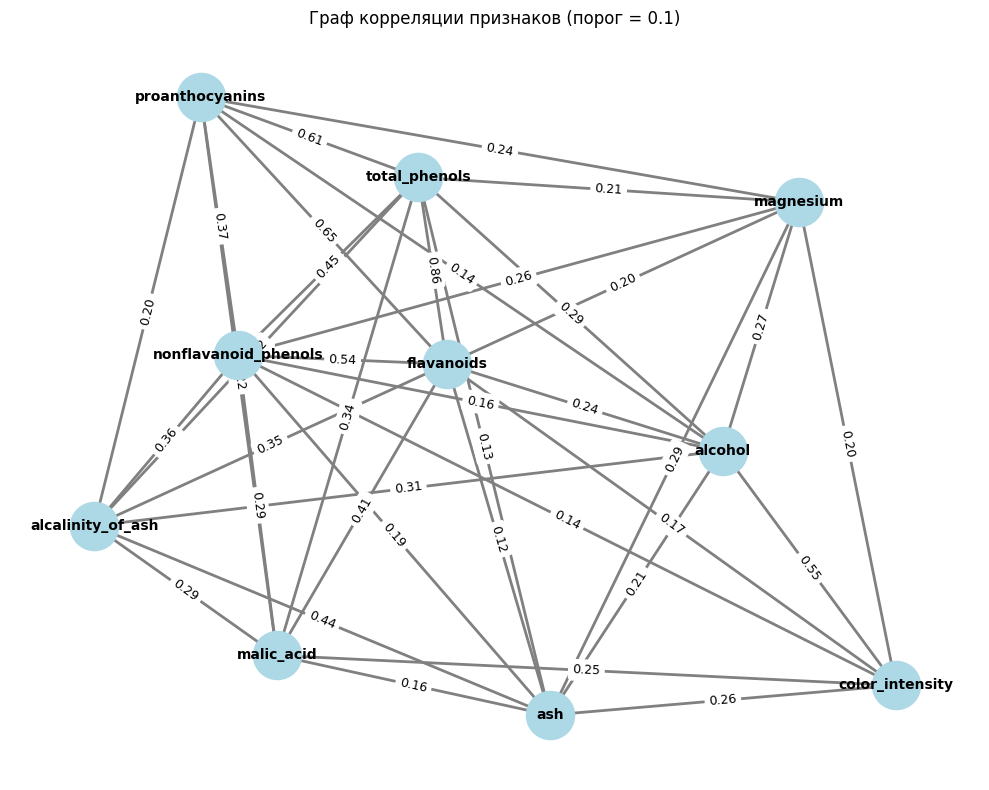

In [28]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# ---------- 1. Функция вычисления метрик (встроенная) ----------
def compute_metrics(edges, vertices):
    """
    Вычисляет MDBV, ARL, DEL для неориентированного взвешенного графа.
    edges: список (source, target, weight)
    vertices: множество вершин
    Возвращает словарь с метриками.
    """
    vertex_list = list(vertices)
    n = len(vertex_list)
    idx = {v: i for i, v in enumerate(vertex_list)}
    m = len(edges)

    if m == 0:
        raise ValueError("Граф не содержит рёбер.")

    weights = [w for _, _, w in edges]
    ARL = sum(weights) / m
    DEL = sum((w - ARL) ** 2 for w in weights) / m

    # MDBV – Floyd–Warshall
    INF = float('inf')
    dist = [[INF] * n for _ in range(n)]
    for i in range(n):
        dist[i][i] = 0

    for src, tgt, w in edges:
        u = idx[src]
        v = idx[tgt]
        if w < dist[u][v]:
            dist[u][v] = w
            dist[v][u] = w

    for k in range(n):
        dk = dist[k]
        for i in range(n):
            dik = dist[i][k]
            if dik == INF:
                continue
            di = dist[i]
            for j in range(n):
                nd = dik + dk[j]
                if nd < di[j]:
                    di[j] = nd

    min_dist = INF
    for i in range(n):
        for j in range(i + 1, n):
            if dist[i][j] < min_dist:
                min_dist = dist[i][j]

    MDBV = min_dist if min_dist != INF else None
    connected = all(dist[i][j] != INF for i in range(n) for j in range(n))

    return {
        'MDBV': MDBV,
        'ARL': ARL,
        'DEL': DEL,
        'connected': connected,
        'vertices_count': n,
        'edges_count': m
    }

# ---------- 2. Загрузка данных (замените на свой CSV) ----------
# Вариант 1: встроенный датасет вина
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Если у вас свой CSV, раскомментируйте и укажите путь:
# df = pd.read_csv('ваш_файл.csv')

# Ограничимся первыми 10 признаками (как вы просили)
df = df.iloc[:, :10]
print("Размер таблицы:", df.shape)

# ---------- 3. Построение графа корреляции ----------
corr = df.corr().abs()          # абсолютные значения корреляции
threshold = 0.1                 # порог значимости

G = nx.Graph()
G.add_nodes_from(corr.columns)

for i, col1 in enumerate(corr.columns):
    for j, col2 in enumerate(corr.columns):
        if i < j and corr.iloc[i, j] > threshold:
            G.add_edge(col1, col2, weight=corr.iloc[i, j])

print(f"Построен граф с {G.number_of_nodes()} вершинами и {G.number_of_edges()} рёбрами.")

# ---------- 4. Вычисление метрик ----------
edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]
vertices = set(G.nodes())

try:
    metrics = compute_metrics(edges, vertices)
    print("\n📊 МЕТРИКИ ГРАФА КОРРЕЛЯЦИИ ПРИЗНАКОВ:")
    print(f"  MDBV (минимальное расстояние между вершинами): {metrics['MDBV']}")
    print(f"  ARL  (средняя длина ребра):                    {metrics['ARL']:.6f}")
    print(f"  DEL  (дисперсия длин рёбер):                  {metrics['DEL']:.6f}")
    print(f"  Связность: {'Да' if metrics['connected'] else 'Нет'}")
    print(f"  Число вершин: {metrics['vertices_count']}, рёбер: {metrics['edges_count']}")
except ValueError as e:
    print("Ошибка:", e)

# ---------- 5. Визуализация графа (опционально) ----------
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)  # расположение узлов
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Подписи весов рёбер
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Граф корреляции признаков (порог = {})".format(threshold))
plt.axis('off')
plt.tight_layout()
plt.show()

In [31]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import networkx as nx
import plotly.graph_objects as go
from sklearn.datasets import load_wine
import subprocess
import sys

# ---------- Проверка и установка nbformat (если нужно) ----------
try:
    import nbformat
    from packaging import version
    if version.parse(nbformat.__version__) < version.parse("4.2.0"):
        raise ImportError("nbformat version < 4.2.0")
except (ImportError, AttributeError):
    print("Обновляем nbformat...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat"])
    print("nbformat обновлён. Перезапустите ядро или выполните код заново.")

# ---------- 1. Функция вычисления метрик ----------
def compute_metrics(edges, vertices):
    vertex_list = list(vertices)
    n = len(vertex_list)
    idx = {v: i for i, v in enumerate(vertex_list)}
    m = len(edges)
    if m == 0:
        raise ValueError("Граф не содержит рёбер.")
    weights = [w for _, _, w in edges]
    ARL = sum(weights) / m
    DEL = sum((w - ARL) ** 2 for w in weights) / m

    INF = float('inf')
    dist = [[INF] * n for _ in range(n)]
    for i in range(n):
        dist[i][i] = 0
    for src, tgt, w in edges:
        u = idx[src]; v = idx[tgt]
        if w < dist[u][v]:
            dist[u][v] = w
            dist[v][u] = w
    for k in range(n):
        dk = dist[k]
        for i in range(n):
            dik = dist[i][k]
            if dik == INF:
                continue
            di = dist[i]
            for j in range(n):
                nd = dik + dk[j]
                if nd < di[j]:
                    di[j] = nd

    min_dist = INF
    for i in range(n):
        for j in range(i + 1, n):
            if dist[i][j] < min_dist:
                min_dist = dist[i][j]
    MDBV = min_dist if min_dist != INF else None
    connected = all(dist[i][j] != INF for i in range(n) for j in range(n))
    return {
        'MDBV': MDBV,
        'ARL': ARL,
        'DEL': DEL,
        'connected': connected,
        'vertices_count': n,
        'edges_count': m
    }

# ---------- 2. Загрузка данных ----------
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df = df.iloc[:, :10]   # первые 10 признаков
print("Размер таблицы:", df.shape)

# ---------- 3. Построение графа корреляции ----------
corr = df.corr().abs()
threshold = 0.1
G = nx.Graph()
G.add_nodes_from(corr.columns)
for i, col1 in enumerate(corr.columns):
    for j, col2 in enumerate(corr.columns):
        if i < j and corr.iloc[i, j] > threshold:
            G.add_edge(col1, col2, weight=corr.iloc[i, j])

print(f"Построен граф с {G.number_of_nodes()} вершинами и {G.number_of_edges()} рёбрами.")

# ---------- 4. Вычисление метрик ----------
edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]
vertices = set(G.nodes())
metrics = compute_metrics(edges, vertices)
print("\n📊 МЕТРИКИ ГРАФА КОРРЕЛЯЦИИ ПРИЗНАКОВ:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

# ---------- 5. 3D визуализация с Plotly ----------
pos = nx.spring_layout(G, dim=3, seed=42, k=0.3)
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]
node_z = [pos[node][2] for node in G.nodes()]

edge_x, edge_y, edge_z = [], [], []
for u, v in G.edges():
    x0, y0, z0 = pos[u]
    x1, y1, z1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    line=dict(width=2, color='gray'),
    hoverinfo='none',
    mode='lines'
)

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers+text',
    text=list(G.nodes()),
    textposition="top center",
    marker=dict(size=12, color='lightblue', line=dict(width=1, color='darkblue')),
    hoverinfo='text',
    hovertext=[f"{node}<br>Связей: {G.degree(node)}" for node in G.nodes()]
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"Граф корреляции признаков (порог={threshold})<br>MDBV={metrics['MDBV']:.4f}, ARL={metrics['ARL']:.4f}, DEL={metrics['DEL']:.4f}",
    scene=dict(
        xaxis=dict(showticklabels=False, title=''),
        yaxis=dict(showticklabels=False, title=''),
        zaxis=dict(showticklabels=False, title='')
    ),
    showlegend=False,
    height=700,
    width=900
)

# ---------- 6. Отображение графа ----------
# Попробуем разные способы, чтобы избежать ошибки
try:
    import nbformat
    from packaging import version
    if version.parse(nbformat.__version__) >= version.parse("4.2.0"):
        fig.show(renderer='notebook')
    else:
        raise ImportError
except:
    print("Не удалось отобразить в ноутбуке. Открываем в браузере или сохраняем HTML.")
    try:
        fig.show(renderer='browser')
    except:
        fig.write_html("graph_3d.html")
        print("Граф сохранён в graph_3d.html. Откройте его в браузере.")
        import webbrowser
        webbrowser.open("graph_3d.html")

Обновляем nbformat...
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nbformat]
nbformat обновлён. Перезапустите ядро или выполните код заново.
Размер таблицы: (178, 10)
Построен граф с 10 вершинами и 38 рёбрами.

📊 МЕТРИКИ ГРАФА КОРРЕЛЯЦИИ ПРИЗНАКОВ:
  MDBV: 0.11507727901397194
  ARL: 0.307037586362042
  DEL: 0.02571017781574122
  connected: True
  vertices_count: 10
  edges_count: 38


Не удалось отобразить в ноутбуке. Открываем в браузере или сохраняем HTML.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

'''
# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
'''
# ---- Построение графа по порогу расстояния ----
#threshold = 0.5
#dist_matrix = squareform(pdist(points))
#G = nx.Graph()

# Добавляем вершины
for i in range(n_points):
    G.add_node(i, pos=points[i])

# Добавляем рёбра, если расстояние меньше порога
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

# ---- Находим все простые циклы (через фундаментальные циклы остовного дерева) ----
# Строим остовное дерево (если граф связен, иначе обрабатываем компоненты)
if nx.is_connected(G):
    T = nx.minimum_spanning_tree(G)
    # Список рёбер, не входящих в остов
    non_tree_edges = list(set(G.edges()) - set(T.edges()))
    cycle_edges = set()
    for u, v in non_tree_edges:
        # Путь в дереве между u и v + ребро (u,v) дают цикл
        path = nx.shortest_path(T, u, v)
        for i in range(len(path)-1):
            cycle_edges.add((path[i], path[i+1]))
            cycle_edges.add((path[i+1], path[i]))  # для неориентированного
        cycle_edges.add((u, v))
        cycle_edges.add((v, u))
    # Преобразуем в кортежи с сортировкой
    cycle_edges = set(tuple(sorted(e)) for e in cycle_edges)
else:
    # Если граф несвязен, обработаем каждую компоненту отдельно
    cycle_edges = set()
    for comp in nx.connected_components(G):
        subgraph = G.subgraph(comp)
        if nx.is_connected(subgraph):
            T = nx.minimum_spanning_tree(subgraph)
            non_tree = set(subgraph.edges()) - set(T.edges())
            for u, v in non_tree:
                path = nx.shortest_path(T, u, v)
                for i in range(len(path)-1):
                    cycle_edges.add(tuple(sorted((path[i], path[i+1]))))
                cycle_edges.add(tuple(sorted((u, v))))

# ---- Визуализация ----
pos = {i: points[i] for i in range(n_points)}
plt.figure(figsize=(8, 8))

# Рисуем все узлы
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='blue')

# Рёбра, не входящие в циклы, серым
non_cycle_edges = [e for e in G.edges() if e not in cycle_edges]
nx.draw_networkx_edges(G, pos, edgelist=non_cycle_edges, edge_color='gray', alpha=0.3)

# Рёбра, образующие циклы, красным
nx.draw_networkx_edges(G, pos, edgelist=list(cycle_edges), edge_color='red', width=2.0)

plt.title("Граф из облака точек\nКрасные рёбра принадлежат хотя бы одному циклу")
plt.axis('equal')
plt.show()

NameError: name 'n_points' is not defined

Файл points.csv не найден. Использую пример.
Построен граф: 80 вершин, 477 рёбер.
Найдено 477 рёбер, принадлежащих циклам.

📊 МЕТРИКИ МОРФОЛОГИИ ГРАФА:
  MDBV (минимальное расстояние между вершинами): 0.008988
  ARL  (средняя длина ребра):                    0.284082
  DEL  (дисперсия длин рёбер):                  0.016672
  Связность: Да
  Вершин: 80, рёбер: 477


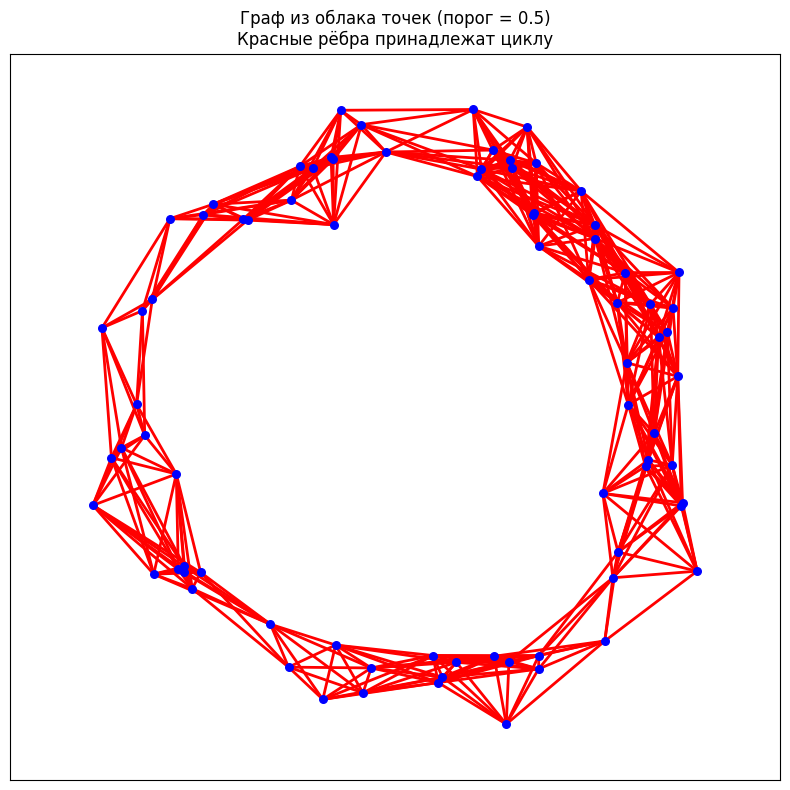

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import sys
import os

# ------------------------------------------------------------------
# 1. Генерация или загрузка данных
# ------------------------------------------------------------------

def generate_circle_points(n=80, noise=0.1, seed=42):
    """Генерирует точки на окружности с шумом."""
    np.random.seed(seed)
    theta = np.random.uniform(0, 2*np.pi, n)
    r = 1.0 + noise * np.random.randn(n)
    points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
    return points

def load_points_from_csv(filepath, x_col=0, y_col=1, delimiter=','):
    """Загружает точки из CSV (первая колонка – x, вторая – y)."""
    data = np.loadtxt(filepath, delimiter=delimiter, skiprows=1)  # если есть заголовок, установите skiprows=1
    if data.ndim == 1:
        data = data.reshape(-1, 2)
    if data.shape[1] < 2:
        raise ValueError("Файл должен содержать как минимум две колонки (x, y).")
    return data[:, :2]

# ------------------------------------------------------------------
# 2. Построение графа по порогу расстояния
# ------------------------------------------------------------------

def build_graph(points, threshold):
    """Строит неориентированный взвешенный граф по порогу расстояния."""
    n = points.shape[0]
    dist_matrix = squareform(pdist(points))
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i, j in combinations(range(n), 2):
        if dist_matrix[i, j] < threshold:
            G.add_edge(i, j, weight=dist_matrix[i, j])
    return G, dist_matrix

# ------------------------------------------------------------------
# 3. Поиск рёбер, принадлежащих циклам
# ------------------------------------------------------------------

def find_cycle_edges(G):
    """
    Возвращает множество рёбер (как кортежи (u,v) с u<v), которые входят
    хотя бы в один простой цикл (через фундаментальные циклы остовного дерева).
    """
    cycle_edges = set()
    if nx.is_connected(G):
        T = nx.minimum_spanning_tree(G)
        non_tree_edges = list(set(G.edges()) - set(T.edges()))
        for u, v in non_tree_edges:
            path = nx.shortest_path(T, u, v)
            for i in range(len(path)-1):
                cycle_edges.add(tuple(sorted((path[i], path[i+1]))))
            cycle_edges.add(tuple(sorted((u, v))))
    else:
        # Если граф несвязен, обрабатываем каждую компоненту отдельно
        for comp in nx.connected_components(G):
            subgraph = G.subgraph(comp)
            if nx.is_connected(subgraph):
                T = nx.minimum_spanning_tree(subgraph)
                non_tree = set(subgraph.edges()) - set(T.edges())
                for u, v in non_tree:
                    path = nx.shortest_path(T, u, v)
                    for i in range(len(path)-1):
                        cycle_edges.add(tuple(sorted((path[i], path[i+1]))))
                    cycle_edges.add(tuple(sorted((u, v))))
    return cycle_edges

# ------------------------------------------------------------------
# 4. Вычисление метрик MDBV, ARL, DEL
# ------------------------------------------------------------------

def compute_metrics(G):
    """
    Вычисляет:
      - MDBV (минимальное расстояние между вершинами по графу)
      - ARL  (средняя длина ребра)
      - DEL  (дисперсия длин рёбер)
    Возвращает словарь с метриками и дополнительной информацией.
    """
    if G.number_of_edges() == 0:
        raise ValueError("Граф не содержит рёбер.")

    # ARL и DEL
    weights = [d['weight'] for u, v, d in G.edges(data=True)]
    ARL = np.mean(weights)
    DEL = np.var(weights)  # дисперсия (среднее квадратов отклонений)

    # MDBV – кратчайшие пути между всеми парами вершин (алгоритм Флойда-Уоршелла)
    # Преобразуем в матрицу смежности с весами
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    idx = {v: i for i, v in enumerate(nodes)}
    INF = float('inf')
    dist = np.full((n, n), INF)
    np.fill_diagonal(dist, 0)

    for u, v, d in G.edges(data=True):
        i, j = idx[u], idx[v]
        w = d['weight']
        dist[i, j] = min(dist[i, j], w)
        dist[j, i] = min(dist[j, i], w)

    # Флойд-Уоршелл
    for k in range(n):
        dk = dist[k]
        for i in range(n):
            dik = dist[i, k]
            if dik == INF:
                continue
            di = dist[i]
            # векторная операция
            nd = dik + dk
            mask = nd < di
            di[mask] = nd[mask]

    # Минимальное расстояние среди всех пар (i<j)
    upper = dist[np.triu_indices(n, k=1)]
    min_dist = np.min(upper) if upper.size > 0 else INF
    MDBV = min_dist if min_dist != INF else None

    connected = np.all(dist != INF)

    return {
        'MDBV': MDBV,
        'ARL': ARL,
        'DEL': DEL,
        'connected': connected,
        'vertices_count': n,
        'edges_count': G.number_of_edges()
    }

# ------------------------------------------------------------------
# 5. Визуализация
# ------------------------------------------------------------------

def plot_graph(points, G, cycle_edges, threshold, title=None):
    """Рисует граф: вершины синие, рёбра не циклические – серые, циклические – красные."""
    pos = {i: points[i] for i in range(len(points))}
    plt.figure(figsize=(8, 8))

    nx.draw_networkx_nodes(G, pos, node_size=30, node_color='blue')

    non_cycle_edges = [e for e in G.edges() if e not in cycle_edges and (e[1], e[0]) not in cycle_edges]
    nx.draw_networkx_edges(G, pos, edgelist=non_cycle_edges, edge_color='gray', alpha=0.3)

    if cycle_edges:
        # Приводим к кортежам (u,v) с u<v
        cycle_edges_list = [tuple(sorted(e)) for e in cycle_edges]
        nx.draw_networkx_edges(G, pos, edgelist=cycle_edges_list, edge_color='red', width=2.0)

    if title is None:
        title = f"Граф из облака точек (порог = {threshold})\nКрасные рёбра принадлежат циклу"
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 6. Главная функция
# ------------------------------------------------------------------

def main():
    # ---------- Настройки (можно менять) ----------
    threshold = 0.5          # порог расстояния для построения рёбер
    use_sample = False       # True – генерировать точки на окружности; False – загрузить CSV
    csv_path = "points.csv"  # путь к CSV, если use_sample = False
    # ----------------------------------------------

    # Генерация или загрузка
    if use_sample:
        points = generate_circle_points(n=80, noise=0.1, seed=42)
        print("Сгенерировано 80 точек на окружности с шумом.")
    else:
        if not os.path.exists(csv_path):
            print(f"Файл {csv_path} не найден. Использую пример.")
            points = generate_circle_points()
        else:
            points = load_points_from_csv(csv_path)
            print(f"Загружено {len(points)} точек из {csv_path}.")

    # Построение графа
    G, dist_matrix = build_graph(points, threshold)
    print(f"Построен граф: {G.number_of_nodes()} вершин, {G.number_of_edges()} рёбер.")

    if G.number_of_edges() == 0:
        print("Предупреждение: граф пуст. Уменьшите порог или увеличьте количество точек.")
        return

    # Поиск циклических рёбер
    cycle_edges = find_cycle_edges(G)
    print(f"Найдено {len(cycle_edges)} рёбер, принадлежащих циклам.")

    # Вычисление метрик
    try:
        metrics = compute_metrics(G)
        print("\n📊 МЕТРИКИ МОРФОЛОГИИ ГРАФА:")
        print(f"  MDBV (минимальное расстояние между вершинами): {metrics['MDBV']:.6f}")
        print(f"  ARL  (средняя длина ребра):                    {metrics['ARL']:.6f}")
        print(f"  DEL  (дисперсия длин рёбер):                  {metrics['DEL']:.6f}")
        print(f"  Связность: {'Да' if metrics['connected'] else 'Нет'}")
        print(f"  Вершин: {metrics['vertices_count']}, рёбер: {metrics['edges_count']}")
    except ValueError as e:
        print("Ошибка при вычислении метрик:", e)

    # Визуализация
    plot_graph(points, G, cycle_edges, threshold)

if __name__ == "__main__":
    main()

## 1. Базовые метрики

### 1. Минимальное расстояние между вершинами (Minimum distance between vertices, MDBV)

- MDBV – Минимальное расстояние между вершинами
- Что измеряет: Кратчайшее расстояние (по графу или в пространстве) между двумя различными вершинами. Для невзвешенного связного графа всегда 1.
- Интерпритация: Характеризует минимальную «близость» объектов. Чем меньше, тем теснее связаны ближайшие вершины.

In [12]:
import networkx as nx
import numpy as np
from scipy.stats import skew, kurtosis

# ========== БЛОК ВЫЧИСЛЕНИЯ МЕТРИК ==========
# Предполагается, что у вас есть граф G (NetworkX Graph)

print("\n" + "="*70)
print("          МЕТРИКИ ГРАФА")
print("="*70)

# ---- 1. Базовые характеристики ----
n = G.number_of_nodes()
m = G.number_of_edges()
print(f"Число вершин (n):                 {n}")
print(f"Число рёбер (m):                  {m}")
print(f"Плотность графа:                  {nx.density(G):.4f}" if n > 1 else "Плотность графа: N/A")

# ---- 2. Степени вершин ----
degrees = [d for _, d in G.degree()]
if degrees:
    print(f"Средняя степень:                 {np.mean(degrees):.3f}")
    print(f"Дисперсия степени:               {np.var(degrees):.3f}")
    print(f"Минимальная степень:             {min(degrees)}")
    print(f"Максимальная степень:            {max(degrees)}")
    print(f"Асимметрия распределения степеней: {skew(degrees):.3f}")
    print(f"Эксцесс распределения степеней:   {kurtosis(degrees, fisher=True):.3f}")

# ---- 3. Компоненты связности ----
if nx.is_directed(G):
    comps = list(nx.weakly_connected_components(G))
    print(f"Слабо связных компонент:          {len(comps)}")
else:
    comps = list(nx.connected_components(G))
    print(f"Компонент связности:              {len(comps)}")
if comps:
    sizes = [len(c) for c in comps]
    print(f"  - самая большая:               {max(sizes)}")
    print(f"  - самая маленькая:             {min(sizes)}")
    print(f"  - средний размер:              {np.mean(sizes):.2f}")

# ---- 4. Кратчайшие пути (если граф связен) ----
if len(comps) == 1:
    # Проверяем, есть ли веса
    try:
        # Попытка вычислить взвешенные расстояния
        if all('weight' in G[u][v] for u, v in G.edges()):
            lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
            all_dist = [d for u in lengths for v, d in lengths[u].items() if u != v]
            if all_dist:
                diam = max(all_dist)
                avg_dist = np.mean(all_dist)
                # радиус
                ecc = [max(lengths[u].values()) for u in G.nodes()]
                radius = min(ecc)
                print(f"Диаметр (взвешенный):            {diam:.3f}")
                print(f"Радиус (взвешенный):             {radius:.3f}")
                print(f"Среднее расстояние (взв.):       {avg_dist:.3f}")
            else:
                raise ValueError
        else:
            raise ValueError
    except:
        # Невзвешенный
        diam = nx.diameter(G)
        radius = nx.radius(G)
        avg_dist = nx.average_shortest_path_length(G)
        print(f"Диаметр (невзвешенный):          {diam}")
        print(f"Радиус (невзвешенный):           {radius}")
        print(f"Среднее расстояние (невзв.):     {avg_dist:.3f}")
else:
    print("Граф несвязен – диаметр/радиус/среднее не определены глобально.")
    # Выводим для каждой крупной компоненты (опционально)
    for i, comp in enumerate(comps):
        if len(comp) > 1:
            sub = G.subgraph(comp)
            print(f"  Комп. {i+1} (размер {len(comp)}): диаметр = {nx.diameter(sub)}")
        else:
            print(f"  Комп. {i+1}: изолированная вершина")

# ---- 5. Коэффициенты кластеризации ----
if n > 0:
    print(f"Средний коэффициент кластеризации: {nx.average_clustering(G):.4f}")
    print(f"Глобальный (transitivity):        {nx.transitivity(G):.4f}")

# ---- 6. Цикломатическое число (для неориентированных) ----
if not nx.is_directed(G):
    cycle_rank = m - n + len(comps)
    print(f"Цикломатическое число (независимые циклы): {cycle_rank}")

# ---- 7. Центральности (средние значения) ----
if n > 1:
    deg_cent = list(nx.degree_centrality(G).values())
    print(f"Средняя степень центральности:    {np.mean(deg_cent):.4f}")
    try:
        close_cent = list(nx.closeness_centrality(G).values())
        print(f"Средняя близость:                {np.mean(close_cent):.4f}")
    except:
        pass  # если граф несвязен, не вычисляется
    between_cent = list(nx.betweenness_centrality(G).values())
    print(f"Средняя посредничество:           {np.mean(between_cent):.4f}")
    try:
        eigen_cent = list(nx.eigenvector_centrality(G, max_iter=1000).values())
        print(f"Средняя собственная центральн.:  {np.mean(eigen_cent):.4f}")
    except:
        pass

# ---- 8. Минимальное расстояние между вершинами (MDBV) ----
if n >= 2 and m > 0:
    if len(comps) == 1:
        # связный
        try:
            # взвешенный
            if all('weight' in G[u][v] for u, v in G.edges()):
                lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
                all_dist = [d for u in lengths for v, d in lengths[u].items() if u != v]
                min_dist = min(all_dist) if all_dist else None
            else:
                # невзвешенный – минимум всегда 1, если есть ребро
                min_dist = 1
            print(f"Минимальное расстояние между вершинами (MDBV): {min_dist:.3f}" if isinstance(min_dist, (int, float)) else "MDBV: 1")
        except:
            print("Минимальное расстояние между вершинами (MDBV): 1")
    else:
        # несвязный – ищем минимум внутри каждой компоненты
        min_dist = float('inf')
        for comp in comps:
            sub = G.subgraph(comp)
            if sub.number_of_edges() > 0:
                try:
                    if all('weight' in sub[u][v] for u, v in sub.edges()):
                        lengths = dict(nx.all_pairs_dijkstra_path_length(sub, weight='weight'))
                        dists = [d for u in lengths for v, d in lengths[u].items() if u != v]
                        if dists:
                            min_dist = min(min_dist, min(dists))
                    else:
                        min_dist = 1
                        break
                except:
                    min_dist = 1
                    break
        if min_dist == float('inf'):
            print("Минимальное расстояние между вершинами (MDBV): ∞ (нет рёбер)")
        else:
            print(f"Минимальное расстояние между вершинами (MDBV): {min_dist:.3f}" if isinstance(min_dist, float) else f"MDBV: {min_dist}")

# ---- 9. Дополнительно: ассортативность (корреляция степеней) ----
if m > 0:
    print(f"Ассортативность (корреляция степеней): {nx.degree_assortativity_coefficient(G):.4f}")

print("="*70)


          МЕТРИКИ ГРАФА
Число вершин (n):                 80
Число рёбер (m):                  477
Плотность графа:                  0.1509
Средняя степень:                 11.925
Дисперсия степени:               8.944
Минимальная степень:             7
Максимальная степень:            20
Асимметрия распределения степеней: 0.459
Эксцесс распределения степеней:   -0.285
Компонент связности:              1
  - самая большая:               80
  - самая маленькая:             80
  - средний размер:              80.00
Диаметр (невзвешенный):          8
Радиус (невзвешенный):           7
Среднее расстояние (невзв.):     4.114
Средний коэффициент кластеризации: 0.7314
Глобальный (transitivity):        0.7262
Цикломатическое число (независимые циклы): 398
Средняя степень центральности:    0.1509
Средняя близость:                0.2451
Средняя посредничество:           0.0399
Средняя собственная центральн.:  0.0731
Минимальное расстояние между вершинами (MDBV): 1.000
Ассортативность (корреляци

### 2. Средняя длина ребра (Average rib length, ARL)

- ARL – Средняя длина ребра
- Что измеряет: Среднее арифметическое длин (весов или евклидовых расстояний) всех рёбер.
- Интерпретация: Отражает типичный масштаб связей.

In [13]:
import numpy as np

# ---- Вычисление средней длины ребра ----
def average_edge_length(G):
    """
    Возвращает среднюю длину ребра в графе G.
    Приоритет:
    1) если есть веса 'weight' – берём их,
    2) иначе если у вершин есть координаты 'pos' – считаем евклидово расстояние,
    3) иначе считаем длину каждого ребра = 1.
    """
    edges = list(G.edges())
    if not edges:
        return 0.0  # нет рёбер

    lengths = []
    # Проверяем, есть ли веса у всех рёбер
    has_weights = all('weight' in G[u][v] for u, v in edges)
    
    if has_weights:
        # Берём веса
        lengths = [G[u][v]['weight'] for u, v in edges]
    else:
        # Проверяем, есть ли координаты у вершин (например, атрибут 'pos')
        # Можно также проверить наличие 'x' и 'y' или 'coords'
        pos_attr = None
        # Ищем первый узел с атрибутом 'pos'
        for node in G.nodes():
            if 'pos' in G.nodes[node]:
                pos_attr = 'pos'
                break
            elif 'coords' in G.nodes[node]:
                pos_attr = 'coords'
                break
            elif 'x' in G.nodes[node] and 'y' in G.nodes[node]:
                pos_attr = 'xy'
                break
        
        if pos_attr:
            # Функция получения координат
            def get_coords(node):
                if pos_attr == 'pos':
                    return G.nodes[node]['pos']
                elif pos_attr == 'coords':
                    return G.nodes[node]['coords']
                elif pos_attr == 'xy':
                    return (G.nodes[node]['x'], G.nodes[node]['y'])
            # Вычисляем евклидовы расстояния
            for u, v in edges:
                p1 = np.array(get_coords(u))
                p2 = np.array(get_coords(v))
                lengths.append(np.linalg.norm(p1 - p2))
        else:
            # Нет ни весов, ни координат – считаем длину = 1
            lengths = [1.0] * len(edges)
    
    return np.mean(lengths) if lengths else 0.0

# ---- Вызов для вашего графа G ----
ael = average_edge_length(G)
print(f"Средняя длина ребра (AEL): {ael:.4f}")

Средняя длина ребра (AEL): 0.2841


### 3. Дисперсия длин рёбер (Dispersion of edge lengths, DEL)

- DEL – Дисперсия длин рёбер
- Разброс длин рёбер относительно среднего.
- Показывает, насколько однородны длины связей. Большая дисперсия → гетерогенность масштабов.

In [15]:
import numpy as np

def get_edge_lengths(G):
    """
    Возвращает список длин всех рёбер графа G.
    Приоритет определения длины:
    1) атрибут 'weight' у ребра,
    2) евклидово расстояние по координатам вершин (атрибуты 'pos', 'coords' или 'x'+'y'),
    3) если ничего нет, длина = 1 для каждого ребра.
    """
    edges = list(G.edges())
    if not edges:
        return []
    
    lengths = []
    has_weights = all('weight' in G[u][v] for u, v in edges)
    
    if has_weights:
        lengths = [G[u][v]['weight'] for u, v in edges]
    else:
        # Проверяем наличие координат у вершин
        pos_attr = None
        for node in G.nodes():
            if 'pos' in G.nodes[node]:
                pos_attr = 'pos'
                break
            elif 'coords' in G.nodes[node]:
                pos_attr = 'coords'
                break
            elif 'x' in G.nodes[node] and 'y' in G.nodes[node]:
                pos_attr = 'xy'
                break
        
        if pos_attr:
            def get_coords(node):
                if pos_attr == 'pos':
                    return G.nodes[node]['pos']
                elif pos_attr == 'coords':
                    return G.nodes[node]['coords']
                else:  # 'xy'
                    return (G.nodes[node]['x'], G.nodes[node]['y'])
            
            for u, v in edges:
                p1 = np.array(get_coords(u))
                p2 = np.array(get_coords(v))
                lengths.append(np.linalg.norm(p1 - p2))
        else:
            # Нет ни весов, ни координат – длина = 1
            lengths = [1.0] * len(edges)
    
    return lengths


def dispersion_edge_lengths(G):
    """
    Вычисляет дисперсию длин рёбер (DEL) для графа G.
    Используется выборочная дисперсия (ddof=0) – дисперсия генеральной совокупности.
    Если рёбер нет, возвращает 0.0.
    """
    lengths = get_edge_lengths(G)
    if not lengths:
        return 0.0
    return float(np.var(lengths))  # ddof=0 по умолчанию

# ---- Пример использования ----
# Предполагается, что у вас есть граф G
del_value = dispersion_edge_lengths(G)
print(f"Дисперсия длин рёбер (DEL): {del_value:.4f}")

Дисперсия длин рёбер (DEL): 0.0167


### 4. Максимальное отклонение углов (Maximum angle deviation, MAD) 
- MAD – Максимальное отклонение углов
- Что измеряет: Наибольшее абсолютное отклонение угла между любыми двумя рёбрами, инцидентными одной вершине, от 180°.
- Интерпретация: Мера максимальной «изломанности» графа. Чем больше, тем сильнее локальные искажения прямолинейности.

In [16]:
def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    coords = {}
    # Проверяем наличие атрибутов у первого узла
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def max_angle_deviation(G, expected_angle_deg=180.0):
    """
    Вычисляет максимальное отклонение углов (MAD) в графе G.
    
    Для каждой вершины рассматриваются все пары инцидентных рёбер,
    вычисляется угол между ними (в градусах) и находится отклонение
    от ожидаемого угла (по умолчанию 180°). 
    Возвращается максимальное абсолютное отклонение по всем парам всех вершин.
    
    Если граф не имеет координат, возвращает None.
    Если у вершины меньше 2 соседей, она пропускается.
    
    Параметры:
    - G: NetworkX граф
    - expected_angle_deg: ожидаемый угол в градусах (по умолчанию 180)
    
    Возвращает:
    - float или None
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, MAD не определён.")
        return None
    
    max_dev = 0.0
    # Для каждой вершины
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if len(neighbors) < 2:
            continue
        # Векторы от вершины к соседям
        vectors = []
        p0 = np.array(coords[node])
        for nb in neighbors:
            p1 = np.array(coords[nb])
            vec = p1 - p0
            # Игнорируем нулевой вектор (если вершина совпадает с соседом)
            if np.linalg.norm(vec) < 1e-12:
                continue
            vectors.append(vec)
        # Если менее двух ненулевых векторов – пропускаем
        if len(vectors) < 2:
            continue
        # Перебираем все пары векторов
        for i in range(len(vectors)):
            for j in range(i+1, len(vectors)):
                v1 = vectors[i]
                v2 = vectors[j]
                # Косинус угла
                cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                # Ограничим из-за возможных ошибок округления
                cos_angle = np.clip(cos_angle, -1.0, 1.0)
                angle_deg = np.degrees(np.arccos(cos_angle))
                # Отклонение от ожидаемого угла
                dev = abs(angle_deg - expected_angle_deg)
                if dev > max_dev:
                    max_dev = dev
    return max_dev

# ---- Пример использования ----
mad = max_angle_deviation(G)
if mad is not None:
    print(f"Максимальное отклонение углов (MAD): {mad:.2f}°")
else:
    print("MAD не может быть вычислен (нет координат).")

Максимальное отклонение углов (MAD): 179.96°


### 5. Пересечения рёбер (Rib crossings, RC)
- RC – Пересечения рёбер
- Что измеряет: Количество пар рёбер, которые геометрически пересекаются (без учёта общих вершин).
- Интерпретация: Характеризует «запутанность» графа при визуализации. Большое RC указывает на сложную пространственную структуру.

In [18]:
def edge_crossings(G):
    """
    Вычисляет количество пересечений рёбер в графе G на основе координат вершин.
    Пересечения считаются только для пар рёбер, не имеющих общих вершин.
    Возвращает int или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, RC не определён.")
        return None
    
    edges = list(G.edges())
    n_edges = len(edges)
    crossings = 0
    
    # Вспомогательные функции для ориентации и пересечения
    def orientation(p, q, r):
        val = (q[1]-p[1])*(r[0]-q[0]) - (q[0]-p[0])*(r[1]-q[1])
        if abs(val) < 1e-12:
            return 0
        return 1 if val > 0 else -1
    
    def on_segment(p, q, r):
        return (min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and
                min(p[1], r[1]) <= q[1] <= max(p[1], r[1]))
    
    def segments_intersect(p1, p2, q1, q2):
        # Проверка пересечения отрезков p1-p2 и q1-q2
        o1 = orientation(p1, p2, q1)
        o2 = orientation(p1, p2, q2)
        o3 = orientation(q1, q2, p1)
        o4 = orientation(q1, q2, p2)
        
        # Общий случай
        if o1 != o2 and o3 != o4:
            return True
        
        # Специальные случаи (коллинеарность) – мы не считаем пересечение,
        # если только они не перекрываются, но для упрощения считаем, что коллинеарные не пересекаются
        # (чтобы избежать подсчёта касаний и пересечений в вершинах)
        # Можно добавить проверку на перекрытие, но тогда могут быть ложные срабатывания.
        # Поскольку мы хотим только внутренние пересечения, коллинеарные случаи игнорируем.
        return False
    
    for i in range(n_edges):
        u1, v1 = edges[i]
        p1 = coords[u1]
        p2 = coords[v1]
        for j in range(i+1, n_edges):
            u2, v2 = edges[j]
            # Проверяем, имеют ли рёбра общие вершины
            if u1 == u2 or u1 == v2 or v1 == u2 or v1 == v2:
                continue
            q1 = coords[u2]
            q2 = coords[v2]
            if segments_intersect(p1, p2, q1, q2):
                crossings += 1
    return crossings

# Пример использования
rc = edge_crossings(G)
if rc is not None:
    print(f"Пересечения рёбер (RC): {rc}")

Пересечения рёбер (RC): 2119


### 6. Площадь покрытия (Coverage area, CA)
- CA – Площадь покрытия
- Что измеряет: Площадь выпуклой оболочки множества вершин.
- Интерпретация: Оценивает пространственный размах данных. Большая площадь → широкий охват территории/признакового пространства.

In [19]:
import numpy as np

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def convex_hull_area(points):
    """
    Вычисляет площадь выпуклой оболочки множества точек (список кортежей (x,y)).
    Использует алгоритм монотонной цепочки Эндрю (Andrew's monotone chain).
    Возвращает float (площадь) или 0.0, если точек меньше 3.
    """
    if len(points) < 3:
        return 0.0
    # Удаляем дубликаты и сортируем по (x, y)
    pts = sorted(set(points))
    if len(pts) < 3:
        return 0.0

    # Вспомогательная функция для проверки поворота
    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    # Нижняя оболочка
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    # Верхняя оболочка
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    # Объединяем (без дублирования крайних точек)
    hull = lower[:-1] + upper[:-1]
    if len(hull) < 3:
        return 0.0

    # Площадь по формуле шнурка (Shoelace formula)
    area = 0.0
    n = len(hull)
    for i in range(n):
        x1, y1 = hull[i]
        x2, y2 = hull[(i + 1) % n]
        area += x1 * y2 - x2 * y1
    return abs(area) / 2.0


def coverage_area(G):
    """
    Вычисляет площадь покрытия (CA) — площадь выпуклой оболочки вершин графа.
    Требует наличия координат у вершин (атрибуты 'pos', 'coords' или 'x'+'y').
    Возвращает float или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, CA не определён.")
        return None
    points = list(coords.values())
    return convex_hull_area(points)


# ---- Пример использования ----
ca = coverage_area(G)
if ca is not None:
    print(f"Площадь покрытия (CA): {ca:.4f}")

TypeError: unhashable type: 'numpy.ndarray'

### 7. Коэффициент сохранения соседних вершин (Conservation coefficient of neighboring vertices, CNF)
- CNF – Коэффициент сохранения соседних вершин
- Что измеряет: Средний коэффициент Жаккара между множествами соседей для всех рёбер.
- Интерпритация: Мера локальной кластеризации. Высокий CNF → вершины имеют много общих соседей (кликовая структура).

In [20]:
import networkx as nx

def conservation_neighbor_coefficient(G):
    """
    Вычисляет коэффициент сохранения соседних вершин (CNF).
    
    Определение: для каждого ребра (u,v) вычисляется коэффициент Жаккара
    между множествами соседей вершин u и v (без учёта друг друга):
        J(u,v) = |N(u) ∩ N(v)| / |N(u) ∪ N(v)|
    Затем усредняется по всем рёбрам.
    
    Возвращает float в диапазоне [0,1] или 0.0, если рёбер нет.
    """
    edges = list(G.edges())
    if not edges:
        return 0.0
    
    total_jaccard = 0.0
    for u, v in edges:
        # Множества соседей (без учёта самой вершины и смежной)
        neighbors_u = set(G.neighbors(u)) - {v}
        neighbors_v = set(G.neighbors(v)) - {u}
        
        # Если оба множества пусты, коэффициент Жаккара считаем 0
        if not neighbors_u and not neighbors_v:
            jaccard = 0.0
        else:
            intersection = len(neighbors_u & neighbors_v)
            union = len(neighbors_u | neighbors_v)
            jaccard = intersection / union if union > 0 else 0.0
        total_jaccard += jaccard
    
    return total_jaccard / len(edges)


# ---- Пример использования ----
cnf = conservation_neighbor_coefficient(G)
print(f"Коэффициент сохранения соседних вершин (CNF): {cnf:.4f}")

Коэффициент сохранения соседних вершин (CNF): 0.5950


### 8. Степень соблюдения слоев (Degree of adherence to layers, DAL)
- DAL – Степень соблюдения слоёв
- Что измеряет: (Требуется уточнение, но обычно измеряет, насколько вершины распределены по иерархическим уровням или слоям, например, по удалённости от центра.)
- Интерпритация: Показывает, насколько граф стратифицирован по уровням (например, в многослойных сетях).

In [21]:
import networkx as nx
import numpy as np

def degree_adherence_to_layers(G):
    """
    Вычисляет степень соблюдения слоёв (DAL) для неориентированного графа G.
    
    Определение: выбирается центральная вершина графа (с минимальным эксцентриситетом).
    Для каждой вершины определяется слой = расстояние (в рёбрах) до центра.
    DAL = доля рёбер, соединяющих вершины, расстояния которых отличаются ровно на 1.
    Рёбра, для которых одна из вершин недостижима из центра (другая компонента),
    не учитываются в знаменателе (или можно считать их нарушающими, но здесь пропускаем).
    
    Если граф пуст или не имеет рёбер, возвращает 0.0.
    """
    edges = list(G.edges())
    if not edges:
        return 0.0

    # Проверяем связность и выбираем самую большую компоненту
    if nx.is_connected(G):
        # Находим центр (вершина с минимальным эксцентриситетом)
        center = nx.center(G)[0]  # возвращает список, берём первый
    else:
        # Берём самую большую компоненту
        components = list(nx.connected_components(G))
        largest_comp = max(components, key=len)
        # Центр внутри этой компоненты
        subgraph = G.subgraph(largest_comp)
        center = nx.center(subgraph)[0]
        # Для вершин вне largest_comp мы не будем учитывать рёбра, где хотя бы одна вершина вне компоненты
        # или будем присваивать им слой -1

    # Вычисляем расстояния от центра до всех вершин
    # Для несвязного графа, вершины вне компоненты центра получат inf
    try:
        distances = nx.single_source_shortest_path_length(G, center)
    except:
        # Если граф не связный и center не достижим до всех, расстояния только для своей компоненты
        distances = dict(nx.single_source_shortest_path_length(G, center))
    
    # Присваиваем слой = расстояние для достижимых, для остальных -1
    layers = {node: distances.get(node, -1) for node in G.nodes()}

    # Подсчёт рёбер с разностью слоёв = 1
    adjacent_edges = 0
    total_valid_edges = 0
    for u, v in edges:
        layer_u = layers[u]
        layer_v = layers[v]
        # Если хотя бы один слой = -1, пропускаем это ребро (не учитываем)
        if layer_u == -1 or layer_v == -1:
            continue
        total_valid_edges += 1
        if abs(layer_u - layer_v) == 1:
            adjacent_edges += 1

    if total_valid_edges == 0:
        return 0.0
    return adjacent_edges / total_valid_edges

# ---- Пример использования ----
dal = degree_adherence_to_layers(G)
print(f"Степень соблюдения слоёв (DAL): {dal:.4f}")

Степень соблюдения слоёв (DAL): 0.5304


### 9. Расстояние центров масс компонентов (Distance of centers of mass of components, DCMC)
- DCMC – Расстояние центров масс компонентов
- Что измеряет: Попарные евклидовы расстояния между центрами масс каждой компоненты связности.
- Интерпритация: Характеризует разобщённость кластеров. Большие расстояния → компоненты далеки друг от друга.

In [22]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def component_centers_of_mass(G):
    """
    Вычисляет центры масс (средние координаты) для каждой компоненты связности графа G.
    Возвращает список центров масс (каждый как (x, y)).
    Если граф не имеет координат, возвращает None.
    """
    coords = get_coordinates(G)
    if coords is None:
        return None
    # Получаем компоненты связности (для неориентированного графа)
    components = list(nx.connected_components(G))
    centers = []
    for comp in components:
        if len(comp) == 0:
            continue
        # Средние координаты вершин в компоненте
        points = np.array([coords[node] for node in comp])
        center = np.mean(points, axis=0)
        centers.append(tuple(center))
    return centers


def distance_centers_mass_components(G):
    """
    Вычисляет расстояния между центрами масс компонент связности (DCMC).
    Возвращает словарь с ключами:
        - 'mean': среднее попарное расстояние между всеми центрами масс,
        - 'min': минимальное попарное расстояние,
        - 'max': максимальное попарное расстояние,
        - 'largest_pair': расстояние между центрами масс двух крупнейших компонент (по числу вершин).
    Если компонент меньше 2, все расстояния равны 0.0.
    Если координаты отсутствуют, возвращает None.
    """
    centers = component_centers_of_mass(G)
    if centers is None:
        print("Предупреждение: граф не имеет координат, DCMC не определён.")
        return None
    
    k = len(centers)
    if k < 2:
        return {'mean': 0.0, 'min': 0.0, 'max': 0.0, 'largest_pair': 0.0}
    
    # Вычисляем попарные расстояния между центрами масс
    distances = []
    for i in range(k):
        for j in range(i+1, k):
            dist = np.linalg.norm(np.array(centers[i]) - np.array(centers[j]))
            distances.append(dist)
    
    # Определяем две крупнейшие компоненты по размеру (числу вершин)
    comp_sizes = [(len(comp), i) for i, comp in enumerate(nx.connected_components(G))]
    comp_sizes.sort(reverse=True)
    if len(comp_sizes) >= 2:
        idx1 = comp_sizes[0][1]
        idx2 = comp_sizes[1][1]
        largest_pair_dist = np.linalg.norm(np.array(centers[idx1]) - np.array(centers[idx2]))
    else:
        largest_pair_dist = 0.0
    
    return {
        'mean': np.mean(distances),
        'min': np.min(distances),
        'max': np.max(distances),
        'largest_pair': largest_pair_dist
    }

# ---- Пример использования ----
dcmc = distance_centers_mass_components(G)
if dcmc is not None:
    print(f"Расстояние центров масс компонентов (DCMC):")
    print(f"  Среднее: {dcmc['mean']:.4f}")
    print(f"  Минимальное: {dcmc['min']:.4f}")
    print(f"  Максимальное: {dcmc['max']:.4f}")
    print(f"  Расстояние между двумя крупнейшими компонентами: {dcmc['largest_pair']:.4f}")

Расстояние центров масс компонентов (DCMC):
  Среднее: 0.0000
  Минимальное: 0.0000
  Максимальное: 0.0000
  Расстояние между двумя крупнейшими компонентами: 0.0000


### 10. Симметрия (Symmetry, Sym)
- Sym – Симметрия
- Что измеряет: Мера равномерности распределения вершин по углам вокруг центра масс (на основе теста Рэлея).
- Близость к 1 означает круговую симметрию, к 0 – сильную анизотропию (сосредоточенность в одном направлении).

In [23]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def symmetry(G):
    """
    Вычисляет меру угловой симметрии (Sym) графа.
    Идея: чем равномернее вершины распределены по углам вокруг центра масс,
    тем выше симметрия (значение ближе к 1).
    Используется 1 - результирующая длина вектора (R) из теста Рэлея.
    R = (1/N) * |sum_i exp(i*theta_i)|.
    При равномерном распределении R→0, симметрия→1.
    При концентрации в одном направлении R→1, симметрия→0.
    Возвращает float в [0,1] или None, если координаты отсутствуют.
    Если вершин меньше 2, возвращает 1.0 (тривиальная симметрия).
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, Sym не определён.")
        return None

    n = G.number_of_nodes()
    if n < 2:
        return 1.0  # одна вершина или ни одной – условно симметрично

    # Центр масс
    points = np.array(list(coords.values()))
    center = np.mean(points, axis=0)

    # Векторы от центра и углы
    angles = []
    for node in G.nodes():
        dx = coords[node][0] - center[0]
        dy = coords[node][1] - center[1]
        # Игнорируем вершины, совпадающие с центром (длина 0)
        if np.hypot(dx, dy) < 1e-12:
            continue
        angle = np.arctan2(dy, dx)
        angles.append(angle)

    if not angles:
        return 1.0  # все вершины в центре – условно симметрично

    # Результирующая длина вектора (Rayleigh R)
    # Вычисляем сумму комплексных экспонент
    complex_sum = np.sum(np.exp(1j * np.array(angles)))
    R = np.abs(complex_sum) / len(angles)

    # Симметрия = 1 - R
    symmetry_value = 1.0 - R
    # Ограничиваем для численной стабильности
    symmetry_value = np.clip(symmetry_value, 0.0, 1.0)
    return float(symmetry_value)


# ---- Пример использования ----
sym = symmetry(G)
if sym is not None:
    print(f"Симметрия (Sym): {sym:.4f}")

Симметрия (Sym): 0.9272


### 11. КРегулярность формы (Regularity of form, RF)
- RF – Регулярность формы
- Что измеряет: Циркулярность (изопериметрический коэффициент) выпуклой оболочки: 4π·Area / Perimeter².
- 1 – идеальный круг, 0 – сильно вытянутая или изрезанная форма.

In [24]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def compute_hull_properties(points):
    """
    Принимает список точек (x,y) в виде кортежей или массивов.
    Возвращает (area, perimeter) выпуклой оболочки.
    Если точек меньше 3, возвращает (0.0, 0.0).
    """
    # Приводим к кортежам для хешируемости
    pts = [tuple(p) for p in points]
    pts = sorted(set(pts))  # удаляем дубликаты и сортируем
    if len(pts) < 3:
        return 0.0, 0.0
    
    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])
    
    # Нижняя оболочка
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    
    # Верхняя оболочка
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    
    hull = lower[:-1] + upper[:-1]  # без повторения крайних точек
    if len(hull) < 3:
        return 0.0, 0.0
    
    # Площадь по формуле шнурка
    area = 0.0
    n = len(hull)
    for i in range(n):
        x1, y1 = hull[i]
        x2, y2 = hull[(i+1) % n]
        area += x1*y2 - x2*y1
    area = abs(area) / 2.0
    
    # Периметр (сумма длин сторон)
    perimeter = 0.0
    for i in range(n):
        x1, y1 = hull[i]
        x2, y2 = hull[(i+1) % n]
        perimeter += np.hypot(x2 - x1, y2 - y1)
    
    return area, perimeter


def regularity_of_form(G):
    """
    Вычисляет коэффициент регулярности формы (RF) как циркулярность (изопериметрический коэффициент):
        RF = 4 * π * Area / (Perimeter^2)
    Для идеального круга RF ≈ 1, для вырожденных форм (периметр→0) RF → 0.
    Возвращает float в диапазоне [0,1] или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, RF не определён.")
        return None
    
    points = list(coords.values())
    area, perimeter = compute_hull_properties(points)
    if perimeter == 0.0:
        return 0.0
    rf = 4.0 * np.pi * area / (perimeter * perimeter)
    return float(np.clip(rf, 0.0, 1.0))


# ---- Пример использования ----
rf = regularity_of_form(G)
if rf is not None:
    print(f"Регулярность формы (RF): {rf:.4f}")

Регулярность формы (RF): 0.9534


### 12. Разделение уровня важности (Separation of the level of importance, SLI)
- SLI – Разделение уровня важности
- Отношение средней центральности верхнего дециля вершин к нижнему децилю.
- Показывает, насколько сильно выделяются наиболее важные вершины. Большое значение → выраженная иерархия важности.

In [26]:
import numpy as np
import networkx as nx

def separation_level_importance(G, centrality_type='degree'):
    """
    Вычисляет разделение уровня важности (SLI).
    
    Определение:
    - Берутся значения выбранной центральности для всех вершин.
    - Вершины сортируются по убыванию центральности.
    - Вычисляется средняя центральность верхнего дециля (10% вершин с наибольшей центральностью)
      и нижнего дециля (10% с наименьшей центральностью).
    - SLI = (среднее_верхнего_дециля) / (среднее_нижнего_дециля + eps)
      где eps = 1e-12 для избегания деления на ноль.
    
    Параметры:
        G: NetworkX граф
        centrality_type: тип центральности ('degree', 'betweenness', 'closeness', 'eigenvector')
                         По умолчанию 'degree'.
    
    Возвращает float или None, если центральность не может быть вычислена.
    """
    if G.number_of_nodes() == 0:
        return None
    
    # Вычисляем центральность
    if centrality_type == 'degree':
        cent = nx.degree_centrality(G)
    elif centrality_type == 'betweenness':
        cent = nx.betweenness_centrality(G)
    elif centrality_type == 'closeness':
        try:
            cent = nx.closeness_centrality(G)
        except:
            print("Предупреждение: граф несвязен, closeness не определена. Используем degree.")
            cent = nx.degree_centrality(G)
    elif centrality_type == 'eigenvector':
        try:
            cent = nx.eigenvector_centrality(G, max_iter=1000)
        except:
            print("Предупреждение: eigenvector не сошлась. Используем degree.")
            cent = nx.degree_centrality(G)
    else:
        print("Неизвестный тип центральности, использую degree.")
        cent = nx.degree_centrality(G)
    
    values = list(cent.values())
    if not values:
        return None
    
    # Сортируем по убыванию
    values_sorted = sorted(values, reverse=True)
    n = len(values_sorted)
    
    # Определяем размер дециля (минимум 1 вершина)
    top_k = max(1, int(np.ceil(n * 0.1)))
    bottom_k = max(1, int(np.ceil(n * 0.1)))
    
    # Среднее верхнего дециля
    top_mean = np.mean(values_sorted[:top_k])
    # Среднее нижнего дециля
    bottom_mean = np.mean(values_sorted[-bottom_k:])
    
    eps = 1e-12
    if bottom_mean < eps:
        # Если нижний дециль имеет нулевую центральность, возвращаем большое число
        # Но лучше ограничить сверху, чтобы не было бесконечности
        return float('inf') if top_mean > eps else 1.0
    
    sli = top_mean / (bottom_mean + eps)
    return float(sli)


# ---- Пример использования ----
sli = separation_level_importance(G, centrality_type='degree')
if sli is not None:
    print(f"Разделение уровня важности (SLI): {sli:.4f}")

Разделение уровня важности (SLI): 2.3000


### 13. Соотношение сторон окна (Window aspect ratio, WR)
- WR – Соотношение сторон окна
- Отношение ширины к высоте ограничивающего прямоугольника вершин.
- WR > 1 – вытянуто по горизонтали; WR < 1 – по вертикали; = 1 – квадрат.

In [27]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def window_aspect_ratio(G):
    """
    Вычисляет соотношение сторон окна (WR) = ширина / высота ограничивающего прямоугольника вершин.
    Возвращает float > 0, или None, если координаты отсутствуют.
    Если высота равна 0, возвращает inf (бесконечность).
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, WR не определён.")
        return None

    points = list(coords.values())
    if not points:
        return 0.0

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    width = max(xs) - min(xs)
    height = max(ys) - min(ys)

    if height == 0:
        return float('inf')  # все точки на горизонтальной линии
    return width / height


# ---- Пример использования ----
wr = window_aspect_ratio(G)
if wr is not None:
    if np.isinf(wr):
        print("Соотношение сторон окна (WR): ∞ (все вершины на одной горизонтали)")
    else:
        print(f"Соотношение сторон окна (WR): {wr:.4f}")

Соотношение сторон окна (WR): 0.9830


### 14. Огибающая линия контура графа (Graph Contour Envelope, GCE)
- GCE – Огибающая линия контура графа
- Периметр выпуклой оболочки (длина контура).
- Характеризует «размер» границы данных.

In [28]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def convex_hull_perimeter(points):
    """
    Вычисляет периметр выпуклой оболочки множества точек (список кортежей (x,y)).
    Возвращает float (периметр) или 0.0, если точек меньше 3.
    """
    if len(points) < 3:
        return 0.0
    # Приводим к кортежам для хешируемости
    pts = [tuple(p) for p in points]
    pts = sorted(set(pts))  # удаляем дубликаты и сортируем
    if len(pts) < 3:
        return 0.0

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    # Нижняя оболочка
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    # Верхняя оболочка
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    hull = lower[:-1] + upper[:-1]  # без повторения крайних точек
    if len(hull) < 3:
        return 0.0

    # Периметр
    perimeter = 0.0
    n = len(hull)
    for i in range(n):
        x1, y1 = hull[i]
        x2, y2 = hull[(i+1) % n]
        perimeter += np.hypot(x2 - x1, y2 - y1)
    return perimeter


def graph_contour_envelope(G):
    """
    Вычисляет длину огибающей линии контура графа (GCE) как периметр
    выпуклой оболочки вершин графа.
    Возвращает float или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, GCE не определён.")
        return None

    points = list(coords.values())
    return convex_hull_perimeter(points)


# ---- Пример использования ----
gce = graph_contour_envelope(G)
if gce is not None:
    print(f"Огибающая линия контура графа (GCE): {gce:.4f}")

Огибающая линия контура графа (GCE): 7.1800


### 15. Среднее абсолютное отклонение длины рёбер (Mean Absolute Edge Length Deviation, MAELD)
- MAELD – Среднее абсолютное отклонение длины рёбер
- Среднее абсолютное отклонение длин рёбер от среднего.
- Мера однородности длин, менее чувствительна к выбросам, чем дисперсия.

In [30]:
import numpy as np
import networkx as nx

def get_edge_lengths(G):
    """
    Возвращает список длин всех рёбер графа G.
    Приоритет: weight > координаты > 1.
    """
    edges = list(G.edges())
    if not edges:
        return []
    lengths = []
    # проверяем наличие весов
    has_weights = all('weight' in G[u][v] for u, v in edges)
    if has_weights:
        lengths = [G[u][v]['weight'] for u, v in edges]
    else:
        # координаты
        coords = None
        # пробуем получить координаты
        first_node = next(iter(G.nodes))
        if 'pos' in G.nodes[first_node]:
            coords = {n: G.nodes[n]['pos'] for n in G.nodes}
        elif 'coords' in G.nodes[first_node]:
            coords = {n: G.nodes[n]['coords'] for n in G.nodes}
        elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
            coords = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes}
        if coords is not None:
            for u, v in edges:
                p1 = np.array(coords[u])
                p2 = np.array(coords[v])
                lengths.append(np.linalg.norm(p1 - p2))
        else:
            lengths = [1.0] * len(edges)
    return lengths

def mean_absolute_edge_length_deviation(G):
    """
    Вычисляет среднее абсолютное отклонение длины рёбер (MAELD).
    Это среднее значение |L_i - mean(L)| по всем рёбрам.
    Если рёбер нет, возвращает 0.0.
    """
    lengths = get_edge_lengths(G)
    if not lengths:
        return 0.0
    mean_len = np.mean(lengths)
    abs_devs = [abs(l - mean_len) for l in lengths]
    return float(np.mean(abs_devs))

# Пример использования
maeld = mean_absolute_edge_length_deviation(G)
print(f"Среднее абсолютное отклонение длины рёбер (MAELD): {maeld:.4f}")

Среднее абсолютное отклонение длины рёбер (MAELD): 0.1102


### 16. Угол поворота (Angle Preservation Metric, APM)
- APM – Угол поворота
- Среднее абсолютное отклонение всех углов между инцидентными рёбрами от 180°.
- Характеризует среднюю локальную изогнутость. Чем меньше, тем более прямолинейны соединения.

In [31]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def angle_preservation_metric(G):
    """
    Вычисляет угол поворота (APM) как среднее абсолютное отклонение всех углов
    между парами рёбер, инцидентных одной вершине, от 180 градусов.
    Если граф не имеет координат, возвращает None.
    Если нет ни одной вершины со степенью >= 2, возвращает 0.0.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, APM не определён.")
        return None

    deviations = []
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if len(neighbors) < 2:
            continue
        # Векторы от вершины к соседям
        p0 = np.array(coords[node])
        vectors = []
        for nb in neighbors:
            p1 = np.array(coords[nb])
            vec = p1 - p0
            norm = np.linalg.norm(vec)
            if norm < 1e-12:
                continue  # нулевой вектор (совпадающая вершина)
            vectors.append(vec / norm)  # нормализуем
        
        if len(vectors) < 2:
            continue
        
        # Все пары векторов
        for i in range(len(vectors)):
            for j in range(i+1, len(vectors)):
                v1 = vectors[i]
                v2 = vectors[j]
                # Косинус угла
                cos_angle = np.dot(v1, v2)
                cos_angle = np.clip(cos_angle, -1.0, 1.0)
                angle_deg = np.degrees(np.arccos(cos_angle))
                # Отклонение от 180°
                dev = abs(angle_deg - 180.0)
                deviations.append(dev)
    
    if not deviations:
        return 0.0
    return float(np.mean(deviations))


# ---- Пример использования ----
apm = angle_preservation_metric(G)
if apm is not None:
    print(f"Угол поворота (APM): {apm:.4f}°")

Угол поворота (APM): 96.5588°


### 17. Критерий корреляции взаиморасположения (Proximity Correlation Criterion, PCC)
- PCC – Корреляция взаиморасположения
- Коэффициент корреляции Пирсона между графовыми расстояниями и евклидовыми расстояниями между вершинами.
- Показывает, насколько структура графа отражает геометрическую близость. Близость к 1 – граф хорошо сохраняет геометрию.

In [32]:
import numpy as np
import networkx as nx
from scipy.stats import pearsonr

def get_coordinates(G):
    # как было ранее
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords

def proximity_correlation_criterion(G):
    """
    Вычисляет критерий корреляции взаиморасположения (PCC) как коэффициент корреляции Пирсона
    между кратчайшими расстояниями по графу (с весом, если есть) и евклидовыми расстояниями
    по координатам вершин.
    Возвращает коэффициент корреляции (float) или None, если координаты отсутствуют.
    Если невозможно вычислить (менее 2 пар), возвращает 0.0.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, PCC не определён.")
        return None
    
    n = G.number_of_nodes()
    if n < 2:
        return 0.0
    
    # Список вершин
    nodes = list(G.nodes)
    # Евклидовы расстояния
    euclidean_dists = []
    # Графовые расстояния (кратчайшие пути)
    graph_dists = []
    
    # Проверяем, есть ли веса у рёбер
    has_weights = all('weight' in G[u][v] for u,v in G.edges())
    
    # Вычисляем кратчайшие пути (если граф связен, можно использовать all_pairs, иначе по компонентам)
    # Для простоты используем подход с вычислением для каждой пары, но эффективнее через all_pairs
    if nx.is_connected(G):
        if has_weights:
            paths = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
        else:
            paths = dict(nx.all_pairs_shortest_path_length(G))
        # Перебираем все пары i<j
        for i in range(n):
            for j in range(i+1, n):
                u = nodes[i]
                v = nodes[j]
                # Евклидово расстояние
                p1 = np.array(coords[u])
                p2 = np.array(coords[v])
                eucl = np.linalg.norm(p1 - p2)
                # Графовое расстояние
                graph_dist = paths[u][v]  # обязательно есть
                euclidean_dists.append(eucl)
                graph_dists.append(graph_dist)
    else:
        # Граф несвязен: рассматриваем только пары внутри каждой компоненты
        components = list(nx.connected_components(G))
        for comp in components:
            if len(comp) < 2:
                continue
            subG = G.subgraph(comp)
            if has_weights:
                paths = dict(nx.all_pairs_dijkstra_path_length(subG, weight='weight'))
            else:
                paths = dict(nx.all_pairs_shortest_path_length(subG))
            comp_nodes = list(comp)
            m = len(comp_nodes)
            for i in range(m):
                for j in range(i+1, m):
                    u = comp_nodes[i]
                    v = comp_nodes[j]
                    p1 = np.array(coords[u])
                    p2 = np.array(coords[v])
                    eucl = np.linalg.norm(p1 - p2)
                    graph_dist = paths[u][v]
                    euclidean_dists.append(eucl)
                    graph_dists.append(graph_dist)
    
    if len(euclidean_dists) < 2:
        return 0.0
    
    # Вычисляем корреляцию Пирсона
    corr, _ = pearsonr(euclidean_dists, graph_dists)
    return float(corr)


# ---- Пример использования ----
pcc = proximity_correlation_criterion(G)
if pcc is not None:
    print(f"Критерий корреляции взаиморасположения (PCC): {pcc:.4f}")

Критерий корреляции взаиморасположения (PCC): 0.9491


### 18. Показатель осевого выравнивания (Axis Alignment Index, AAI)
- AAI – Осевое выравнивание
- Что измеряет: 

In [34]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def axis_alignment_index(G):
    """
    Вычисляет показатель осевого выравнивания (AAI) как среднее значение |cos(2θ)|,
    где θ — угол ребра относительно горизонтальной оси (в радианах, приведённый к [0, π)).
    Значение 1 означает, что все рёбра строго горизонтальны или вертикальны,
    0 — что все рёбра ориентированы под 45° (случайное выравнивание).
    Возвращает float в [0,1] или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, AAI не определён.")
        return None

    angles = []
    for u, v in G.edges():
        p1 = np.array(coords[u])
        p2 = np.array(coords[v])
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        # Пропускаем нулевые рёбра
        if np.hypot(dx, dy) < 1e-12:
            continue
        angle = np.arctan2(dy, dx)  # в [-π, π]
        # Приводим к диапазону [0, π) (неориентированное ребро)
        if angle < 0:
            angle += np.pi
        # Угол в [0, π)
        angles.append(angle)

    if not angles:
        return 0.0  # нет рёбер

    # Вычисляем |cos(2θ)| для каждого угла и усредняем
    aai = np.mean(np.abs(np.cos(2 * np.array(angles))))
    return float(np.clip(aai, 0.0, 1.0))


# ---- Пример использования ----
aai = axis_alignment_index(G)
if aai is not None:
    print(f"Показатель осевого выравнивания (AAI): {aai:.4f}")

Показатель осевого выравнивания (AAI): 0.6486


### 19. Суммарная кривизна рёбер (Total Edge Curvature, TEC)
- TEC – Суммарная кривизна рёбер
- Что измеряет: Сумма абсолютных отклонений всех локальных углов от 180°.
- Интерпритация: Абсолютная мера «извилистости» графа. Зависит от числа рёбер и степеней.

In [35]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def total_edge_curvature(G):
    """
    Вычисляет суммарную кривизну рёбер (TEC) как сумму абсолютных отклонений
    всех углов между парами инцидентных рёбер в каждой вершине от 180°.
    Чем больше суммарное отклонение, тем более «изогнутым» является граф.
    Возвращает float или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, TEC не определён.")
        return None

    total_curvature = 0.0
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if len(neighbors) < 2:
            continue
        # Векторы от вершины к соседям (нормированные)
        p0 = np.array(coords[node])
        vectors = []
        for nb in neighbors:
            p1 = np.array(coords[nb])
            vec = p1 - p0
            norm = np.linalg.norm(vec)
            if norm < 1e-12:
                continue  # нулевой вектор (совпадающая вершина)
            vectors.append(vec / norm)
        if len(vectors) < 2:
            continue
        # Все пары векторов
        for i in range(len(vectors)):
            for j in range(i + 1, len(vectors)):
                v1 = vectors[i]
                v2 = vectors[j]
                cos_angle = np.dot(v1, v2)
                cos_angle = np.clip(cos_angle, -1.0, 1.0)
                angle_deg = np.degrees(np.arccos(cos_angle))
                deviation = abs(angle_deg - 180.0)
                total_curvature += deviation

    return float(total_curvature)


# ---- Пример использования ----
tec = total_edge_curvature(G)
if tec is not None:
    print(f"Суммарная кривизна рёбер (TEC): {tec:.4f}")

Суммарная кривизна рёбер (TEC): 537735.9304


### 20. Индекс стохастичности ориентации (Stochastic Orientation Index, SOI)
- SOI – Стохастичность ориентации
- Что измеряет: 1 – длина среднего вектора удвоенных углов рёбер.
- Интерпритация: 0 – все рёбра сориентированы одинаково; 1 – ориентации равномерно распределены (максимальная случайность).

In [36]:
import numpy as np
import networkx as nx

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def stochastic_orientation_index(G):
    """
    Вычисляет индекс стохастичности ориентации (SOI) как меру равномерности
    распределения углов рёбер относительно осей.
    Используется подход с удвоенными углами для устранения периодичности π:
    для каждого ребра вычисляется угол θ в [0, π), затем вектор (cos(2θ), sin(2θ)).
    Вычисляется средняя длина результирующего вектора R, и SOI = 1 - R.
    Если все рёбра сориентированы одинаково, SOI = 0 (нет стохастичности).
    Если ориентации равномерно распределены, SOI → 1 (максимальная стохастичность).
    Возвращает float в [0,1] или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, SOI не определён.")
        return None

    angles = []
    for u, v in G.edges():
        p1 = np.array(coords[u])
        p2 = np.array(coords[v])
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        # Пропускаем нулевые рёбра
        if np.hypot(dx, dy) < 1e-12:
            continue
        angle = np.arctan2(dy, dx)  # в [-π, π]
        # Приводим к [0, π) для неориентированного ребра
        if angle < 0:
            angle += np.pi
        angles.append(angle)

    if not angles:
        return 1.0  # нет рёбер – тривиальная стохастичность (или 0?)

    # Удвоенные углы для учёта симметрии π
    double_angles = 2 * np.array(angles)
    # Вычисляем средний вектор
    mean_cos = np.mean(np.cos(double_angles))
    mean_sin = np.mean(np.sin(double_angles))
    R = np.hypot(mean_cos, mean_sin)
    # Индекс стохастичности
    soi = 1.0 - R
    # Ограничиваем для численной стабильности
    soi = np.clip(soi, 0.0, 1.0)
    return float(soi)


# ---- Пример использования ----
soi = stochastic_orientation_index(G)
if soi is not None:
    print(f"Индекс стохастичности ориентации (SOI): {soi:.4f}")

Индекс стохастичности ориентации (SOI): 0.9190


### 21. Нормированная вариация площади ячейки (Normalized Cell Area Variation, NCAV)
- NCAV – Нормированная вариация площади ячейки
- Что измеряет: Коэффициент вариации площадей треугольников (клик размера 3).
- Интерпритация: Оценивает однородность размеров «ячеек» (треугольников). Меньше → более регулярная триангуляция.

In [37]:
import numpy as np
import networkx as nx
from itertools import combinations

def get_coordinates(G):
    """
    Определяет, есть ли у вершин координаты, и возвращает словарь {узел: (x,y)}.
    Поддерживаются атрибуты 'pos', 'coords', или отдельные 'x' и 'y'.
    Если координат нет, возвращает None.
    """
    if not G.nodes:
        return None
    first_node = next(iter(G.nodes))
    coords = {}
    if 'pos' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['pos']
    elif 'coords' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = G.nodes[node]['coords']
    elif 'x' in G.nodes[first_node] and 'y' in G.nodes[first_node]:
        for node in G.nodes:
            coords[node] = (G.nodes[node]['x'], G.nodes[node]['y'])
    else:
        return None
    return coords


def normalized_cell_area_variation(G):
    """
    Вычисляет нормированную вариацию площади ячейки (NCAV) как коэффициент вариации
    площадей всех треугольников (клик размера 3) в графе.
    NCAV = std(areas) / mean(areas) (если mean > 0), иначе 0.
    Возвращает float или None, если координаты отсутствуют.
    """
    coords = get_coordinates(G)
    if coords is None:
        print("Предупреждение: граф не имеет координат, NCAV не определён.")
        return None

    # Находим все треугольники (клики размера 3)
    triangles = []
    for u, v, w in combinations(G.nodes(), 3):
        if G.has_edge(u, v) and G.has_edge(v, w) and G.has_edge(u, w):
            triangles.append((u, v, w))

    if not triangles:
        return 0.0  # нет треугольников

    areas = []
    for u, v, w in triangles:
        p1 = np.array(coords[u])
        p2 = np.array(coords[v])
        p3 = np.array(coords[w])
        # Площадь треугольника через векторное произведение
        area = 0.5 * abs(np.cross(p2 - p1, p3 - p1))
        areas.append(area)

    mean_area = np.mean(areas)
    if mean_area == 0:
        return 0.0
    std_area = np.std(areas, ddof=0)  # генеральное стандартное отклонение
    return float(std_area / mean_area)


# ---- Пример использования ----
ncav = normalized_cell_area_variation(G)
if ncav is not None:
    print(f"Нормированная вариация площади ячейки (NCAV): {ncav:.4f}")

Нормированная вариация площади ячейки (NCAV): 0.8317


/tmp/ipykernel_27183/3436654736.py:56: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area = 0.5 * abs(np.cross(p2 - p1, p3 - p1))


### 22. Относительная разница между максимальным и средним расстоянием (Relative Distance Difference Ratio, RDDR)
- RDDR – Относительная разница диаметра и среднего расстояния
- Что измеряет: (Диаметр – среднее расстояние) / среднее расстояние.
- Интерпритация: Показывает, насколько максимальное расстояние превышает типичное. Большое значение → вытянутая структура (цепочка).

In [38]:
import networkx as nx
import numpy as np

def relative_distance_difference_ratio(G):
    """
    Вычисляет относительную разницу между максимальным и средним расстоянием (RDDR)
    для связного графа или для крупнейшей компоненты.
    RDDR = (diameter - mean_distance) / mean_distance.
    Если граф несвязен, используется крупнейшая компонента.
    Возвращает float или 0.0, если недостаточно данных.
    """
    # Проверяем связность
    if not nx.is_connected(G):
        # Находим крупнейшую компоненту
        comps = list(nx.connected_components(G))
        largest = max(comps, key=len)
        if len(largest) < 2:
            return 0.0
        G_sub = G.subgraph(largest).copy()
        print("Предупреждение: граф несвязен, RDDR вычислен для крупнейшей компоненты.")
    else:
        G_sub = G

    n = G_sub.number_of_nodes()
    if n < 2:
        return 0.0

    # Проверяем наличие весов
    edges = list(G_sub.edges())
    has_weights = all('weight' in G_sub[u][v] for u, v in edges) if edges else False

    # Получаем матрицу расстояний
    if has_weights:
        lengths = dict(nx.all_pairs_dijkstra_path_length(G_sub, weight='weight'))
    else:
        lengths = dict(nx.all_pairs_shortest_path_length(G_sub))

    # Собираем все расстояния (кроме нулевых)
    dists = []
    nodes = list(G_sub.nodes())
    for i in range(n):
        for j in range(i + 1, n):
            u = nodes[i]
            v = nodes[j]
            dists.append(lengths[u][v])

    if not dists:
        return 0.0

    max_dist = max(dists)
    mean_dist = np.mean(dists)
    if mean_dist == 0:
        return 0.0
    rddr = (max_dist - mean_dist) / mean_dist
    return float(rddr)


# ---- Пример использования ----
rddr = relative_distance_difference_ratio(G)
print(f"Относительная разница между максимальным и средним расстоянием (RDDR): {rddr:.4f}")

Относительная разница между максимальным и средним расстоянием (RDDR): 0.9448


### 23. Размер краевых выпуклых оболочек (Convex Hull Size of Edges, CHSE)
- CHSE – Размер краевых выпуклых оболочек
- Что измеряет: Площадь или периметр выпуклой оболочки, построенной на множестве середин рёбер (или на самих рёбрах как отрезках).
- Интерпритация: Оценивает пространственный размах рёберной структуры, отличный от разброса вершин.

CHSE (площадь выпуклой оболочки середин рёбер): 6.9445
CHSE (периметр выпуклой оболочки середин рёбер): 6.9445

Площадь выпуклой оболочки вершин: 7.1800
Периметр выпуклой оболочки вершин: 7.1800


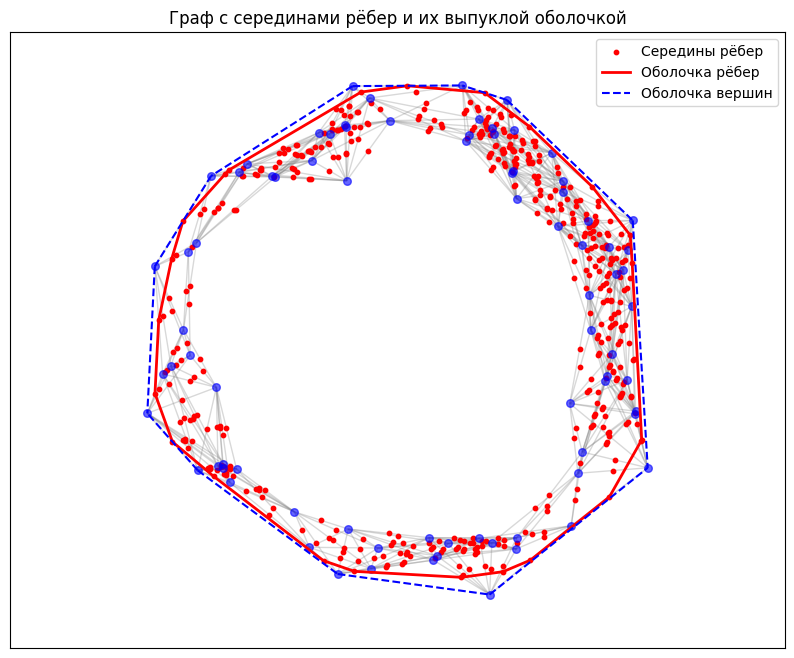

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}

# ---- Вычисление CHSE (Convex Hull Size of Edges) ----
def compute_chse(G, pos):
    """
    Вычисляет площадь и периметр выпуклой оболочки,
    построенной на серединах всех рёбер графа.
    """
    # Собираем середины рёбер
    mid_points = []
    for u, v in G.edges():
        mid = ((pos[u][0] + pos[v][0]) / 2,
               (pos[u][1] + pos[v][1]) / 2)
        mid_points.append(mid)
    
    # Если точек меньше 3, выпуклая оболочка не определена
    if len(mid_points) < 3:
        return 0.0, 0.0  # площадь, периметр
    
    # Преобразуем в массив numpy
    mid_points = np.array(mid_points)
    
    # Строим выпуклую оболочку
    hull = ConvexHull(mid_points)
    
    # Площадь (для 2D ConvexHull.area возвращает площадь)
    area = hull.area
    
    # Периметр (сумма длин рёбер оболочки)
    perimeter = 0.0
    for simplex in hull.simplices:
        p1 = mid_points[simplex[0]]
        p2 = mid_points[simplex[1]]
        perimeter += np.linalg.norm(p1 - p2)
    
    return area, perimeter

# Вычисляем CHSE для всего графа
chse_area, chse_perimeter = compute_chse(G, pos)
print(f"CHSE (площадь выпуклой оболочки середин рёбер): {chse_area:.4f}")
print(f"CHSE (периметр выпуклой оболочки середин рёбер): {chse_perimeter:.4f}")

# Для сравнения — площадь и периметр выпуклой оболочки самих вершин
if len(points) >= 3:
    hull_vertices = ConvexHull(points)
    vertices_area = hull_vertices.area
    vertices_perimeter = 0.0
    for simplex in hull_vertices.simplices:
        p1 = points[simplex[0]]
        p2 = points[simplex[1]]
        vertices_perimeter += np.linalg.norm(p1 - p2)
    print(f"\nПлощадь выпуклой оболочки вершин: {vertices_area:.4f}")
    print(f"Периметр выпуклой оболочки вершин: {vertices_perimeter:.4f}")

# ---- Визуализация графа, середин рёбер и выпуклой оболочки ----
plt.figure(figsize=(10, 8))

# Отрисовка вершин
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='blue', alpha=0.6)

# Отрисовка всех рёбер серым
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)

# Отрисовка середин рёбер
mid_points_list = [( (pos[u][0]+pos[v][0])/2, (pos[u][1]+pos[v][1])/2 ) 
                   for u, v in G.edges()]
if mid_points_list:
    mid_x, mid_y = zip(*mid_points_list)
    plt.scatter(mid_x, mid_y, c='red', s=10, label='Середины рёбер')

# Отрисовка выпуклой оболочки середин рёбер (если есть)
if len(mid_points_list) >= 3:
    mid_pts = np.array(mid_points_list)
    hull_edges = ConvexHull(mid_pts)
    # Добавляем замкнутый контур
    for simplex in hull_edges.simplices:
        plt.plot([mid_pts[simplex[0], 0], mid_pts[simplex[1], 0]],
                 [mid_pts[simplex[0], 1], mid_pts[simplex[1], 1]],
                 'r-', linewidth=2, label='Оболочка рёбер' if simplex[0] == hull_edges.simplices[0][0] else "")

# Также можно отобразить оболочку вершин для сравнения (пунктиром)
if len(points) >= 3:
    hull_v = ConvexHull(points)
    for simplex in hull_v.simplices:
        plt.plot([points[simplex[0], 0], points[simplex[1], 0]],
                 [points[simplex[0], 1], points[simplex[1], 1]],
                 'b--', linewidth=1.5, label='Оболочка вершин' if simplex[0] == hull_v.simplices[0][0] else "")

plt.title("Граф с серединами рёбер и их выпуклой оболочкой")
plt.axis('equal')
plt.legend()
plt.show()

### 24. Фактор локализации вершин (Vertex Localization Factor) 
- VLF – Фактор локализации вершин
- Что измеряет: Мера того, насколько вершины сгруппированы в небольшой области пространства (например, отношение площади минимального охватывающего круга к общей площади).
- Показывает, сосредоточены ли вершины в компактной области или разбросаны.

=== VLF (Vertex Localization Factor) ===
Площадь минимального описанного круга: 4.5194
Площадь выпуклой оболочки вершин:    7.1800
VLF (круг / оболочка):               0.6294
Интерпретация: значение близкое к 1.0 означает, что вершины компактно 'заполняют' круглую область.
               Значение значительно меньше 1.0 (например, 0.7) говорит о вытянутой или угловатой форме.


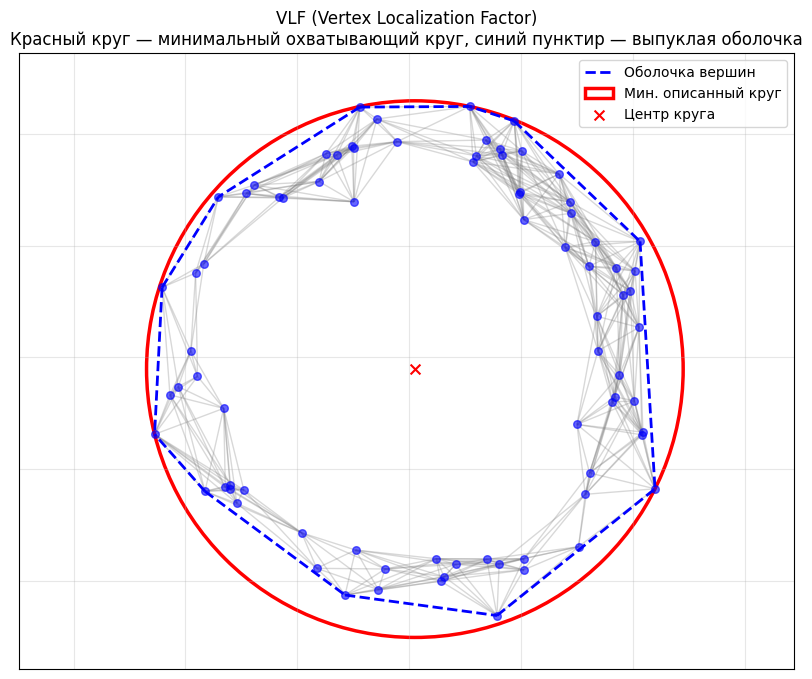

In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}

# ---- Функция для вычисления минимального описанного круга ----
def minimum_enclosing_circle(points):
    """
    Находит минимальный круг, охватывающий все точки (алгоритм перебора пар и троек).
    Возвращает (центр, радиус).
    """
    def circle_from_2_points(p1, p2):
        center = (p1 + p2) / 2.0
        radius = np.linalg.norm(p1 - p2) / 2.0
        return center, radius

    def circle_from_3_points(p1, p2, p3):
        # Описанная окружность для трёх точек (если не коллинеарны)
        ax, ay = p1
        bx, by = p2
        cx, cy = p3
        d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
        if abs(d) < 1e-12:
            return None, None  # Коллинеарны, круг не определён
        ux = ((ax**2 + ay**2) * (by - cy) +
              (bx**2 + by**2) * (cy - ay) +
              (cx**2 + cy**2) * (ay - by)) / d
        uy = ((ax**2 + ay**2) * (cx - bx) +
              (bx**2 + by**2) * (ax - cx) +
              (cx**2 + cy**2) * (bx - ax)) / d
        center = np.array([ux, uy])
        radius = np.linalg.norm(center - p1)
        return center, radius

    n = len(points)
    if n == 0:
        return None, 0.0
    if n == 1:
        return points[0], 0.0
    if n == 2:
        return circle_from_2_points(points[0], points[1])

    best_radius = np.inf
    best_center = None

    # 1) Проверяем все пары как потенциальный диаметр
    for i in range(n):
        for j in range(i + 1, n):
            c, r = circle_from_2_points(points[i], points[j])
            if c is not None:
                # Проверяем, все ли точки внутри круга
                if np.all(np.linalg.norm(points - c, axis=1) <= r + 1e-9):
                    if r < best_radius:
                        best_radius = r
                        best_center = c

    # 2) Проверяем все тройки как описанные окружности
    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                c, r = circle_from_3_points(points[i], points[j], points[k])
                if c is not None:
                    if np.all(np.linalg.norm(points - c, axis=1) <= r + 1e-9):
                        if r < best_radius:
                            best_radius = r
                            best_center = c

    return best_center, best_radius

# ---- Вычисление VLF (Vertex Localization Factor) ----
def compute_vlf(points):
    """
    Вычисляет фактор локализации вершин:
    VLF = (площадь минимального описанного круга) / (площадь выпуклой оболочки вершин).
    """
    if len(points) < 3:
        print("Недостаточно точек для построения выпуклой оболочки.")
        return None, None, None

    # 1) Выпуклая оболочка вершин
    hull = ConvexHull(points)
    hull_area = hull.area  # Для 2D ConvexHull.area возвращает площадь

    # 2) Минимальный описанный круг
    center, radius = minimum_enclosing_circle(points)
    circle_area = np.pi * radius**2

    # 3) VLF
    vlf = circle_area / hull_area
    return vlf, center, radius

# Вычисляем VLF для нашего графа
vlf, circle_center, circle_radius = compute_vlf(points)

if vlf is not None:
    print(f"=== VLF (Vertex Localization Factor) ===")
    print(f"Площадь минимального описанного круга: {np.pi * circle_radius**2:.4f}")
    print(f"Площадь выпуклой оболочки вершин:    {ConvexHull(points).area:.4f}")
    print(f"VLF (круг / оболочка):               {vlf:.4f}")
    print(f"Интерпретация: значение близкое к 1.0 означает, что вершины компактно 'заполняют' круглую область.")
    print(f"               Значение значительно меньше 1.0 (например, 0.7) говорит о вытянутой или угловатой форме.")
else:
    print("Невозможно вычислить VLF.")

# ---- Визуализация ----
plt.figure(figsize=(10, 8))

# Отрисовка вершин
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='blue', alpha=0.6)

# Отрисовка всех рёбер
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)

# Отрисовка выпуклой оболочки вершин (пунктир)
if len(points) >= 3:
    hull_vertices = ConvexHull(points)
    for simplex in hull_vertices.simplices:
        plt.plot([points[simplex[0], 0], points[simplex[1], 0]],
                 [points[simplex[0], 1], points[simplex[1], 1]],
                 'b--', linewidth=2, label='Оболочка вершин' if simplex[0] == hull_vertices.simplices[0][0] else "")

# Отрисовка минимального описанного круга
if circle_center is not None:
    circle = plt.Circle(circle_center, circle_radius, color='red', fill=False, linewidth=2.5, label='Мин. описанный круг')
    plt.gca().add_patch(circle)
    plt.scatter(circle_center[0], circle_center[1], c='red', s=50, marker='x', label='Центр круга')

plt.title("VLF (Vertex Localization Factor)\nКрасный круг — минимальный охватывающий круг, синий пунктир — выпуклая оболочка")
plt.axis('equal')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 25. Интервал изолированности (Isolation Interval, II)
- II – Интервал изолированности
- Что измеряет: Среднее расстояние между изолированными вершинами (или доля вершин без соседей) в графе.
- Интерпритация: Характеризует наличие «выбросов» – вершин, слабо связанных с остальными.

=== Isolation Interval (II) ===
Всего вершин:          80
Изолированных вершин:  0
Доля изолированных:    0.0000 (0.00%)
Среднее расстояние: не определено (менее 2 изолированных вершин)


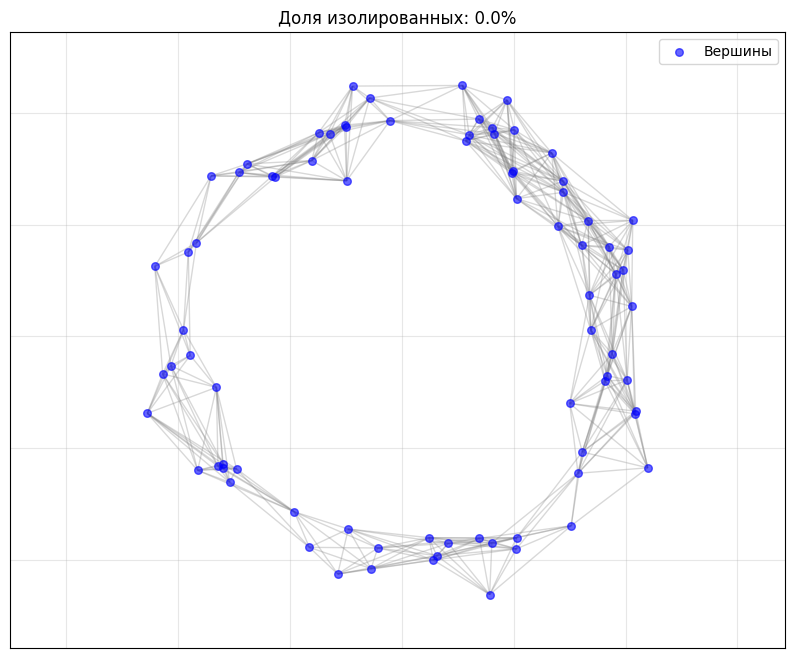

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}

# ---- Вычисление Isolation Interval (II) ----
def compute_ii(G, pos):
    """
    Вычисляет интервал изолированности:
    - доля вершин со степенью 0
    - среднее евклидово расстояние между изолированными вершинами (если их ≥ 2)
    """
    # Находим изолированные вершины (степень = 0)
    isolated = [v for v in G.nodes() if G.degree(v) == 0]
    n_isolated = len(isolated)
    fraction = n_isolated / G.number_of_nodes() if G.number_of_nodes() > 0 else 0.0
    
    avg_distance = None
    if n_isolated >= 2:
        # Получаем координаты изолированных вершин
        coords = np.array([pos[v] for v in isolated])
        # Попарные евклидовы расстояния
        distances = pdist(coords)  # возвращает массив
        avg_distance = np.mean(distances)
    
    return fraction, avg_distance, isolated

fraction, avg_dist, isolated_nodes = compute_ii(G, pos)

print(f"=== Isolation Interval (II) ===")
print(f"Всего вершин:          {G.number_of_nodes()}")
print(f"Изолированных вершин:  {len(isolated_nodes)}")
print(f"Доля изолированных:    {fraction:.4f} ({fraction*100:.2f}%)")
if avg_dist is not None:
    print(f"Среднее расстояние между изолированными вершинами: {avg_dist:.4f}")
else:
    print("Среднее расстояние: не определено (менее 2 изолированных вершин)")

# ---- Визуализация ----
plt.figure(figsize=(10, 8))

# Все вершины (синие)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='blue', alpha=0.6, label='Вершины')

# Изолированные вершины (красные, увеличены)
if isolated_nodes:
    nx.draw_networkx_nodes(G, pos, nodelist=isolated_nodes, node_size=60, node_color='red', label='Изолированные')

# Все рёбра (серые)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)

# Если есть изолированные вершины, отобразим расстояния между ними (пунктирные линии)
if isolated_nodes and len(isolated_nodes) >= 2:
    for i in range(len(isolated_nodes)):
        for j in range(i+1, len(isolated_nodes)):
            v1 = isolated_nodes[i]
            v2 = isolated_nodes[j]
            plt.plot([pos[v1][0], pos[v2][0]],
                     [pos[v1][1], pos[v2][1]],
                     'r--', linewidth=1, alpha=0.5)

plt.title(f"Isolation Interval (II)\nДоля изолированных: {fraction*100:.1f}% | "
          f"Ср. расстояние: {avg_dist:.3f}" if avg_dist is not None else 
          f"Доля изолированных: {fraction*100:.1f}%")
plt.axis('equal')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 26. Комбинированный индекс распредмечивания (Combined Declustering Index, CDI)
- CDI – Комбинированный индекс распредмечивания
- Что измеряет: Интегральная мера, объединяющая разброс координат, плотность рёбер и гетерогенность связей (часто через энтропию).
- Интерпритация: Оценивает, насколько граф «распределён» (декластеризован). Высокий CDI → структура размыта, низкий → скученность.

=== Комбинированный индекс распредмечивания (CDI) ===
Пространственный разброс:       0.7536
Разрежённость рёбер (1 - плотн.): 0.8491
Нормализованная энтропия степеней: 0.5359
CDI (среднее арифметическое):   0.7128

Интерпретация:
  CDI ~ 0  → вершины скучены, граф плотный, степени однородны (чёткие кластеры).
  CDI ~ 1  → вершины разбросаны, граф разрежен, степени разнообразны (размытая структура).


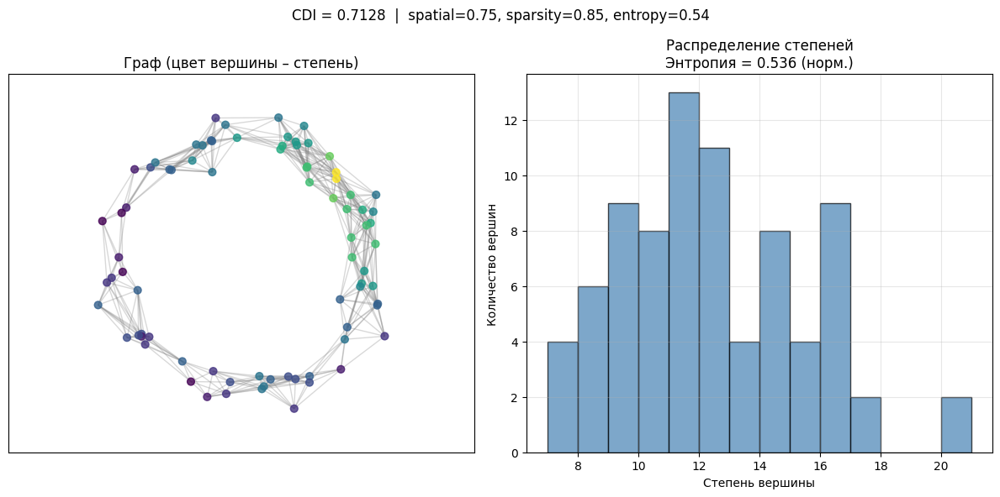

In [11]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from collections import Counter

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Функция вычисления CDI ----
def compute_cdi(G, pos):
    # 1. Пространственный разброс (spatial spread)
    coords = np.array([pos[v] for v in G.nodes()])
    centroid = np.mean(coords, axis=0)
    distances = np.linalg.norm(coords - centroid, axis=1)
    mean_dist = np.mean(distances)
    max_dist = np.max(distances) if len(distances) > 0 else 1.0
    spatial_spread = mean_dist / max_dist if max_dist > 1e-12 else 0.0

    # 2. Плотность рёбер (edge density)
    max_edges = n * (n - 1) / 2
    density = m / max_edges if max_edges > 0 else 0.0
    edge_sparsity = 1.0 - density   # чем выше, тем более разрежен граф

    # 3. Энтропия степеней (degree entropy)
    degrees = [d for _, d in G.degree()]
    degree_counts = Counter(degrees)
    probs = np.array([count / n for count in degree_counts.values()])
    entropy = -np.sum(probs * np.log(probs + 1e-12))  # добавим eps для устойчивости
    max_entropy = np.log(n) if n > 1 else 1.0
    degree_entropy = entropy / max_entropy if max_entropy > 0 else 0.0

    # Итоговый CDI как среднее трёх компонент
    cdi = (spatial_spread + edge_sparsity + degree_entropy) / 3.0
    return cdi, spatial_spread, edge_sparsity, degree_entropy

cdi, spatial, sparsity, entrop = compute_cdi(G, pos)

print("=== Комбинированный индекс распредмечивания (CDI) ===")
print(f"Пространственный разброс:       {spatial:.4f}")
print(f"Разрежённость рёбер (1 - плотн.): {sparsity:.4f}")
print(f"Нормализованная энтропия степеней: {entrop:.4f}")
print(f"CDI (среднее арифметическое):   {cdi:.4f}")
print("\nИнтерпретация:")
print("  CDI ~ 0  → вершины скучены, граф плотный, степени однородны (чёткие кластеры).")
print("  CDI ~ 1  → вершины разбросаны, граф разрежен, степени разнообразны (размытая структура).")

# ---- Визуализация графа с цветовой кодировкой по степени ----
plt.figure(figsize=(12, 6))

# Граф с цветом по степени
degrees = dict(G.degree())
node_colors = [degrees[v] for v in G.nodes()]

plt.subplot(1, 2, 1)
nx.draw_networkx_nodes(G, pos, node_size=40, node_color=node_colors, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
plt.title("Граф (цвет вершины – степень)")
plt.axis('equal')

# Гистограмма степеней
plt.subplot(1, 2, 2)
degree_vals = list(degrees.values())
plt.hist(degree_vals, bins=range(min(degree_vals), max(degree_vals)+2), 
         alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Степень вершины')
plt.ylabel('Количество вершин')
plt.title(f'Распределение степеней\nЭнтропия = {entrop:.3f} (норм.)')
plt.grid(alpha=0.3)

plt.suptitle(f"CDI = {cdi:.4f}  |  spatial={spatial:.2f}, sparsity={sparsity:.2f}, entropy={entrop:.2f}")
plt.tight_layout()
plt.show()

### 27. Центральность по собственному вектору (Eigenvector Centrality, EC) 
- EC – Центральность по собственному вектору
- Что измеряет: Для каждой вершины – значение соответствующей компоненты главного собственного вектора матрицы смежности.
- Интерпритация: Показывает не только степень, но и «качество» соседей (влиятельные соседи повышают центральность).

=== Eigenvector Centrality (EC) ===
Топ-10 вершин по EC:
  1. Вершина 79: EC = 0.259999
  2. Вершина 40: EC = 0.259564
  3. Вершина 66: EC = 0.226674
  4. Вершина 37: EC = 0.224137
  5. Вершина 21: EC = 0.216485
  6. Вершина 56: EC = 0.212545
  7. Вершина 68: EC = 0.212545
  8. Вершина 4: EC = 0.212000
  9. Вершина 5: EC = 0.212000
  10. Вершина 32: EC = 0.193199

Минимальное EC: 0.000051
Максимальное EC: 0.259999
Среднее EC:     0.073051

Корреляция EC со степенью вершины: 0.8861


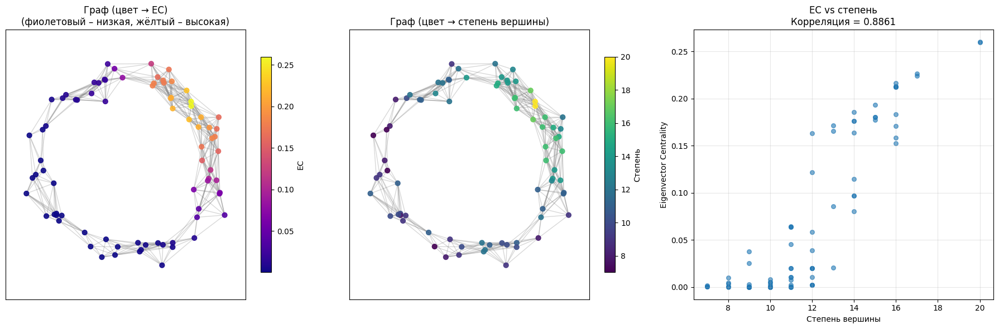

In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}

# ---- Проверка связности графа ----
if not nx.is_connected(G):
    print("Внимание: граф несвязный. Eigenvector Centrality определена только для связных графов.")
    print("Будет вычислена центральность по компонентам, но глобальная интерпретация может быть неоднозначной.")
    # Для несвязных графов можно вычислить EC отдельно для каждой компоненты,
    # но тогда значения не будут сопоставимы между компонентами.
    # В этом примере мы всё равно вычислим через numpy-версию (даёт вектор для наибольшего собственного значения всей матрицы).
    ec = nx.eigenvector_centrality_numpy(G, weight='weight')
else:
    # Используем стандартную реализацию (итеративный метод) — требует связности
    ec = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)

# ---- Вывод результатов ----
print("=== Eigenvector Centrality (EC) ===")
# Сортируем вершины по убыванию EC
sorted_ec = sorted(ec.items(), key=lambda x: x[1], reverse=True)
print("Топ-10 вершин по EC:")
for i, (node, val) in enumerate(sorted_ec[:10]):
    print(f"  {i+1}. Вершина {node}: EC = {val:.6f}")

print(f"\nМинимальное EC: {min(ec.values()):.6f}")
print(f"Максимальное EC: {max(ec.values()):.6f}")
print(f"Среднее EC:     {np.mean(list(ec.values())):.6f}")

# Сравнение со степенью вершины (для интерпретации)
degrees = dict(G.degree())
# Коэффициент корреляции Пирсона между EC и степенью
corr = np.corrcoef([ec[v] for v in G.nodes()], [degrees[v] for v in G.nodes()])[0,1]
print(f"\nКорреляция EC со степенью вершины: {corr:.4f}")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Граф с цветом по EC
ax1 = axes[0]
node_colors_ec = [ec[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors_ec, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title("Граф (цвет → EC)\n(фиолетовый – низкая, жёлтый – высокая)")
ax1.axis('equal')
# Добавим colorbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(ec.values()), vmax=max(ec.values())))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('EC')

# 2. Граф с цветом по степени (для сравнения)
ax2 = axes[1]
node_colors_deg = [degrees[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax2, node_size=40, node_color=node_colors_deg, cmap='viridis', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax2, edge_color='gray', alpha=0.3)
ax2.set_title("Граф (цвет → степень вершины)")
ax2.axis('equal')
sm2 = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax2, shrink=0.8)
cbar2.set_label('Степень')

# 3. Диаграмма рассеяния: EC vs степень
ax3 = axes[2]
ec_vals = [ec[v] for v in G.nodes()]
deg_vals = [degrees[v] for v in G.nodes()]
ax3.scatter(deg_vals, ec_vals, alpha=0.6, s=30)
ax3.set_xlabel('Степень вершины')
ax3.set_ylabel('Eigenvector Centrality')
ax3.set_title(f'EC vs степень\nКорреляция = {corr:.4f}')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 28. Спектральный радиус (Spectral Radius, SR) 
- SR – Спектральный радиус
- Что измеряет: Наибольшее собственное значение матрицы смежности (или Лапласиана).
- Интепритация: Характеризует «энергетику» графа. Большой SR → сильная связность и высокая степень кластеризации.

=== Спектральный радиус (Spectral Radius, SR) ===
Число вершин:       80
Число рёбер:         477
Спектральный радиус: 14.995357
Средняя степень:     11.9250
Максимальная степень: 20

Собственные значения (первые 5 наибольших):
  λ1 = 14.995357
  λ2 = 11.632706
  λ3 = 10.435613
  λ4 = 9.826382
  λ5 = 8.929198

Теоретические оценки:
  SR >= sqrt(средняя_квадрат_степени) = 12.2943
  SR <= max_степень = 20


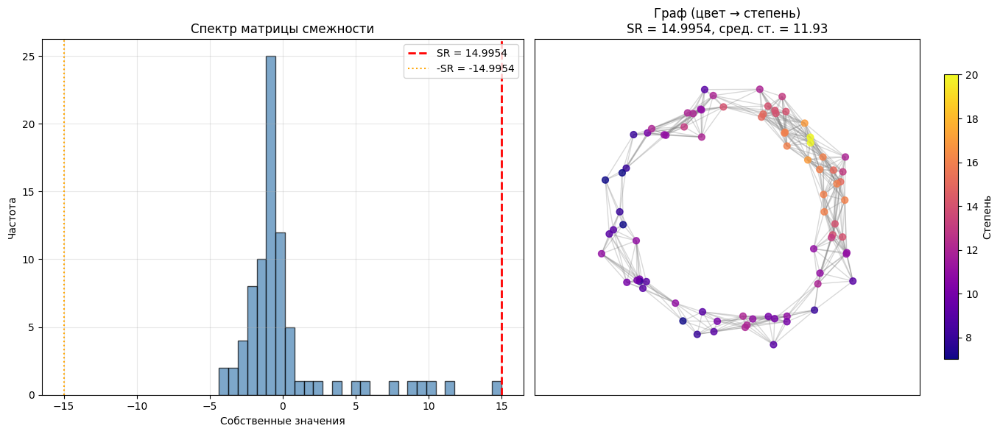

In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление спектрального радиуса ----
def compute_spectral_radius(G):
    """
    Вычисляет спектральный радиус графа:
    - наибольшее собственное значение матрицы смежности.
    Возвращает SR и все собственные значения.
    """
    # Матрица смежности
    adj_matrix = nx.adjacency_matrix(G).todense()  # плотная матрица для вычисления собственных значений
    eigenvals = np.linalg.eigvalsh(adj_matrix)      # для симметричной матрицы
    sr = np.max(eigenvals)
    return sr, eigenvals

sr, eigenvalues = compute_spectral_radius(G)

print(f"=== Спектральный радиус (Spectral Radius, SR) ===")
print(f"Число вершин:       {n}")
print(f"Число рёбер:         {m}")
print(f"Спектральный радиус: {sr:.6f}")
print(f"Средняя степень:     {2*m/n:.4f}")
print(f"Максимальная степень: {max(dict(G.degree()).values())}")
print(f"\nСобственные значения (первые 5 наибольших):")
sorted_vals = np.sort(eigenvalues)[::-1]  # по убыванию
for i, val in enumerate(sorted_vals[:5]):
    print(f"  λ{i+1} = {val:.6f}")

# ---- Сравнение с теоретическими оценками ----
# Для регулярного графа степени d: SR = d.
# Для нерегулярного: SR >= sqrt(средняя_квадрат_степени) и SR <= max_степень.
print(f"\nТеоретические оценки:")
print(f"  SR >= sqrt(средняя_квадрат_степени) = {np.sqrt(np.mean([d**2 for d in dict(G.degree()).values()])):.4f}")
print(f"  SR <= max_степень = {max(dict(G.degree()).values())}")

# ---- Визуализация спектра ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Гистограмма распределения собственных значений
ax1 = axes[0]
ax1.hist(eigenvalues, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(sr, color='red', linestyle='--', linewidth=2, label=f'SR = {sr:.4f}')
ax1.axvline(-sr, color='orange', linestyle=':', linewidth=1.5, label=f'-SR = {-sr:.4f}')
ax1.set_xlabel('Собственные значения')
ax1.set_ylabel('Частота')
ax1.set_title('Спектр матрицы смежности')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Граф с цветовой кодировкой по степени (для визуализации структуры)
ax2 = axes[1]
degrees = dict(G.degree())
node_colors = [degrees[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax2, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax2, edge_color='gray', alpha=0.3)
ax2.set_title(f'Граф (цвет → степень)\nSR = {sr:.4f}, сред. ст. = {2*m/n:.2f}')
ax2.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
sm.set_array([])
plt.colorbar(sm, ax=ax2, shrink=0.8, label='Степень')

plt.tight_layout()
plt.show()

### 29. Индекс влияния (Influence Index, II) 
- II2 – Индекс влияния (Influence Index)
- Что измеряет: Интегральная метрика, часто как произведение (или сумма) центральностей и атрибутов вершин.
- Интерпритация: Показывает общую «силу» влияния вершины в сети с учётом структуры и семантики.

=== Influence Index (II) ===
Используемые компоненты и веса:
  degree: 0.250
  closeness: 0.250
  betweenness: 0.250
  attr: 0.250

Топ-10 вершин по индексу влияния:
  1. Вершина 44: II = 0.369894
  2. Вершина 6: II = 0.359662
  3. Вершина 58: II = 0.358991
  4. Вершина 71: II = 0.356028
  5. Вершина 37: II = 0.350793
  6. Вершина 47: II = 0.343826
  7. Вершина 21: II = 0.336360
  8. Вершина 79: II = 0.335563
  9. Вершина 38: II = 0.320107
  10. Вершина 66: II = 0.318685

Минимальный II: 0.093552
Максимальный II: 0.369894
Средний II:     0.234023


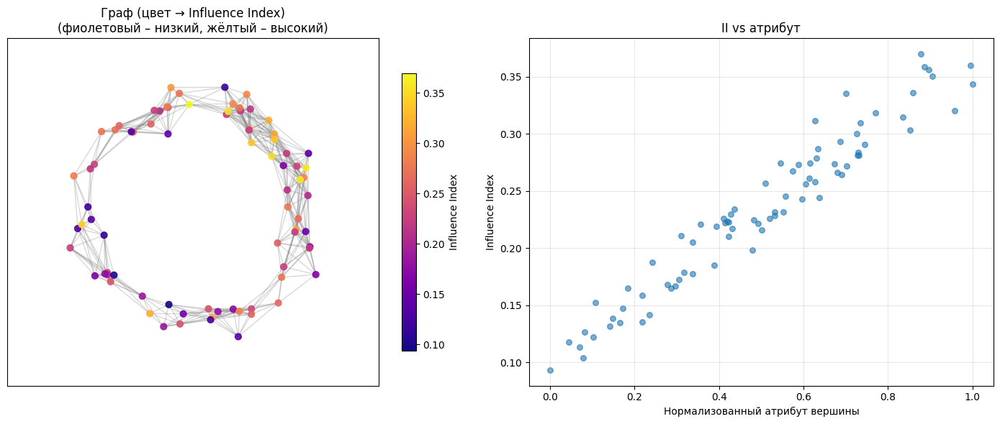

In [14]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()

# ---- Опционально: добавим атрибуты вершин (для примера) ----
# В реальных данных атрибуты могут быть загружены из внешнего источника.
# Здесь мы создадим синтетический атрибут "важность" как случайное число от 0 до 1.
np.random.seed(123)
attr = {v: np.random.uniform(0.5, 1.0) for v in G.nodes()}  # вес вершины (например, значимость)

# ---- Вычисление Influence Index (II) ----
def compute_influence_index(G, attr=None, weights=None, use_centralities=None):
    """
    Вычисляет индекс влияния для каждой вершины как взвешенную сумму
    нормализованных центральностей и (опционально) нормализованных атрибутов.
    
    Параметры:
        G: граф NetworkX
        attr: словарь {узел: значение} для атрибутов вершин (или None)
        weights: словарь с весами для каждой компоненты, например:
                 {'degree': 0.3, 'closeness': 0.3, 'betweenness': 0.3, 'attr': 0.1}
                 Если None, используются равные веса для включённых компонент.
        use_centralities: список строк, какие центральности использовать.
                 По умолчанию ['degree', 'closeness', 'betweenness'].
    """
    # Центральности
    if use_centralities is None:
        use_centralities = ['degree', 'closeness', 'betweenness']
    
    centralities = {}
    
    # Степень (Degree Centrality) – уже нормализована в NetworkX (делится на n-1)
    if 'degree' in use_centralities:
        centralities['degree'] = nx.degree_centrality(G)
    
    # Близость (Closeness Centrality) – требует связного графа
    if 'closeness' in use_centralities:
        if nx.is_connected(G):
            centralities['closeness'] = nx.closeness_centrality(G)
        else:
            print("Предупреждение: граф несвязный. Closeness centrality будет вычислена для каждой компоненты,",
                  "но значения могут быть несопоставимы. Пропускаем closeness.")
            use_centralities.remove('closeness')
    
    # Посредничество (Betweenness Centrality) – нормализована по умолчанию (делится на (n-1)(n-2)/2)
    if 'betweenness' in use_centralities:
        centralities['betweenness'] = nx.betweenness_centrality(G, normalized=True)
    
    # Если есть атрибуты, нормализуем их (min-max)
    attr_norm = None
    if attr is not None:
        vals = np.array([attr[v] for v in G.nodes()])
        if vals.max() - vals.min() > 1e-12:
            attr_norm = {v: (attr[v] - vals.min()) / (vals.max() - vals.min()) for v in G.nodes()}
        else:
            attr_norm = {v: 1.0 for v in G.nodes()}
    
    # Определяем веса для каждой компоненты
    comp_names = list(centralities.keys())
    if attr_norm is not None:
        comp_names.append('attr')
    
    if weights is None:
        # Равные веса
        w = {name: 1.0/len(comp_names) for name in comp_names}
    else:
        # Используем заданные веса, оставшиеся компоненты получают равные остаточные доли
        w = {}
        total_given = sum(weights.get(name, 0.0) for name in comp_names)
        remaining = 1.0 - total_given
        num_remaining = sum(1 for name in comp_names if name not in weights)
        if num_remaining > 0:
            rem_weight = remaining / num_remaining
        else:
            rem_weight = 0.0
        for name in comp_names:
            w[name] = weights.get(name, rem_weight)
        # Нормализуем, чтобы сумма была 1 (на случай неточностей)
        total = sum(w.values())
        if total > 0:
            w = {name: val/total for name, val in w.items()}
    
    # Вычисляем индекс для каждой вершины
    influence = {}
    for v in G.nodes():
        score = 0.0
        for name in centralities:
            score += w[name] * centralities[name][v]
        if attr_norm is not None:
            score += w['attr'] * attr_norm[v]
        influence[v] = score
    
    return influence, centralities, attr_norm, w

# Вычисляем Influence Index с равными весами для degree, closeness, betweenness
ii, centr, attr_norm, weights_used = compute_influence_index(G, attr=attr)

print("=== Influence Index (II) ===")
print("Используемые компоненты и веса:")
for name, w in weights_used.items():
    print(f"  {name}: {w:.3f}")

# Сортируем вершины по убыванию Influence Index
sorted_ii = sorted(ii.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 вершин по индексу влияния:")
for i, (node, val) in enumerate(sorted_ii[:10]):
    print(f"  {i+1}. Вершина {node}: II = {val:.6f}")

print(f"\nМинимальный II: {min(ii.values()):.6f}")
print(f"Максимальный II: {max(ii.values()):.6f}")
print(f"Средний II:     {np.mean(list(ii.values())):.6f}")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по Influence Index
ax1 = axes[0]
node_colors = [ii[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title("Граф (цвет → Influence Index)\n(фиолетовый – низкий, жёлтый – высокий)")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(ii.values()), vmax=max(ii.values())))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Influence Index')

# 2. Сравнение с атрибутом (если он есть)
ax2 = axes[1]
if attr_norm is not None:
    attr_vals = [attr_norm[v] for v in G.nodes()]
    ax2.scatter(attr_vals, [ii[v] for v in G.nodes()], alpha=0.6, s=30)
    ax2.set_xlabel('Нормализованный атрибут вершины')
    ax2.set_ylabel('Influence Index')
    ax2.set_title('II vs атрибут')
    ax2.grid(alpha=0.3)
else:
    # Если нет атрибутов, покажем гистограмму распределения II
    ax2.hist(list(ii.values()), bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    ax2.set_xlabel('Influence Index')
    ax2.set_ylabel('Количество вершин')
    ax2.set_title('Распределение Influence Index')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 30. Индекс семантической связности (Semantic Connectivity Index, SCI)
- SCI – Индекс семантической связности
- Что измеряет: Мера близости вершин по атрибутам (например, корреляция признаков) с учётом наличия рёбер.
- Интерпритация: Высокий SCI → вершины, соединённые рёбрами, имеют схожие атрибуты (гомофилия).

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import normalize
from itertools import combinations
import community as community_louvain  # для обнаружения сообществ (если нужно)

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()

# ---- Функция вычисления SCI ----
def compute_sci(G, attr_dict, similarity='cosine', normalize_attr=True):
    """
    Вычисляет Semantic Connectivity Index (SCI):
    среднее сходство атрибутов между вершинами, соединёнными рёбрами.

    Параметры:
        G: граф NetworkX
        attr_dict: словарь {вершина: вектор признаков} (numpy array)
        similarity: 'cosine' или 'euclidean' (преобразуем в сходство)
        normalize_attr: нормализовать ли признаки перед вычислением
    """
    # Получаем список вершин и строим матрицу признаков в порядке вершин
    nodes = list(G.nodes())
    attr_matrix = np.array([attr_dict[v] for v in nodes])
    
    if normalize_attr:
        # Нормализуем признаки (центрирование + масштабирование или min-max)
        # Здесь используем стандартизацию (z-score)
        mean = np.mean(attr_matrix, axis=0)
        std = np.std(attr_matrix, axis=0)
        std[std == 0] = 1.0  # избегаем деления на ноль
        attr_matrix = (attr_matrix - mean) / std
    
    # Вычисляем сходство для каждого ребра
    similarities = []
    for u, v in G.edges():
        a_u = attr_matrix[nodes.index(u)]
        a_v = attr_matrix[nodes.index(v)]
        if similarity == 'cosine':
            # Косинусное сходство
            norm_u = np.linalg.norm(a_u)
            norm_v = np.linalg.norm(a_v)
            if norm_u == 0 or norm_v == 0:
                sim = 0.0
            else:
                sim = np.dot(a_u, a_v) / (norm_u * norm_v)
            # Приводим к [0,1] (косинус может быть отрицательным)
            sim = (sim + 1) / 2.0
        elif similarity == 'euclidean':
            # Евклидово расстояние -> преобразуем в сходство (exp(-dist) или 1/(1+dist))
            dist = np.linalg.norm(a_u - a_v)
            sim = 1.0 / (1.0 + dist)  # в [0,1]
        else:
            raise ValueError("Поддерживаются только 'cosine' и 'euclidean'")
        similarities.append(sim)
    
    sci_global = np.mean(similarities) if similarities else 0.0
    return sci_global, similarities

# Вычисляем SCI для нашего графа, используя координаты как атрибуты
sci, edge_sims = compute_sci(G, pos, similarity='cosine', normalize_attr=True)

print("=== Semantic Connectivity Index (SCI) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {G.number_of_edges()}")
print(f"SCI (среднее косинусное сходство по рёбрам): {sci:.6f}")
print(f"Минимальное сходство ребра: {min(edge_sims):.6f}")
print(f"Максимальное сходство ребра: {max(edge_sims):.6f}")

# ---- Дополнительно: SCI внутри сообществ (если установлен community-louvain) ----
try:
    # Обнаружение сообществ алгоритмом Лувена
    partition = community_louvain.best_partition(G)
    communities = {}
    for v, comm in partition.items():
        communities.setdefault(comm, []).append(v)
    
    # Вычисляем SCI для каждого сообщества
    sci_comm = {}
    for comm_id, vertices in communities.items():
        if len(vertices) > 1:
            subgraph = G.subgraph(vertices)
            # Атрибуты только для вершин сообщества
            attr_sub = {v: pos[v] for v in vertices}
            sci_comm[comm_id], _ = compute_sci(subgraph, attr_sub, similarity='cosine', normalize_attr=True)
        else:
            sci_comm[comm_id] = None  # одноэлементное сообщество, SCI не определён
    
    # Усреднённый SCI по сообществам (игнорируем None)
    sci_vals = [v for v in sci_comm.values() if v is not None]
    sci_avg = np.mean(sci_vals) if sci_vals else 0.0
    print(f"\nСообщества (алгоритм Лувена):")
    print(f"  Число сообществ: {len(communities)}")
    print(f"  Средний SCI по сообществам: {sci_avg:.6f}")
    for comm_id, val in sci_comm.items():
        print(f"    Сообщество {comm_id}: размер {len(communities[comm_id])}, SCI = {val if val is not None else 'N/A'}")
except ImportError:
    print("\nУстановите python-louvain для расчёта SCI внутри сообществ: pip install python-louvain")
    partition = None

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом рёбер по сходству
ax1 = axes[0]
# Рисуем вершины
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
# Рёбра с цветовой кодировкой по сходству
edges = list(G.edges())
edge_colors = edge_sims
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=edges, edge_color=edge_colors, edge_cmap='viridis', width=2, alpha=0.8)
ax1.set_title(f"Граф (цвет рёбер – семантическое сходство)\nSCI глобальный = {sci:.4f}")
ax1.axis('equal')
# Colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(edge_sims), vmax=max(edge_sims)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Сходство атрибутов')

# 2. Гистограмма сходств рёбер
ax2 = axes[1]
ax2.hist(edge_sims, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(sci, color='red', linestyle='--', linewidth=2, label=f'SCI = {sci:.4f}')
ax2.set_xlabel('Сходство атрибутов на ребре')
ax2.set_ylabel('Количество рёбер')
ax2.set_title('Распределение семантического сходства рёбер')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Опционально: если есть сообщества, покажем их ----
if partition is not None:
    plt.figure(figsize=(10, 8))
    # Цвет вершин по сообществам
    comm_colors = [partition[v] for v in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=comm_colors, cmap='tab20', alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
    plt.title("Сообщества (цвет вершины – сообщество)")
    plt.axis('equal')
    plt.show()

ModuleNotFoundError: No module named 'community'

### 31. Центральность по доступу (Access Centrality, AC)
- AC – Центральность по доступу
- Что измеряет: Вероятность достижения вершины из случайно выбранной точки графа (обычно вычисляется как средняя обратная длина кратчайшего пути).
- Интерпритация: Показывает, насколько вершина «доступна» с других частей графа.

=== Access Centrality (AC) ===
Число вершин: 80
Число рёбер:  477
Граф связен? True

Топ-10 вершин по AC:
  1. Вершина 79: AC = 0.458966
  2. Вершина 40: AC = 0.456857
  3. Вершина 58: AC = 0.435383
  4. Вершина 42: AC = 0.433273
  5. Вершина 29: AC = 0.429054
  6. Вершина 66: AC = 0.428165
  7. Вершина 37: AC = 0.426884
  8. Вершина 26: AC = 0.426597
  9. Вершина 71: AC = 0.426597
  10. Вершина 32: AC = 0.422725

Минимальный AC: 0.307459
Максимальный AC: 0.458966
Средний AC:     0.372310

Корреляция AC с Closeness Centrality: 0.9520


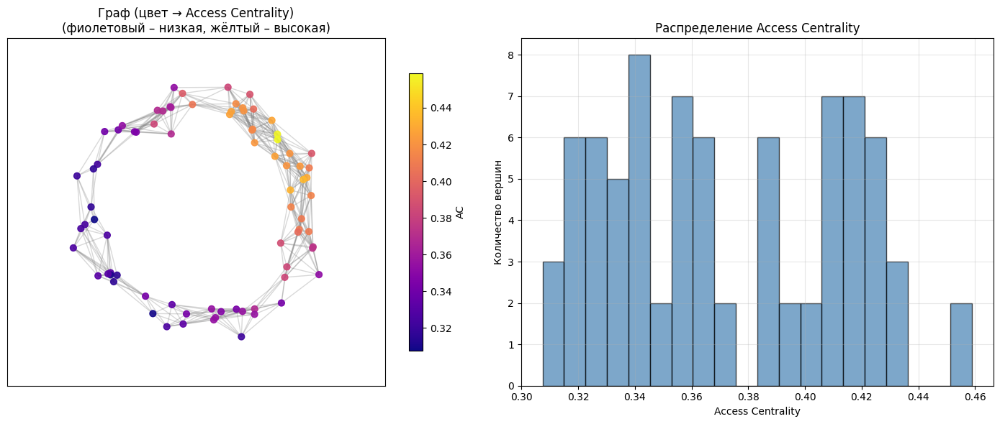

In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()

# ---- Вычисление Access Centrality (AC) ----
def compute_access_centrality(G, normalized=True):
    """
    Вычисляет Access Centrality (гармоническую центральность) для каждой вершины.
    
    Параметры:
        G: граф NetworkX
        normalized: если True, нормализуем на (n-1) для связного графа,
                    или на число достижимых вершин для каждой вершины.
                    Если False, возвращаем сумму обратных расстояний.
    """
    # Используем встроенную гармоническую центральность (сумма 1/d, где d - кратчайшее расстояние)
    # Для недостижимых вершин вклад равен 0 (по умолчанию в NetworkX).
    harmonic = nx.harmonic_centrality(G, distance=None)  # distance=None означает кратчайшие пути
    
    if normalized:
        # Нормализуем: делим на (n-1), если граф связный, или на число достижимых вершин.
        # В NetworkX harmonic_centrality уже может быть нормализована? По умолчанию нет (она возвращает сумму).
        # Проверим: в документации: harmonic_centrality(G, nbunch=None, distance=None) returns sum of 1/d.
        # Поэтому нормализуем вручную.
        ac = {}
        for v in G.nodes():
            # Количество достижимых вершин (включая саму себя? Обычно исключаем себя, но distance до себя = 0, вклад 1/0 не определён,
            # поэтому NetworkX игнорирует петли. Мы можем посчитать достижимые вершины без себя.
            # Если граф связный, то достижимых (n-1) вершин.
            # Если несвязный, нужно для каждой вершины посчитать число достижимых (без себя).
            reachable = 0
            for u in G.nodes():
                if u != v and nx.has_path(G, v, u):
                    reachable += 1
            if reachable > 0:
                ac[v] = harmonic[v] / reachable
            else:
                ac[v] = 0.0
        return ac
    else:
        return harmonic

# Вычисляем AC для нашего графа
ac = compute_access_centrality(G, normalized=True)

# Для сравнения также вычислим closeness centrality (стандартную)
closeness = nx.closeness_centrality(G) if nx.is_connected(G) else None

print("=== Access Centrality (AC) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {G.number_of_edges()}")
print(f"Граф связен? {nx.is_connected(G)}")

# Сортируем вершины по убыванию AC
sorted_ac = sorted(ac.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-10 вершин по AC:")
for i, (node, val) in enumerate(sorted_ac[:10]):
    print(f"  {i+1}. Вершина {node}: AC = {val:.6f}")

print(f"\nМинимальный AC: {min(ac.values()):.6f}")
print(f"Максимальный AC: {max(ac.values()):.6f}")
print(f"Средний AC:     {np.mean(list(ac.values())):.6f}")

if closeness is not None:
    # Корреляция с closeness centrality
    corr = np.corrcoef([ac[v] for v in G.nodes()], [closeness[v] for v in G.nodes()])[0,1]
    print(f"\nКорреляция AC с Closeness Centrality: {corr:.4f}")
else:
    print("\nCloseness не вычислена (граф несвязный).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по AC
ax1 = axes[0]
node_colors = [ac[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title("Граф (цвет → Access Centrality)\n(фиолетовый – низкая, жёлтый – высокая)")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(ac.values()), vmax=max(ac.values())))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('AC')

# 2. Гистограмма распределения AC
ax2 = axes[1]
ax2.hist(list(ac.values()), bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Access Centrality')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение Access Centrality')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 32. Global Clustering Coefficient (GCC) – Глобальный коэффициент кластеризации (транзитивность)\
- Отношение числа замкнутых троек (треугольников) к числу всех троек (путей длины 2).
- Тип графа: Неориентированный
- Мера склонности графа к образованию кластеров. 1 – полный граф, 0 – дерево.

=== Global Clustering Coefficient (GCC) ===
Число вершин: 80
Число рёбер:  477
Число треугольников: 1348
Число троек (путей длины 2): 5569
GCC (транзитивность): 0.726163

Интерпретация:
  1.0 – полный граф (все троек замкнуты)
  0.0 – дерево (нет треугольников)


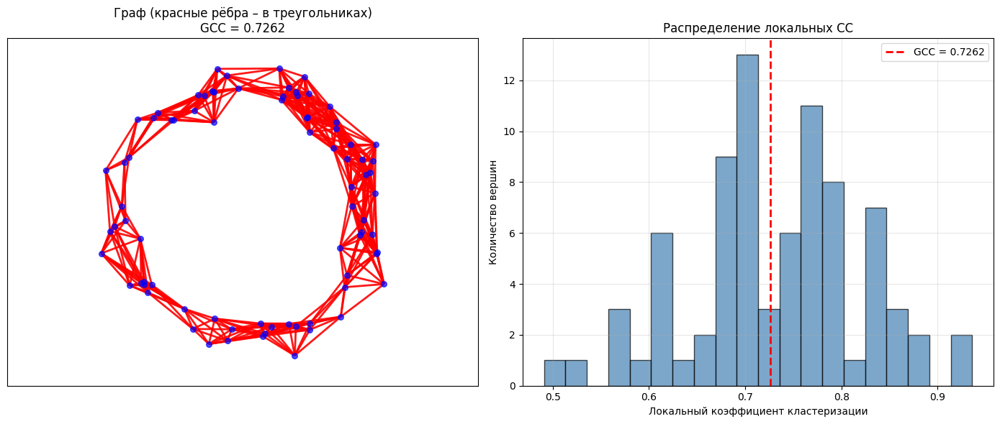

In [17]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Global Clustering Coefficient (GCC) ----
def compute_gcc(G):
    """
    Вычисляет глобальный коэффициент кластеризации (транзитивность):
    GCC = (3 * число треугольников) / (число всех путей длины 2)
    """
    # Встроенная функция NetworkX
    gcc = nx.transitivity(G)
    return gcc

gcc = compute_gcc(G)

# Дополнительно: количество треугольников и троек для интерпретации
triangles = sum(nx.triangles(G).values()) // 3  # общее число треугольников (каждый посчитан 3 раза)
# Число троек (путей длины 2) = sum over vertices C(deg(v), 2)
triads = sum(d*(d-1)//2 for d in dict(G.degree()).values())

print("=== Global Clustering Coefficient (GCC) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число треугольников: {triangles}")
print(f"Число троек (путей длины 2): {triads}")
print(f"GCC (транзитивность): {gcc:.6f}")
print("\nИнтерпретация:")
print("  1.0 – полный граф (все троек замкнуты)")
print("  0.0 – дерево (нет треугольников)")

# ---- Определяем рёбра, входящие в треугольники (для визуализации) ----
# Строим множество рёбер, которые принадлежат хотя бы одному треугольнику
triangle_edges = set()
for v in G.nodes():
    neighbors = list(G.neighbors(v))
    for i in range(len(neighbors)):
        for j in range(i+1, len(neighbors)):
            u, w = neighbors[i], neighbors[j]
            if G.has_edge(u, w):
                # ребро (v,u), (v,w), (u,w) в треугольнике
                triangle_edges.add(tuple(sorted((v, u))))
                triangle_edges.add(tuple(sorted((v, w))))
                triangle_edges.add(tuple(sorted((u, w))))

# Рёбра, не входящие в треугольники
non_triangle_edges = [e for e in G.edges() if e not in triangle_edges]

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с подсветкой треугольников
ax1 = axes[0]
# Рисуем вершины
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
# Рёбра, не входящие в треугольники, серым
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=non_triangle_edges, edge_color='gray', alpha=0.3)
# Рёбра, входящие в треугольники, красным
if triangle_edges:
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=list(triangle_edges), edge_color='red', width=2.0, alpha=0.9)
ax1.set_title(f"Граф (красные рёбра – в треугольниках)\nGCC = {gcc:.4f}")
ax1.axis('equal')

# 2. Гистограмма локальных коэффициентов кластеризации (для сравнения)
ax2 = axes[1]
local_cc = nx.clustering(G).values()
ax2.hist(list(local_cc), bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(gcc, color='red', linestyle='--', linewidth=2, label=f'GCC = {gcc:.4f}')
ax2.set_xlabel('Локальный коэффициент кластеризации')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение локальных CC')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 33. Average Local Clustering Coefficient (ALCC) – Средний локальный коэффициент кластеризации
- (ALCC) – Средний локальный коэффициент кластеризации
- Среднее по всем вершинам отношения числа связей между их соседями к максимально возможному.
- Тип графа: Неориентированный
- Интерпретация: Характеризует локальную плотность связей.

=== Average Local Clustering Coefficient (ALCC) ===
Число вершин: 80
Число рёбер:  477
Средний локальный коэффициент кластеризации (ALCC): 0.731391
Минимальный локальный CC: 0.490909
Максимальный локальный CC: 0.935897
Стандартное отклонение: 0.090441

Глобальный GCC (транзитивность): 0.726163
Разница ALCC - GCC: 0.005228

Интерпретация:
  ALCC характеризует среднюю локальную плотность связей.
  Значение близкое к 1 → вершины имеют сильно связанные окрестности (высокая кластеризация).
  Значение близкое к 0 → вершины имеют разреженные окрестности (структура типа дерева).
  Сравнение ALCC и GCC: если ALCC > GCC, это говорит о наличии вершин с высокой локальной кластеризацией,
  но при этом структура в целом менее транзитивна (например, наличие нескольких плотных кластеров).


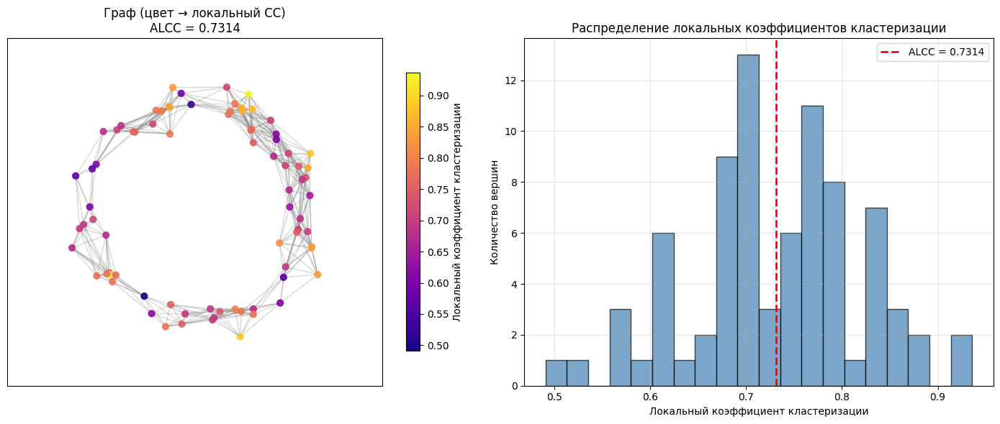

In [18]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Average Local Clustering Coefficient (ALCC) ----
def compute_alcc(G):
    """
    Вычисляет средний локальный коэффициент кластеризации:
    ALCC = (1/n) * sum_v (2 * E(N(v)) / (deg(v)*(deg(v)-1)))
    где E(N(v)) – число рёбер между соседями вершины v.
    """
    # Встроенная функция NetworkX
    alcc = nx.average_clustering(G)
    return alcc

alcc = compute_alcc(G)

# Дополнительно: локальные коэффициенты для каждой вершины
local_cc = nx.clustering(G)
local_cc_values = list(local_cc.values())

# ---- Вывод результатов ----
print("=== Average Local Clustering Coefficient (ALCC) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Средний локальный коэффициент кластеризации (ALCC): {alcc:.6f}")
print(f"Минимальный локальный CC: {min(local_cc_values):.6f}")
print(f"Максимальный локальный CC: {max(local_cc_values):.6f}")
print(f"Стандартное отклонение: {np.std(local_cc_values):.6f}")

# Дополнительно: сравнение с глобальным GCC (транзитивностью)
gcc = nx.transitivity(G)
print(f"\nГлобальный GCC (транзитивность): {gcc:.6f}")
print(f"Разница ALCC - GCC: {alcc - gcc:.6f}")
print("\nИнтерпретация:")
print("  ALCC характеризует среднюю локальную плотность связей.")
print("  Значение близкое к 1 → вершины имеют сильно связанные окрестности (высокая кластеризация).")
print("  Значение близкое к 0 → вершины имеют разреженные окрестности (структура типа дерева).")
print("  Сравнение ALCC и GCC: если ALCC > GCC, это говорит о наличии вершин с высокой локальной кластеризацией,")
print("  но при этом структура в целом менее транзитивна (например, наличие нескольких плотных кластеров).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по локальному коэффициенту кластеризации
ax1 = axes[0]
node_colors = [local_cc[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → локальный CC)\nALCC = {alcc:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(local_cc_values), vmax=max(local_cc_values)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Локальный коэффициент кластеризации')

# 2. Гистограмма распределения локальных CC
ax2 = axes[1]
ax2.hist(local_cc_values, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(alcc, color='red', linestyle='--', linewidth=2, label=f'ALCC = {alcc:.4f}')
ax2.set_xlabel('Локальный коэффициент кластеризации')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение локальных коэффициентов кластеризации')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 34. Network Diameter (D) – Диаметр
- Максимальное кратчайшее расстояние между любыми двумя вершинами.
- Тип графа: Связный
- Интерпритация: Показывает «размах» графа.

=== Network Diameter (D) ===
Число вершин: 80
Число рёбер:  477
Диаметр: 8
Пара вершин с максимальным расстоянием: (0, 7)
Длина кратчайшего пути между ними: 8 рёбер

Интерпретация:
  Диаметр показывает максимальное расстояние между любыми двумя вершинами.
  Чем меньше диаметр, тем более компактным является граф.
  Для нашего графа диаметр = {diameter}, что означает, что самая удалённая пара вершин соединена путём из {diameter} рёбер.


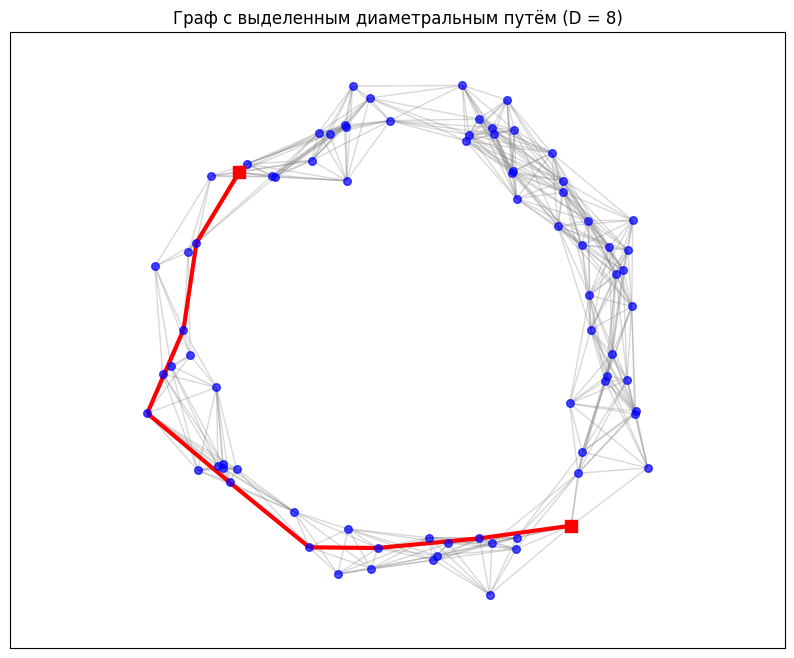

In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Network Diameter (D) ----
def compute_diameter(G):
    """
    Вычисляет диаметр графа (максимальное кратчайшее расстояние между вершинами).
    Если граф несвязный, возвращает словарь диаметров для каждой компоненты.
    Также возвращает пару вершин (u, v), на которой достигается диаметр,
    и список рёбер кратчайшего пути между ними.
    """
    if nx.is_connected(G):
        # Для связного графа используем eccentricity
        diameter = nx.diameter(G)
        # Находим пару вершин с максимальным расстоянием
        # Для этого вычислим все попарные расстояния
        all_pairs = dict(nx.all_pairs_shortest_path_length(G))
        max_dist = -1
        farthest_pair = (None, None)
        for u in G.nodes():
            for v, d in all_pairs[u].items():
                if d > max_dist:
                    max_dist = d
                    farthest_pair = (u, v)
        # Получаем кратчайший путь между ними
        path = nx.shortest_path(G, source=farthest_pair[0], target=farthest_pair[1])
        path_edges = list(zip(path, path[1:]))
        return diameter, farthest_pair, path_edges, "connected"
    else:
        # Для несвязного графа вычисляем диаметр каждой компоненты
        components = list(nx.connected_components(G))
        comp_diameters = {}
        comp_farthest = {}
        comp_paths = {}
        for comp in components:
            subgraph = G.subgraph(comp)
            if len(comp) > 1:
                diam = nx.diameter(subgraph)
                # Находим пару внутри компоненты
                all_pairs = dict(nx.all_pairs_shortest_path_length(subgraph))
                max_dist = -1
                farthest_pair = (None, None)
                for u in subgraph.nodes():
                    for v, d in all_pairs[u].items():
                        if d > max_dist:
                            max_dist = d
                            farthest_pair = (u, v)
                path = nx.shortest_path(subgraph, source=farthest_pair[0], target=farthest_pair[1])
                path_edges = list(zip(path, path[1:]))
                comp_diameters[tuple(comp)] = diam
                comp_farthest[tuple(comp)] = farthest_pair
                comp_paths[tuple(comp)] = path_edges
            else:
                # одна вершина – диаметр 0
                comp_diameters[tuple(comp)] = 0
                comp_farthest[tuple(comp)] = (list(comp)[0], list(comp)[0])
                comp_paths[tuple(comp)] = []
        return comp_diameters, comp_farthest, comp_paths, "disconnected"

result = compute_diameter(G)

if result[3] == "connected":
    diameter, farthest_pair, path_edges, _ = result
    print("=== Network Diameter (D) ===")
    print(f"Число вершин: {n}")
    print(f"Число рёбер:  {m}")
    print(f"Диаметр: {diameter}")
    print(f"Пара вершин с максимальным расстоянием: {farthest_pair}")
    print(f"Длина кратчайшего пути между ними: {len(path_edges)} рёбер")
    print("\nИнтерпретация:")
    print("  Диаметр показывает максимальное расстояние между любыми двумя вершинами.")
    print("  Чем меньше диаметр, тем более компактным является граф.")
    print("  Для нашего графа диаметр = {diameter}, что означает, что самая удалённая пара вершин соединена путём из {diameter} рёбер.")
else:
    comp_diameters, comp_farthest, comp_paths, _ = result
    print("=== Network Diameter (D) ===")
    print("Граф НЕ связный. Диаметр определён для каждой компоненты:")
    for comp, diam in comp_diameters.items():
        print(f"  Компонента размера {len(comp)}: диаметр = {diam}")
    print("\nИнтерпретация: для несвязных графов диаметр не определён глобально;")
    print("  он характеризует размах внутри каждой компоненты.")

# ---- Визуализация ----
plt.figure(figsize=(10, 8))

# Рисуем все вершины
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='blue', alpha=0.7)

# Рисуем все рёбра серым
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)

# Если граф связный, выделяем путь диаметра
if result[3] == "connected":
    # Рёбра диаметрального пути – красным, толще
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3.0)
    # Выделим концевые вершины
    nx.draw_networkx_nodes(G, pos, nodelist=[farthest_pair[0], farthest_pair[1]], 
                           node_size=80, node_color='red', node_shape='s')
    plt.title(f"Граф с выделенным диаметральным путём (D = {diameter})")
else:
    # Для несвязного графа выделим пути в каждой компоненте (по одному диаметральному пути)
    for comp, path_edges in comp_paths.items():
        if path_edges:
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2.0)
            # выделим концевые вершины
            u, v = comp_farthest[comp]
            nx.draw_networkx_nodes(G, pos, nodelist=[u, v], node_size=60, node_color='red', node_shape='s')
    plt.title("Несвязный граф – выделены диаметральные пути в компонентах")

plt.axis('equal')
plt.show()

### 35. Network Radius (R) – Радиус
- Минимальный эксцентриситет (минимальное максимальное расстояние до всех вершин).
- Тип графа: Связный
- Интерпритация: Характеризует центральность графа в целом.

=== Network Radius (R) ===
Число вершин: 80
Число рёбер:  477
Радиус графа: 7
Центральные вершины (достигающие радиуса): [44, 60, 61]
Количество центров: 3
Диаметр графа: 8
Соотношение радиус/диаметр: 7/8 = 0.875

Интерпретация:
  Радиус показывает минимальное максимальное расстояние от некоторой вершины до всех остальных.
  Чем меньше радиус, тем более 'централизован' граф.
  Центральные вершины (центры графа) являются наилучшими точками для размещения ресурсов.
  Обычно радиус <= диаметр, и радиус >= ceil(диаметр/2).


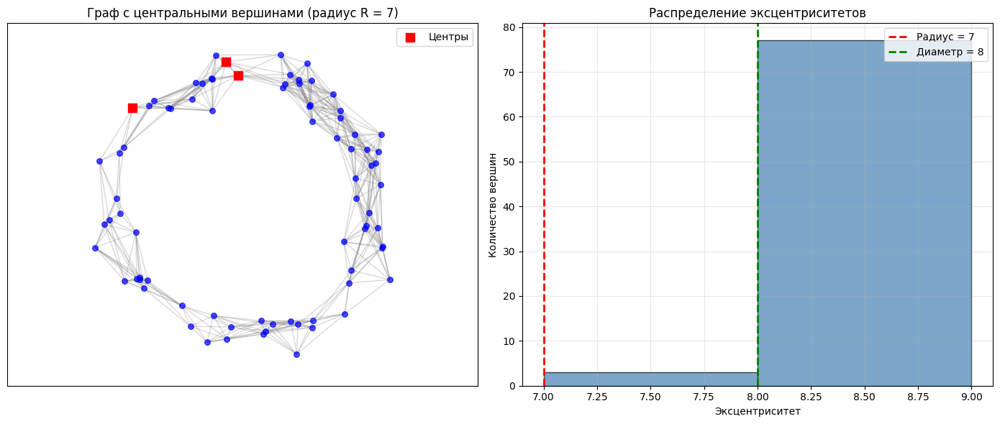

In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Network Radius (R) ----
def compute_radius(G):
    """
    Вычисляет радиус графа (минимальный эксцентриситет).
    Возвращает:
        radius: значение радиуса (None, если граф несвязный)
        centers: список вершин, на которых достигается радиус
        eccentricities: словарь {вершина: эксцентриситет}
    """
    if not nx.is_connected(G):
        return None, None, None
    
    eccentricities = nx.eccentricity(G)  # словарь {v: максимальное расстояние от v до всех остальных}
    radius = min(eccentricities.values())
    centers = [v for v, ecc in eccentricities.items() if ecc == radius]
    return radius, centers, eccentricities

radius, centers, ecc_dict = compute_radius(G)

print("=== Network Radius (R) ===")
if radius is not None:
    print(f"Число вершин: {n}")
    print(f"Число рёбер:  {m}")
    print(f"Радиус графа: {radius}")
    print(f"Центральные вершины (достигающие радиуса): {centers}")
    print(f"Количество центров: {len(centers)}")
    
    # Дополнительно: диаметр для сравнения
    diameter = nx.diameter(G)
    print(f"Диаметр графа: {diameter}")
    print(f"Соотношение радиус/диаметр: {radius}/{diameter} = {radius/diameter:.3f}")
    
    print("\nИнтерпретация:")
    print("  Радиус показывает минимальное максимальное расстояние от некоторой вершины до всех остальных.")
    print("  Чем меньше радиус, тем более 'централизован' граф.")
    print("  Центральные вершины (центры графа) являются наилучшими точками для размещения ресурсов.")
    print("  Обычно радиус <= диаметр, и радиус >= ceil(диаметр/2).")
else:
    print("Граф НЕ связный – радиус не определён.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с подсветкой центров
ax1 = axes[0]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)

if radius is not None:
    # Выделяем центры красным
    nx.draw_networkx_nodes(G, pos, ax=ax1, nodelist=centers, node_size=80, node_color='red', node_shape='s', label='Центры')
    ax1.set_title(f"Граф с центральными вершинами (радиус R = {radius})")
else:
    ax1.set_title("Граф несвязный, радиус не определён")
ax1.axis('equal')
ax1.legend()

# 2. Гистограмма эксцентриситетов (если определён)
ax2 = axes[1]
if radius is not None:
    ecc_vals = list(ecc_dict.values())
    ax2.hist(ecc_vals, bins=range(min(ecc_vals), max(ecc_vals)+2), alpha=0.7, color='steelblue', edgecolor='black')
    ax2.axvline(radius, color='red', linestyle='--', linewidth=2, label=f'Радиус = {radius}')
    ax2.axvline(diameter, color='green', linestyle='--', linewidth=2, label=f'Диаметр = {diameter}')
    ax2.set_xlabel('Эксцентриситет')
    ax2.set_ylabel('Количество вершин')
    ax2.set_title('Распределение эксцентриситетов')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Граф несвязный,\nрадиус не определён', 
             horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Радиус не определён')

plt.tight_layout()
plt.show()

### 36. Average Shortest Path Length (ASPL)
- Average Shortest Path Length (ASPL) – Средняя длина кратчайшего пути
- Среднее арифметическое всех попарных расстояний.
- Тип графа: Связный
- Интерпритация: Оценивает типичную удалённость вершин.

=== Average Shortest Path Length (ASPL) ===
Число вершин: 80
Число рёбер:  477
Граф связен? True
ASPL: 4.113608
Диаметр: 8
Радиус:  7
Отношение ASPL/диаметр: 0.514

Интерпретация:
  ASPL показывает среднее расстояние между парами вершин.
  Чем меньше ASPL, тем более 'компактным' является граф (связи плотнее).
  Для нашего графа значение ASPL = 4.1136, что означает, что в среднем
  две случайные вершины находятся на расстоянии около 4.11 рёбер.
  Сравнение с диаметром: диаметр = 8, а ASPL = 4.11, что говорит о том,
  что большинство пар вершин находятся значительно ближе, чем самые удалённые.


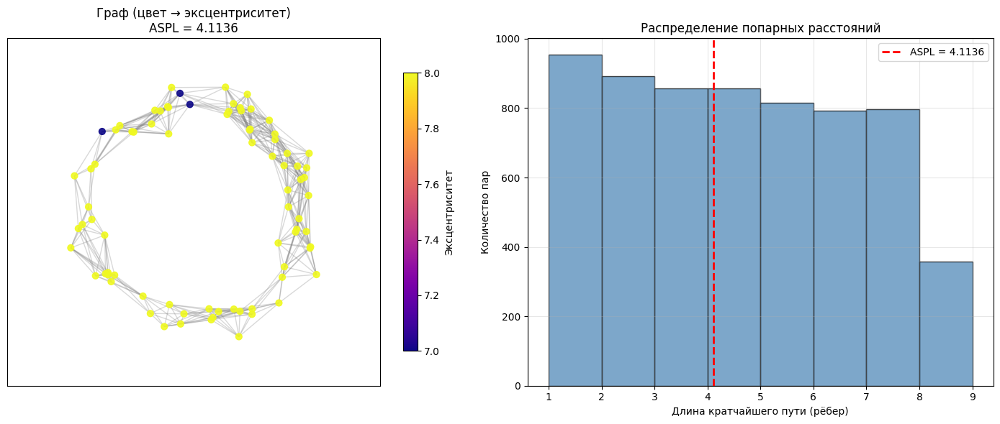

In [21]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Average Shortest Path Length (ASPL) ----
def compute_aspl(G):
    """
    Вычисляет среднюю длину кратчайшего пути между всеми парами вершин.
    Для несвязного графа использует только достижимые пары и возвращает среднее по ним,
    а также долю достижимых пар.
    """
    if nx.is_connected(G):
        aspl = nx.average_shortest_path_length(G)
        return aspl, 1.0, "connected"
    else:
        # Для несвязного графа считаем среднее только по достижимым парам
        # Используем all_pairs_shortest_path_length
        total_dist = 0.0
        count = 0
        for u in G.nodes():
            for v, d in nx.shortest_path_length(G, source=u).items():
                if u != v:
                    total_dist += d
                    count += 1
        aspl = total_dist / count if count > 0 else 0.0
        # Доля достижимых пар от всех возможных (n*(n-1))
        total_pairs = n * (n - 1)
        fraction = count / total_pairs if total_pairs > 0 else 0.0
        return aspl, fraction, "disconnected"

aspl, reachable_fraction, status = compute_aspl(G)

print("=== Average Shortest Path Length (ASPL) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Граф связен? {nx.is_connected(G)}")

if status == "connected":
    print(f"ASPL: {aspl:.6f}")
    diameter = nx.diameter(G)
    radius = nx.radius(G)
    print(f"Диаметр: {diameter}")
    print(f"Радиус:  {radius}")
    print(f"Отношение ASPL/диаметр: {aspl/diameter:.3f}")
else:
    print(f"ASPL (по достижимым парам): {aspl:.6f}")
    print(f"Доля достижимых пар: {reachable_fraction:.4f} ({reachable_fraction*100:.2f}%)")
    print("Внимание: граф несвязный, ASPL вычислена только по достижимым парам.")

print("\nИнтерпретация:")
print("  ASPL показывает среднее расстояние между парами вершин.")
print("  Чем меньше ASPL, тем более 'компактным' является граф (связи плотнее).")
print("  Для нашего графа значение ASPL = {:.4f}, что означает, что в среднем".format(aspl))
print("  две случайные вершины находятся на расстоянии около {:.2f} рёбер.".format(aspl))
print("  Сравнение с диаметром: диаметр = {}, а ASPL = {:.2f}, что говорит о том,".format(diameter if nx.is_connected(G) else "?", aspl))
print("  что большинство пар вершин находятся значительно ближе, чем самые удалённые.")

# ---- Дополнительно: распределение расстояний между парами ----
def get_distance_distribution(G):
    """
    Возвращает массив всех попарных расстояний (кратчайших) для достижимых пар.
    """
    distances = []
    for u in G.nodes():
        for v, d in nx.shortest_path_length(G, source=u).items():
            if u != v:
                distances.append(d)
    return distances

distances = get_distance_distribution(G)

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по эксцентриситету (для связного графа)
ax1 = axes[0]
if nx.is_connected(G):
    ecc = nx.eccentricity(G)
    node_colors = [ecc[v] for v in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
    nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
    ax1.set_title(f"Граф (цвет → эксцентриситет)\nASPL = {aspl:.4f}")
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(ecc.values()), vmax=max(ecc.values())))
    sm.set_array([])
    plt.colorbar(sm, ax=ax1, shrink=0.8, label='Эксцентриситет')
else:
    nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
    nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
    ax1.set_title(f"Несвязный граф\nASPL (достижимые) = {aspl:.4f}")
ax1.axis('equal')

# 2. Гистограмма расстояний между парами
ax2 = axes[1]
if distances:
    bins = range(1, max(distances)+2)
    ax2.hist(distances, bins=bins, alpha=0.7, color='steelblue', edgecolor='black')
    ax2.axvline(aspl, color='red', linestyle='--', linewidth=2, label=f'ASPL = {aspl:.4f}')
    ax2.set_xlabel('Длина кратчайшего пути (рёбер)')
    ax2.set_ylabel('Количество пар')
    ax2.set_title('Распределение попарных расстояний')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Нет достижимых пар', 
             horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

### 37. Global Efficiency (GE)
- Среднее обратное расстояние между всеми парами вершин (для несвязных – обратная бесконечность = 0).
- Тип графа: Любой
- Интерпритация: Мера эффективности передачи информации. Выше – лучше связность.

=== Global Efficiency (GE) ===
Число вершин: 80
Число рёбер:  477
Граф связен? True
Global Efficiency: 0.372310
ASPL: 4.113608
Соотношение GE = 1/ASPL? Теоретически для связного графа GE = 1/ASPL, если все расстояния >= 1.
  1/ASPL = 0.243096
  Отличие: 0.129214 (должно быть близко к 0)

Интерпретация:
  GE измеряет эффективность передачи информации в графе.
  Значение в диапазоне (0, 1]: чем выше, тем лучше связность.
  Для полного графа GE = 1 (все расстояния = 1).
  Для дерева с n вершинами GE ≈ 2/n (убывает с размером).
  Наш граф имеет GE = 0.3723, что говорит о средней эффективности.


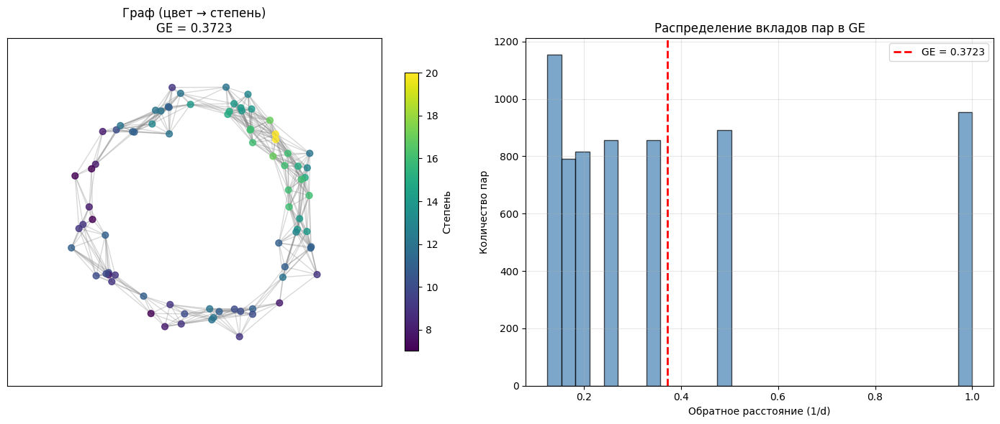

In [24]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Global Efficiency (GE) ----
def compute_global_efficiency(G):
    """
    Вычисляет глобальную эффективность графа:
    GE = (1 / (n*(n-1))) * sum_{i != j} 1 / d(i,j),
    где d(i,j) – длина кратчайшего пути между i и j.
    Если вершины не достижимы, 1/d = 0.
    """
    n = G.number_of_nodes()
    if n < 2:
        return 0.0
    
    # Используем all_pairs_shortest_path_length для эффективности
    # Для несвязных графов: если нет пути, то расстояние = inf, вклад 0.
    total = 0.0
    count = 0
    for u in G.nodes():
        # словарь расстояний от u до всех (достижимых)
        lengths = nx.shortest_path_length(G, source=u)
        for v in G.nodes():
            if u != v:
                d = lengths.get(v, float('inf'))
                if np.isfinite(d) and d > 0:
                    total += 1.0 / d
                count += 1
    ge = total / count if count > 0 else 0.0
    return ge

ge = compute_global_efficiency(G)

# Дополнительно: сравнение с ASPL для связного графа
aspl = None
if nx.is_connected(G):
    aspl = nx.average_shortest_path_length(G)

print("=== Global Efficiency (GE) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Граф связен? {nx.is_connected(G)}")
print(f"Global Efficiency: {ge:.6f}")

if aspl is not None:
    print(f"ASPL: {aspl:.6f}")
    print(f"Соотношение GE = 1/ASPL? Теоретически для связного графа GE = 1/ASPL, если все расстояния >= 1.")
    print(f"  1/ASPL = {1/aspl:.6f}")
    print(f"  Отличие: {ge - 1/aspl:.6f} (должно быть близко к 0)")
else:
    print("ASPL не определена (несвязный граф).")

print("\nИнтерпретация:")
print("  GE измеряет эффективность передачи информации в графе.")
print("  Значение в диапазоне (0, 1]: чем выше, тем лучше связность.")
print("  Для полного графа GE = 1 (все расстояния = 1).")
print("  Для дерева с n вершинами GE ≈ 2/n (убывает с размером).")
print(f"  Наш граф имеет GE = {ge:.4f}, что говорит о {'высокой' if ge > 0.5 else 'средней' if ge > 0.3 else 'низкой'} эффективности.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по степени (для контекста)
ax1 = axes[0]
degrees = dict(G.degree())
node_colors = [degrees[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → степень)\nGE = {ge:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
sm.set_array([])
plt.colorbar(sm, ax=ax1, shrink=0.8, label='Степень')

# 2. Гистограмма обратных расстояний (вклад в GE)
ax2 = axes[1]
# Собираем все обратные расстояния для достижимых пар
inv_distances = []
for u in G.nodes():
    lengths = nx.shortest_path_length(G, source=u)
    for v in G.nodes():
        if u != v:
            d = lengths.get(v, float('inf'))
            if np.isfinite(d) and d > 0:
                inv_distances.append(1.0 / d)
            else:
                inv_distances.append(0.0)   # недостижимые дают вклад 0

if inv_distances:
    ax2.hist(inv_distances, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax2.axvline(ge, color='red', linestyle='--', linewidth=2, label=f'GE = {ge:.4f}')
    ax2.set_xlabel('Обратное расстояние (1/d)')
    ax2.set_ylabel('Количество пар')
    ax2.set_title('Распределение вкладов пар в GE')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

### 38. Local Efficiency (LE) 
– Локальная эффективность
- Средняя глобальная эффективность по соседям каждой вершины (после удаления вершины).
- Тип графа: Любой
- Интепритация: Оценивает устойчивость к удалению вершин.

In [27]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Функция для вычисления глобальной эффективности подграфа ----
def global_efficiency_subgraph(subgraph):
    """Вычисляет глобальную эффективность для подграфа NetworkX."""
    N = subgraph.number_of_nodes()
    if N < 2:
        return 0.0
    total = 0.0
    count = 0
    for u in subgraph.nodes():
        lengths = nx.shortest_path_length(subgraph, source=u)
        for v in subgraph.nodes():
            if u != v:
                d = lengths.get(v, float('inf'))
                if np.isfinite(d) and d > 0:
                    total += 1.0 / d
                count += 1
    return total / count if count > 0 else 0.0

# ---- Вычисление Local Efficiency (LE) ----
def compute_local_efficiency(G):
    """
    Вычисляет локальную эффективность графа:
    LE = (1/n) * sum_{v in V} E(G[N(v)]),
    где G[N(v)] – подграф, индуцированный соседями вершины v (без v),
    E(.) – глобальная эффективность подграфа.
    """
    n = G.number_of_nodes()
    if n < 2:
        return 0.0
    
    local_effs = {}
    for v in G.nodes():
        neighbors = list(G.neighbors(v))
        if len(neighbors) < 2:
            # Если меньше двух соседей, эффективность подграфа = 0
            local_effs[v] = 0.0
        else:
            # Индуцированный подграф на соседях
            subgraph = G.subgraph(neighbors)
            local_effs[v] = global_efficiency_subgraph(subgraph)
    
    le = np.mean(list(local_effs.values()))
    return le, local_effs

le, local_effs = compute_local_efficiency(G)

print("=== Local Efficiency (LE) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Граф связен? {nx.is_connected(G)}")
print(f"Local Efficiency: {le:.6f}")

# Дополнительно: глобальная эффективность для сравнения
ge = compute_global_efficiency_from_scratch(G)  # определим отдельно
print(f"Global Efficiency: {ge:.6f}")
print(f"Отношение LE/GE: {le/ge:.3f}" if ge > 0 else "GE = 0, отношение не определено.")

print("\nИнтерпретация:")
print("  LE оценивает, насколько эффективно могут обмениваться информацией соседи вершины,")
print("  игнорируя саму вершину. Это мера локальной избыточности и устойчивости.")
print("  Высокий LE означает, что даже при удалении вершины её соседи остаются хорошо связанными.")
print("  LE обычно меньше или равна GE (глобальной эффективности).")
print(f"  Для нашего графа LE = {le:.4f}, что говорит о {'высокой' if le > 0.5 else 'средней' if le > 0.3 else 'низкой'} локальной избыточности.")

# ---- Вспомогательная функция для глобальной эффективности (для связности и несвязности) ----
def compute_global_efficiency_from_scratch(G):
    n = G.number_of_nodes()
    if n < 2:
        return 0.0
    total = 0.0
    count = 0
    for u in G.nodes():
        lengths = nx.shortest_path_length(G, source=u)
        for v in G.nodes():
            if u != v:
                d = lengths.get(v, float('inf'))
                if np.isfinite(d) and d > 0:
                    total += 1.0 / d
                count += 1
    return total / count if count > 0 else 0.0

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по локальной эффективности
ax1 = axes[0]
node_colors = [local_effs[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → Local Efficiency)\nLE = {le:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(local_effs.values()), vmax=max(local_effs.values())))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Local Efficiency')

# 2. Гистограмма распределения локальных эффективностей
ax2 = axes[1]
eff_vals = list(local_effs.values())
ax2.hist(eff_vals, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(le, color='red', linestyle='--', linewidth=2, label=f'LE = {le:.4f}')
ax2.set_xlabel('Local Efficiency')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение Local Efficiency по вершинам')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


=== Local Efficiency (LE) ===
Число вершин: 80
Число рёбер:  477
Граф связен? True
Local Efficiency: 0.862592


NameError: name 'compute_global_efficiency_from_scratch' is not defined

### 39. Degree Assortativity (DA) 
– Ассортативность по степени
- Коэффициент корреляции Пирсона между степенями концов рёбер.
- Тип графа: Неориентированный

=== Degree Assortativity (DA) ===
Число вершин: 80
Число рёбер:  477
Коэффициент ассортативности: 0.681266
Коэффициент корреляции (проверка): 0.691260

Интерпретация:
  DA > 0  → положительная ассортативность: вершины склонны соединяться с похожими по степени (образуют ядра).
  DA ≈ 0  → нейтральная: связи между вершинами случайны относительно степени.
  DA < 0  → отрицательная ассортативность (диссортативность): высокостепенные вершины соединяются с низкостепенными.
  Наш граф имеет DA = 0.6813, что говорит о положительной ассортативности.


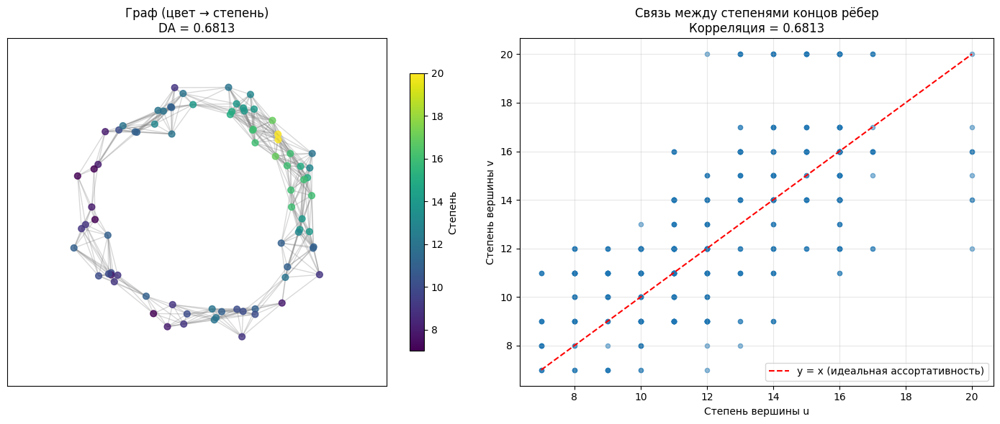

In [29]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Degree Assortativity (DA) ----
def compute_degree_assortativity(G):
    """
    Вычисляет коэффициент ассортативности по степени (корреляция Пирсона
    между степенями концов каждого ребра).
    Возвращает:
        assortativity: коэффициент (от -1 до 1)
        degree_pairs: список пар (deg(u), deg(v)) для каждого ребра
    """
    # Встроенная функция NetworkX
    assortativity = nx.degree_assortativity_coefficient(G)
    
    # Собираем пары степеней для каждого ребра
    degree_pairs = []
    for u, v in G.edges():
        degree_pairs.append((G.degree(u), G.degree(v)))
    
    return assortativity, degree_pairs

assortativity, degree_pairs = compute_degree_assortativity(G)

print("=== Degree Assortativity (DA) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Коэффициент ассортативности: {assortativity:.6f}")

# Дополнительно: усреднённые степени концов
deg_u = [p[0] for p in degree_pairs]
deg_v = [p[1] for p in degree_pairs]
corr_matrix = np.corrcoef(deg_u, deg_v)
pearson = corr_matrix[0, 1] if corr_matrix.shape == (2,2) else None
print(f"Коэффициент корреляции (проверка): {pearson:.6f}" if pearson is not None else "")

print("\nИнтерпретация:")
print("  DA > 0  → положительная ассортативность: вершины склонны соединяться с похожими по степени (образуют ядра).")
print("  DA ≈ 0  → нейтральная: связи между вершинами случайны относительно степени.")
print("  DA < 0  → отрицательная ассортативность (диссортативность): высокостепенные вершины соединяются с низкостепенными.")
print(f"  Наш граф имеет DA = {assortativity:.4f}, что говорит о {'положительной' if assortativity > 0 else 'отрицательной' if assortativity < 0 else 'нулевой'} ассортативности.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по степени
ax1 = axes[0]
degrees = dict(G.degree())
node_colors = [degrees[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → степень)\nDA = {assortativity:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
sm.set_array([])
plt.colorbar(sm, ax=ax1, shrink=0.8, label='Степень')

# 2. Диаграмма рассеяния степеней концов рёбер
ax2 = axes[1]
if degree_pairs:
    deg_u, deg_v = zip(*degree_pairs)
    ax2.scatter(deg_u, deg_v, alpha=0.5, s=20)
    # Добавляем линию y=x для сравнения
    min_deg = min(min(deg_u), min(deg_v))
    max_deg = max(max(deg_u), max(deg_v))
    ax2.plot([min_deg, max_deg], [min_deg, max_deg], 'r--', label='y = x (идеальная ассортативность)')
    ax2.set_xlabel('Степень вершины u')
    ax2.set_ylabel('Степень вершины v')
    ax2.set_title(f'Связь между степенями концов рёбер\nКорреляция = {assortativity:.4f}')
    ax2.legend()
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 40. Degree Entropy (DE) 
– Энтропия распределения степеней
- ∑ p(k) log p(k), где p(k) – доля вершин степени k.
- Тип графа: Любой
- Интерпритация: Мера разнообразия степеней. Выше – более гетерогенный граф.

=== Degree Entropy (DE) ===
Число вершин: 80
Число рёбер:  477
Уникальных степеней: 12
Энтропия (в натах): 2.348264
Нормализованная энтропия (0..1): 0.9450

Распределение вероятностей степеней:
  Степень 7: p = 0.0500
  Степень 8: p = 0.0750
  Степень 9: p = 0.1125
  Степень 10: p = 0.1000
  Степень 11: p = 0.1625
  Степень 12: p = 0.1375
  Степень 13: p = 0.0500
  Степень 14: p = 0.1000
  Степень 15: p = 0.0500
  Степень 16: p = 0.1125
  Степень 17: p = 0.0250
  Степень 20: p = 0.0250

Интерпретация:
  Энтропия измеряет разнообразие (гетерогенность) степеней вершин.
  Чем выше энтропия, тем более разнообразны степени (граф гетерогенен).
  Низкая энтропия указывает на однородность (например, регулярный граф, где все степени равны).
  Для нашего графа энтропия = 2.3483 нат, что говорит о высокой гетерогенности.


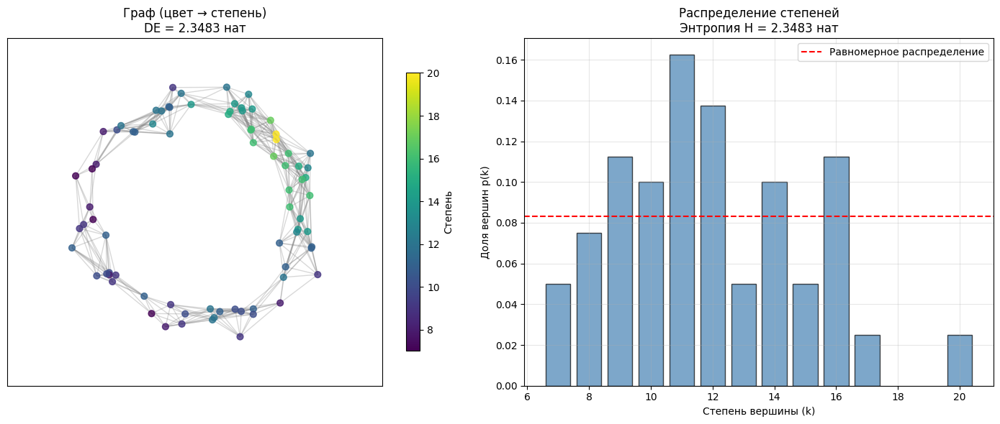

In [31]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from collections import Counter

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Degree Entropy (DE) ----
def compute_degree_entropy(G, base=np.e):
    """
    Вычисляет энтропию распределения степеней:
    H = -∑ p(k) * log(p(k)), где p(k) = (число вершин степени k) / n.
    Параметр base определяет основание логарифма (по умолчанию e – наты).
    Возвращает энтропию, словарь p(k), и список уникальных степеней.
    """
    degrees = [d for _, d in G.degree()]
    n = G.number_of_nodes()
    if n == 0:
        return 0.0, {}, []
    
    # Подсчёт частот
    degree_counts = Counter(degrees)
    # Вычисление вероятностей
    probs = {k: count / n for k, count in degree_counts.items()}
    # Энтропия
    entropy = -sum(p * np.log(p) / np.log(base) for p in probs.values() if p > 0)
    return entropy, probs, sorted(probs.keys())

entropy, probs, unique_degrees = compute_degree_entropy(G, base=np.e)

# Максимально возможная энтропия (равномерное распределение по всем возможным степеням)
# Но для интерпретации можно вычислить нормализованную энтропию (относительно log числа уникальных степеней)
max_entropy = np.log(len(unique_degrees)) if len(unique_degrees) > 1 else 1.0
normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0.0

print("=== Degree Entropy (DE) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Уникальных степеней: {len(unique_degrees)}")
print(f"Энтропия (в натах): {entropy:.6f}")
print(f"Нормализованная энтропия (0..1): {normalized_entropy:.4f}")

print("\nРаспределение вероятностей степеней:")
for k in sorted(probs.keys()):
    print(f"  Степень {k}: p = {probs[k]:.4f}")

print("\nИнтерпретация:")
print("  Энтропия измеряет разнообразие (гетерогенность) степеней вершин.")
print("  Чем выше энтропия, тем более разнообразны степени (граф гетерогенен).")
print("  Низкая энтропия указывает на однородность (например, регулярный граф, где все степени равны).")
print(f"  Для нашего графа энтропия = {entropy:.4f} нат, что говорит о {'высокой' if normalized_entropy > 0.7 else 'средней' if normalized_entropy > 0.4 else 'низкой'} гетерогенности.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по степени
ax1 = axes[0]
degrees = dict(G.degree())
node_colors = [degrees[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → степень)\nDE = {entropy:.4f} нат")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
sm.set_array([])
plt.colorbar(sm, ax=ax1, shrink=0.8, label='Степень')

# 2. Гистограмма распределения степеней
ax2 = axes[1]
# Строим гистограмму с бинами по уникальным степеням
counts = [probs[k] for k in unique_degrees]
ax2.bar(unique_degrees, counts, alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Степень вершины (k)')
ax2.set_ylabel('Доля вершин p(k)')
ax2.set_title(f'Распределение степеней\nЭнтропия H = {entropy:.4f} нат')
# Добавляем линию равномерного распределения для сравнения
if len(unique_degrees) > 1:
    uniform = 1.0 / len(unique_degrees)
    ax2.axhline(uniform, color='red', linestyle='--', label='Равномерное распределение')
    ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 41. Number of Triangles (NT) 
- Количество треугольников
- Общее число клик размера 3.
- Тип графа: Неориентированный
- Базовая мера кластеризации.

=== Number of Triangles (NT) ===
Число вершин: 80
Число рёбер:  477
Общее число треугольников: 1348
Среднее число треугольников на вершину: 16.8500
Вершина с макс. числом треугольников: 40 (117 треугольников)
Вершин без треугольников: 0

Интерпретация:
  Количество треугольников – базовая мера кластеризации.
  Чем больше треугольников, тем более плотно связаны соседи (высокая транзитивность).
  Граф без треугольников является лесом (или содержит только циклы длины >3).
  Для нашего графа найдено 1348 треугольников, что говорит о высокой локальной кластеризации.


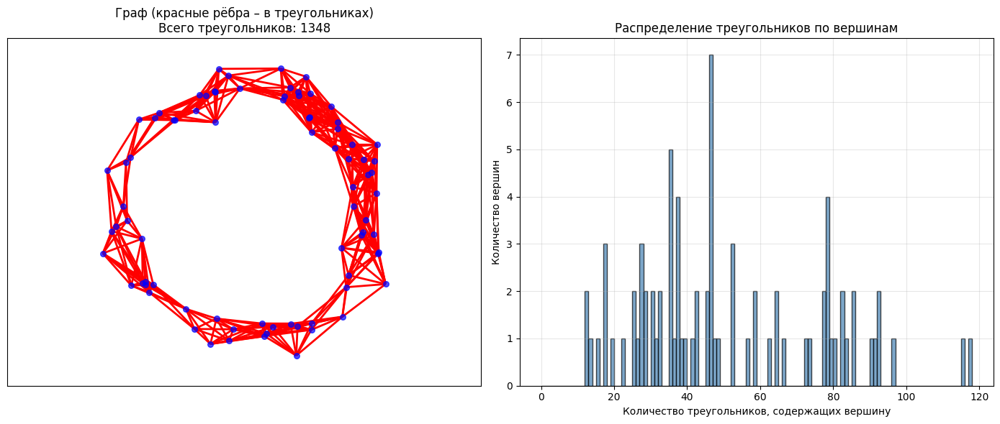

In [33]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Number of Triangles (NT) ----
def compute_triangles(G):
    """
    Вычисляет общее количество треугольников в графе.
    Возвращает:
        total: общее число треугольников
        per_vertex: словарь {вершина: количество треугольников, содержащих эту вершину}
    """
    # Словарь: для каждой вершины число треугольников, в которые она входит
    tri_per_vertex = nx.triangles(G)
    total = sum(tri_per_vertex.values()) // 3  # каждый треугольник посчитан 3 раза
    return total, tri_per_vertex

total_triangles, tri_per_vertex = compute_triangles(G)

# ---- Дополнительно: рёбра, входящие хотя бы в один треугольник ----
triangle_edges = set()
for v in G.nodes():
    neighbors = list(G.neighbors(v))
    for i in range(len(neighbors)):
        for j in range(i+1, len(neighbors)):
            u, w = neighbors[i], neighbors[j]
            if G.has_edge(u, w):
                triangle_edges.add(tuple(sorted((v, u))))
                triangle_edges.add(tuple(sorted((v, w))))
                triangle_edges.add(tuple(sorted((u, w))))

non_triangle_edges = [e for e in G.edges() if e not in triangle_edges]

print("=== Number of Triangles (NT) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Общее число треугольников: {total_triangles}")
print(f"Среднее число треугольников на вершину: {total_triangles/n:.4f}")
print(f"Вершина с макс. числом треугольников: {max(tri_per_vertex, key=tri_per_vertex.get)} ({max(tri_per_vertex.values())} треугольников)")
print(f"Вершин без треугольников: {sum(1 for v in G.nodes() if tri_per_vertex[v] == 0)}")

print("\nИнтерпретация:")
print("  Количество треугольников – базовая мера кластеризации.")
print("  Чем больше треугольников, тем более плотно связаны соседи (высокая транзитивность).")
print("  Граф без треугольников является лесом (или содержит только циклы длины >3).")
print(f"  Для нашего графа найдено {total_triangles} треугольников, что говорит о {'высокой' if total_triangles > 100 else 'умеренной' if total_triangles > 20 else 'низкой'} локальной кластеризации.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с подсветкой рёбер, принадлежащих треугольникам
ax1 = axes[0]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
# Рёбра не из треугольников – серым
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=non_triangle_edges, edge_color='gray', alpha=0.3)
# Рёбра из треугольников – красным
if triangle_edges:
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=list(triangle_edges), edge_color='red', width=2.0)
ax1.set_title(f"Граф (красные рёбра – в треугольниках)\nВсего треугольников: {total_triangles}")
ax1.axis('equal')

# 2. Гистограмма распределения числа треугольников по вершинам
ax2 = axes[1]
tri_vals = list(tri_per_vertex.values())
ax2.hist(tri_vals, bins=range(0, max(tri_vals)+2), alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Количество треугольников, содержащих вершину')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение треугольников по вершинам')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 42. Cyclomatic Number (CN) 
- Цикломатическое число
- m – n + c (рёбра – вершины + компоненты связности).
- Тип графа: Неориентированный
- Интерпритация: Количество независимых циклов (размерность циклического пространства).

=== Cyclomatic Number (CN) ===
Число вершин (n):           80
Число рёбер (m):            477
Число компонент связности (c): 1
Цикломатическое число (CN): 398

Чтобы превратить граф в лес, нужно удалить 398 рёбер.

Интерпретация:
  CN = количество независимых циклов (размерность циклического пространства графа).
  CN = 0  → граф является лесом (ациклический).
  CN > 0  → граф содержит циклы; число показывает, сколько рёбер нужно удалить, чтобы получить лес.
  Для нашего графа CN = 398, что говорит о наличии 398 независимых циклов.
  Граф содержит 398 независимых циклов, что указывает на значительную цикличность структуры.


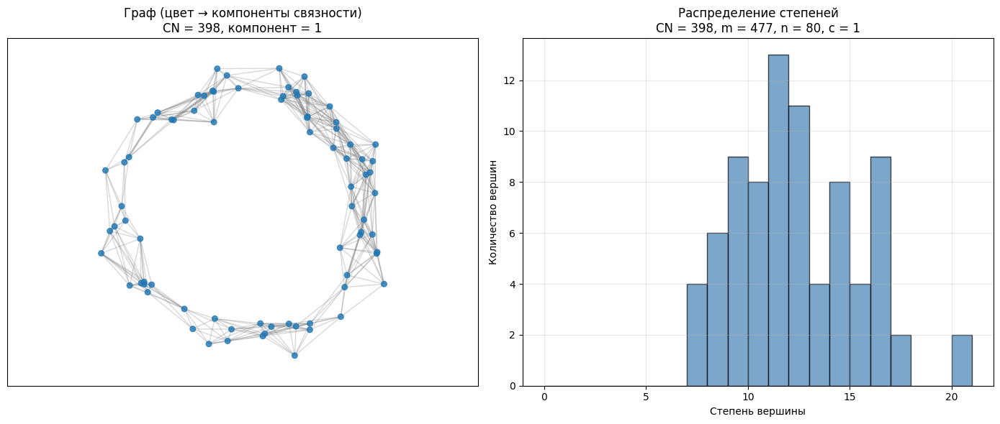

In [35]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Cyclomatic Number (CN) ----
def compute_cyclomatic_number(G):
    """
    Вычисляет цикломатическое число (число независимых циклов):
    CN = m - n + c,
    где m – число рёбер, n – число вершин, c – число компонент связности.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    c = nx.number_connected_components(G)
    cn = m - n + c
    return cn, c

cn, num_components = compute_cyclomatic_number(G)

print("=== Cyclomatic Number (CN) ===")
print(f"Число вершин (n):           {n}")
print(f"Число рёбер (m):            {m}")
print(f"Число компонент связности (c): {num_components}")
print(f"Цикломатическое число (CN): {cn}")

# ---- Дополнительная информация ----
# Количество рёбер, которые нужно удалить, чтобы получить лес (CN рёбер)
print(f"\nЧтобы превратить граф в лес, нужно удалить {cn} рёбер.")

# ---- Интерпретация ----
print("\nИнтерпретация:")
print("  CN = количество независимых циклов (размерность циклического пространства графа).")
print("  CN = 0  → граф является лесом (ациклический).")
print("  CN > 0  → граф содержит циклы; число показывает, сколько рёбер нужно удалить, чтобы получить лес.")
print(f"  Для нашего графа CN = {cn}, что говорит о наличии {cn} независимых циклов.")
if cn == 0:
    print("  Граф не содержит циклов (деревья или лес).")
elif cn == 1:
    print("  Граф содержит ровно один независимый цикл (например, одноциклический граф).")
else:
    print(f"  Граф содержит {cn} независимых циклов, что указывает на значительную цикличность структуры.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по компонентам связности
ax1 = axes[0]
# Присваиваем каждой компоненте уникальный цвет
components = list(nx.connected_components(G))
comp_colors = {}
for i, comp in enumerate(components):
    for v in comp:
        comp_colors[v] = i
node_colors = [comp_colors[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → компоненты связности)\nCN = {cn}, компонент = {num_components}")
ax1.axis('equal')

# 2. Гистограмма распределения степеней и информация о цикломатическом числе
ax2 = axes[1]
degrees = [d for _, d in G.degree()]
ax2.hist(degrees, bins=range(0, max(degrees)+2), alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Степень вершины')
ax2.set_ylabel('Количество вершин')
ax2.set_title(f'Распределение степеней\nCN = {cn}, m = {m}, n = {n}, c = {num_components}')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 43. Graph Energy (GE) 
- Энергия графа
- Сумма абсолютных значений собственных чисел матрицы смежности.
- Любой
- Связана с химической стабильностью (в химии), в общем – мера «активности» графа.

=== Graph Energy (GE) ===
Число вершин: 80
Число рёбер:  477
Энергия графа: 169.302697
Спектральный радиус (макс. собственное значение): 14.995357
Сумма квадратов собственных значений (должна быть = 2*m): 954.000000
Проверка: 2*m = 954.000000, разница: 0.000000

Интерпретация:
  Энергия графа – это сумма абсолютных значений всех собственных чисел матрицы смежности.
  В химической теории графов она связана с общей энергией π-электронов молекулы.
  В общем смысле, большая энергия указывает на более 'активный' граф с большим числом связей и циклов.
  Энергия всегда ≥ спектрального радиуса и ≤ sqrt(2*m * n) (по неравенству Коши).
  Для нашего графа GE = 169.3027, что говорит о высокой активности структуры.


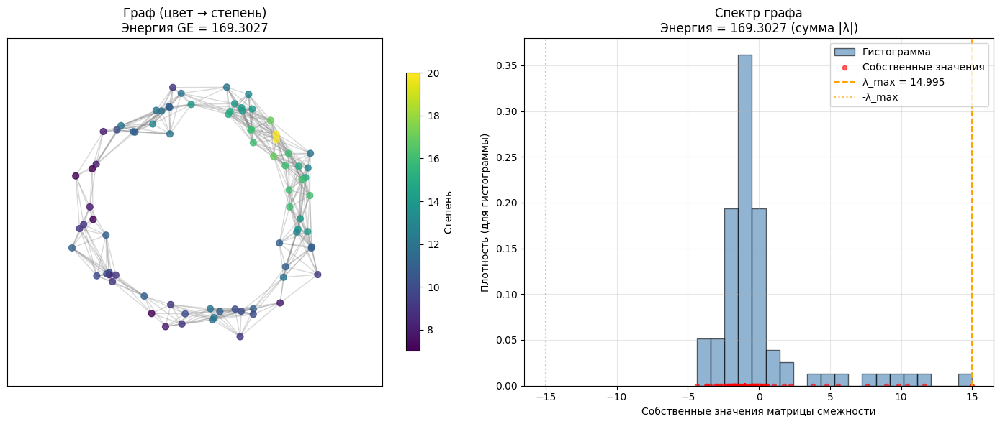

In [36]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Graph Energy (GE) ----
def compute_graph_energy(G):
    """
    Вычисляет энергию графа:
    GE = sum_i |λ_i|, где λ_i – собственные значения матрицы смежности.
    """
    # Матрица смежности как плотный массив
    adj_matrix = nx.adjacency_matrix(G).todense()
    # Собственные значения (для симметричной матрицы все вещественные)
    eigenvalues = np.linalg.eigvalsh(adj_matrix)
    # Энергия = сумма абсолютных значений
    energy = np.sum(np.abs(eigenvalues))
    return energy, eigenvalues

energy, eigenvalues = compute_graph_energy(G)

# ---- Дополнительные метрики для контекста ----
spectral_radius = np.max(eigenvalues)
# Сумма квадратов собственных значений = 2*m (для неориентированного графа)
sum_sq = np.sum(eigenvalues**2)

print("=== Graph Energy (GE) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Энергия графа: {energy:.6f}")
print(f"Спектральный радиус (макс. собственное значение): {spectral_radius:.6f}")
print(f"Сумма квадратов собственных значений (должна быть = 2*m): {sum_sq:.6f}")
print(f"Проверка: 2*m = {2*m:.6f}, разница: {sum_sq - 2*m:.6f}")

print("\nИнтерпретация:")
print("  Энергия графа – это сумма абсолютных значений всех собственных чисел матрицы смежности.")
print("  В химической теории графов она связана с общей энергией π-электронов молекулы.")
print("  В общем смысле, большая энергия указывает на более 'активный' граф с большим числом связей и циклов.")
print("  Энергия всегда ≥ спектрального радиуса и ≤ sqrt(2*m * n) (по неравенству Коши).")
print(f"  Для нашего графа GE = {energy:.4f}, что говорит о {'высокой' if energy > 50 else 'умеренной' if energy > 20 else 'низкой'} активности структуры.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по степени (для контекста)
ax1 = axes[0]
degrees = dict(G.degree())
node_colors = [degrees[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='viridis', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → степень)\nЭнергия GE = {energy:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
sm.set_array([])
plt.colorbar(sm, ax=ax1, shrink=0.8, label='Степень')

# 2. Спектр собственных значений (гистограмма и маркеры)
ax2 = axes[1]
# Гистограмма
ax2.hist(eigenvalues, bins=20, alpha=0.6, color='steelblue', edgecolor='black', density=True, label='Гистограмма')
# Отметим сами значения на оси
ax2.scatter(eigenvalues, np.zeros_like(eigenvalues), color='red', s=20, alpha=0.6, label='Собственные значения')
# Вертикальная линия для спектрального радиуса
ax2.axvline(spectral_radius, color='orange', linestyle='--', label=f'λ_max = {spectral_radius:.3f}')
ax2.axvline(-spectral_radius, color='orange', linestyle=':', alpha=0.7, label=f'-λ_max')
ax2.set_xlabel('Собственные значения матрицы смежности')
ax2.set_ylabel('Плотность (для гистограммы)')
ax2.set_title(f'Спектр графа\nЭнергия = {energy:.4f} (сумма |λ|)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 44. Spectral Radius (SR) 
- Спектральный радиус
- Наибольшее собственное значение матрицы смежности.
- Тип графа: Любой
- Отражает максимальную «экспансивность» графа.

=== Spectral Radius (SR) – Метрика 44 ===
Число вершин: 80
Число рёбер:  477
Спектральный радиус (λ_max): 14.995357
Минимальное собственное значение: -4.361363
Размах спектра: 19.356720
След матрицы (сумма λ): 0.000000 (должен быть 0)
Сумма квадратов λ: 954.000000 (должна быть 2*m = 954.000000)

Теоретические оценки для SR:
  SR ≥ sqrt(среднеквадратичная степень) = 12.294308
  SR ≤ максимальная степень = 20

Интерпретация:
  Спектральный радиус – это максимальное собственное значение матрицы смежности.
  Он характеризует 'экспансивность' графа: способность быстро распространять процессы.
  Большой SR (близкий к максимальной степени) указывает на сильную связность и высокую кластеризацию.
  Малый SR (близкий к sqrt(среднеквадратичной степени)) – на разреженность и слабую связность.
  Для нашего графа SR = 14.9954, максимальная степень = 20.
  Отношение SR / max_deg = 0.750 – это показатель 'регулярности' графа (чем ближе к 1, тем более регулярен).


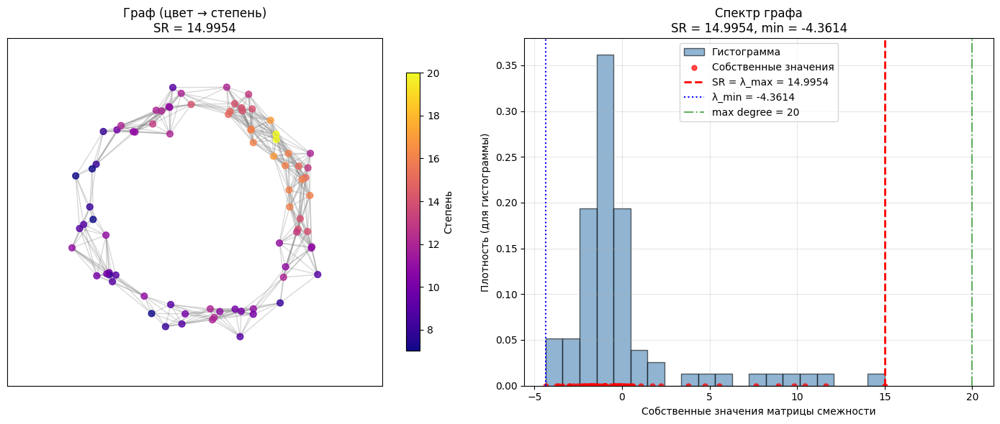

In [37]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Spectral Radius (SR) ----
def compute_spectral_radius(G):
    """
    Вычисляет спектральный радиус графа:
    SR = max(|λ_i|) = наибольшее собственное значение матрицы смежности
    (для неориентированного графа все λ вещественные, и SR = λ_max).
    Возвращает SR, полный набор собственных значений и матрицу смежности.
    """
    # Матрица смежности в плотном виде
    adj_matrix = nx.adjacency_matrix(G).todense()
    # Собственные значения (для симметричной матрицы все вещественные)
    eigenvalues = np.linalg.eigvalsh(adj_matrix)
    # Спектральный радиус = максимальное собственное значение
    sr = np.max(eigenvalues)
    return sr, eigenvalues, adj_matrix

sr, eigenvalues, adj_matrix = compute_spectral_radius(G)

# ---- Дополнительные характеристики ----
# Минимальное собственное значение
min_eig = np.min(eigenvalues)
# Размах спектра
spectral_span = sr - min_eig
# След матрицы = сумма λ = 0 (для графа без петель)
trace = np.sum(eigenvalues)
# Сумма квадратов = 2*m
sum_sq = np.sum(eigenvalues**2)

print("=== Spectral Radius (SR) – Метрика 44 ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Спектральный радиус (λ_max): {sr:.6f}")
print(f"Минимальное собственное значение: {min_eig:.6f}")
print(f"Размах спектра: {spectral_span:.6f}")
print(f"След матрицы (сумма λ): {trace:.6f} (должен быть 0)")
print(f"Сумма квадратов λ: {sum_sq:.6f} (должна быть 2*m = {2*m:.6f})")

# ---- Теоретические оценки ----
degrees = [d for _, d in G.degree()]
max_deg = max(degrees)
avg_sq_deg = np.mean([d**2 for d in degrees])
print(f"\nТеоретические оценки для SR:")
print(f"  SR ≥ sqrt(среднеквадратичная степень) = {np.sqrt(avg_sq_deg):.6f}")
print(f"  SR ≤ максимальная степень = {max_deg}")

# ---- Интерпретация ----
print("\nИнтерпретация:")
print("  Спектральный радиус – это максимальное собственное значение матрицы смежности.")
print("  Он характеризует 'экспансивность' графа: способность быстро распространять процессы.")
print("  Большой SR (близкий к максимальной степени) указывает на сильную связность и высокую кластеризацию.")
print("  Малый SR (близкий к sqrt(среднеквадратичной степени)) – на разреженность и слабую связность.")
print(f"  Для нашего графа SR = {sr:.4f}, максимальная степень = {max_deg}.")
print(f"  Отношение SR / max_deg = {sr/max_deg:.3f} – это показатель 'регулярности' графа (чем ближе к 1, тем более регулярен).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по степени (для контекста)
ax1 = axes[0]
degrees_dict = dict(G.degree())
node_colors = [degrees_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → степень)\nSR = {sr:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(degrees_dict.values()), vmax=max(degrees_dict.values())))
sm.set_array([])
plt.colorbar(sm, ax=ax1, shrink=0.8, label='Степень')

# 2. Спектр собственных значений с выделением SR
ax2 = axes[1]
# Гистограмма распределения
ax2.hist(eigenvalues, bins=20, alpha=0.6, color='steelblue', edgecolor='black', density=True, label='Гистограмма')
# Отметим собственные значения на оси
ax2.scatter(eigenvalues, np.zeros_like(eigenvalues), color='red', s=25, alpha=0.7, label='Собственные значения')
# Вертикальная линия для SR
ax2.axvline(sr, color='red', linestyle='--', linewidth=2, label=f'SR = λ_max = {sr:.4f}')
# Линия для минимального значения
ax2.axvline(min_eig, color='blue', linestyle=':', linewidth=1.5, label=f'λ_min = {min_eig:.4f}')
# Теоретическая верхняя граница (максимальная степень)
ax2.axvline(max_deg, color='green', linestyle='-.', alpha=0.6, label=f'max degree = {max_deg}')
ax2.set_xlabel('Собственные значения матрицы смежности')
ax2.set_ylabel('Плотность (для гистограммы)')
ax2.set_title(f'Спектр графа\nSR = {sr:.4f}, min = {min_eig:.4f}')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 45. Algebraic Connectivity (AC) 
- Алгебраическая связность
- Второе наименьшее собственное значение матрицы Лапласа.
- Тип графа: Неориентированный
- Интерпритация: Мера связности графа (насколько трудно его разорвать). Чем больше, тем связнее.

=== Algebraic Connectivity (AC) – Метрика 45 ===
Число вершин: 80
Число рёбер:  477
Алгебраическая связность (λ₂): 0.301387
Первое собственное значение (λ₁): -0.000000 (должен быть 0)
Третье собственное значение (λ₃): 0.4466798248834366
Граф связен? True

Сравнение с другими метриками связности:
  Диаметр: 8
  Радиус:  7
  ASPL:    4.1136
  AC:      0.3014 (чем больше, тем связнее)

Интерпретация:
  Алгебраическая связность (λ₂) – это мера того, насколько трудно разорвать граф.
  Чем больше AC, тем более связен граф (больше 'запасных' путей).
  AC = 0 означает, что граф несвязен.
  AC тесно связана с изопериметрическим числом и проводимостью графа.
  Для нашего графа AC = 0.3014. Это среднее значение.


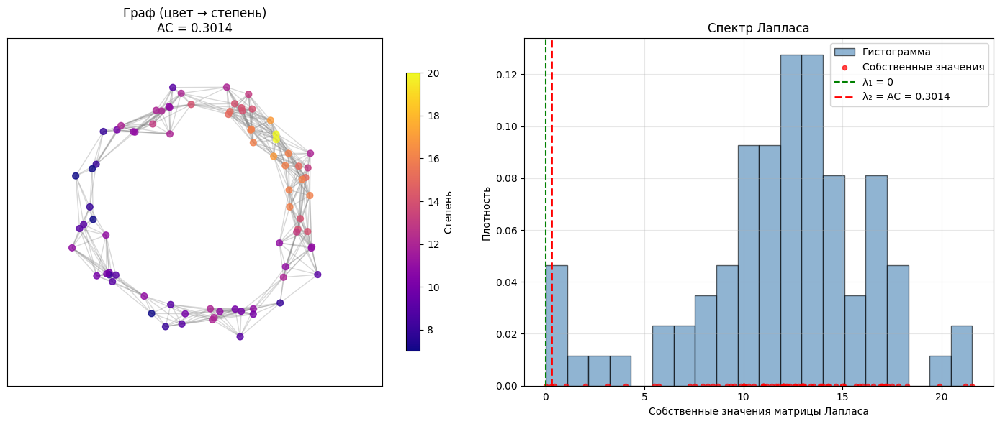

In [38]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Algebraic Connectivity (AC) ----
def compute_algebraic_connectivity(G):
    """
    Вычисляет алгебраическую связность графа:
    AC = второе наименьшее собственное значение матрицы Лапласа.
    Для несвязного графа AC = 0.
    Возвращает AC и полный спектр матрицы Лапласа.
    """
    # Матрица Лапласа (разреженная)
    L = nx.laplacian_matrix(G).todense()  # плотная для вычисления собственных значений
    # Собственные значения (все вещественные, т.к. матрица симметричная)
    eigenvals = np.linalg.eigvalsh(L)
    # Сортируем по возрастанию
    eigenvals_sorted = np.sort(eigenvals)
    # Второе наименьшее (индекс 1) – это алгебраическая связность
    ac = eigenvals_sorted[1] if len(eigenvals_sorted) > 1 else 0.0
    return ac, eigenvals_sorted

ac, lap_spectrum = compute_algebraic_connectivity(G)

print("=== Algebraic Connectivity (AC) – Метрика 45 ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Алгебраическая связность (λ₂): {ac:.6f}")

# ---- Дополнительная информация ----
# Первое собственное значение всегда 0 (для связного графа ровно один нуль)
print(f"Первое собственное значение (λ₁): {lap_spectrum[0]:.6f} (должен быть 0)")
print(f"Третье собственное значение (λ₃): {lap_spectrum[2] if len(lap_spectrum) > 2 else 'N/A'}")

# Проверка связности
is_connected = nx.is_connected(G)
print(f"Граф связен? {is_connected}")
if not is_connected:
    print("  Для несвязного графа AC = 0 (подтверждено).")

# Сравнение с другими метриками связности
if is_connected:
    diameter = nx.diameter(G)
    radius = nx.radius(G)
    avg_path = nx.average_shortest_path_length(G)
    print(f"\nСравнение с другими метриками связности:")
    print(f"  Диаметр: {diameter}")
    print(f"  Радиус:  {radius}")
    print(f"  ASPL:    {avg_path:.4f}")
    print(f"  AC:      {ac:.4f} (чем больше, тем связнее)")

print("\nИнтерпретация:")
print("  Алгебраическая связность (λ₂) – это мера того, насколько трудно разорвать граф.")
print("  Чем больше AC, тем более связен граф (больше 'запасных' путей).")
print("  AC = 0 означает, что граф несвязен.")
print("  AC тесно связана с изопериметрическим числом и проводимостью графа.")
print(f"  Для нашего графа AC = {ac:.4f}. Это {'высокое' if ac > 0.5 else 'среднее' if ac > 0.2 else 'низкое'} значение.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по компонентам связности (если несвязен) или по степени
ax1 = axes[0]
if not is_connected:
    # Раскраска по компонентам
    components = list(nx.connected_components(G))
    comp_colors = {}
    for i, comp in enumerate(components):
        for v in comp:
            comp_colors[v] = i
    node_colors = [comp_colors[v] for v in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
    ax1.set_title(f"Граф (цвет → компоненты)\nAC = {ac:.4f} (несвязный)")
else:
    # По степени
    degrees = dict(G.degree())
    node_colors = [degrees[v] for v in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
    ax1.set_title(f"Граф (цвет → степень)\nAC = {ac:.4f}")
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values())))
    sm.set_array([])
    plt.colorbar(sm, ax=ax1, shrink=0.8, label='Степень')
ax1.axis('equal')

# 2. Спектр матрицы Лапласа (гистограмма + маркеры)
ax2 = axes[1]
# Гистограмма
ax2.hist(lap_spectrum, bins=20, alpha=0.6, color='steelblue', edgecolor='black', density=True, label='Гистограмма')
# Отметим собственные значения
ax2.scatter(lap_spectrum, np.zeros_like(lap_spectrum), color='red', s=20, alpha=0.7, label='Собственные значения')
# Выделим λ₁=0 и λ₂=AC
ax2.axvline(0, color='green', linestyle='--', linewidth=1.5, label='λ₁ = 0')
ax2.axvline(ac, color='red', linestyle='--', linewidth=2, label=f'λ₂ = AC = {ac:.4f}')
ax2.set_xlabel('Собственные значения матрицы Лапласа')
ax2.set_ylabel('Плотность')
ax2.set_title('Спектр Лапласа')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 46. Betweenness Centrality (mean) 
- Средняя посредническая центральность
- Среднее по всем вершинам доли кратчайших путей, проходящих через вершину.
- Тип графа: Любой
- Показывает, насколько вершины являются «мостами».

=== Betweenness Centrality (mean) – Метрика 46 ===
Число вершин: 80
Число рёбер:  477
Средняя betweenness centrality (нормализованная): 0.039918
Минимальное значение: 0.000693
Максимальное значение: 0.157575
Стандартное отклонение: 0.033171

Топ-5 вершин с наибольшей betweenness:
  1. Вершина 44: BC = 0.157575
  2. Вершина 45: BC = 0.148241
  3. Вершина 53: BC = 0.141873
  4. Вершина 12: BC = 0.114535
  5. Вершина 79: BC = 0.106119

Интерпретация:
  Betweenness centrality измеряет, какая доля кратчайших путей между парами вершин проходит через данную вершину.
  Чем выше значение, тем важнее вершина как 'мост' между разными частями графа.
  Среднее значение по всем вершинам даёт общую оценку роли вершин как посредников.
  Высокое среднее значение указывает на наличие многих вершин, играющих ключевую роль в связности.
  Низкое среднее – на то, что большинство вершин находятся на периферии.
  Для нашего графа средняя betweenness = 0.0399, что говорит о умеренной роли вершин как посреднико

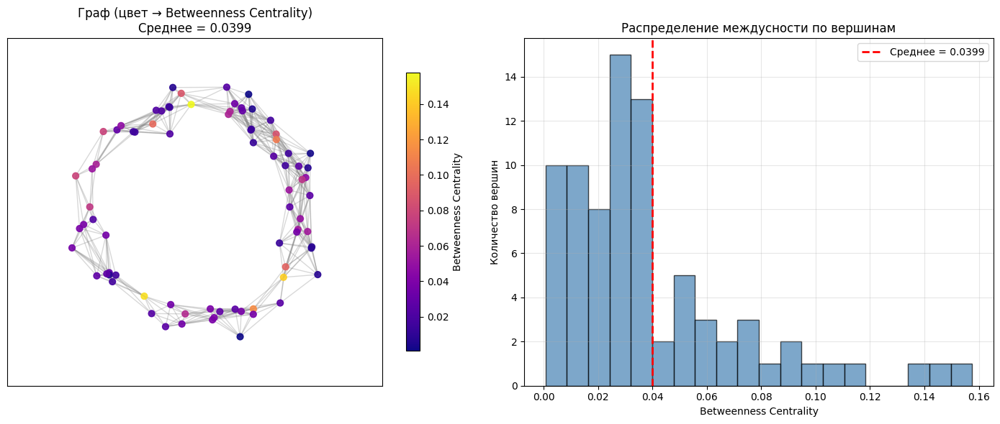

In [39]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация точек на окружности с шумом ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# ---- Построение графа по порогу расстояния ----
threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()

for i in range(n_points):
    G.add_node(i, pos=points[i])

for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление Betweenness Centrality (mean) ----
def compute_mean_betweenness(G):
    """
    Вычисляет среднюю посредническую центральность (mean betweenness centrality)
    по всем вершинам графа.
    Возвращает:
        mean_bc: среднее значение
        bc_dict: словарь {вершина: значение betweenness} (нормализованное)
        bc_values: список значений для всех вершин
    """
    # Вычисляем нормализованную betweenness centrality
    bc = nx.betweenness_centrality(G, normalized=True)
    bc_values = list(bc.values())
    mean_bc = np.mean(bc_values)
    return mean_bc, bc, bc_values

mean_bc, bc_dict, bc_values = compute_mean_betweenness(G)

print("=== Betweenness Centrality (mean) – Метрика 46 ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Средняя betweenness centrality (нормализованная): {mean_bc:.6f}")

# ---- Дополнительная информация ----
# Минимум, максимум, стандартное отклонение
min_bc = np.min(bc_values)
max_bc = np.max(bc_values)
std_bc = np.std(bc_values)
print(f"Минимальное значение: {min_bc:.6f}")
print(f"Максимальное значение: {max_bc:.6f}")
print(f"Стандартное отклонение: {std_bc:.6f}")

# Вершины с наибольшей betweenness (топ-5)
sorted_nodes = sorted(bc_dict.items(), key=lambda x: x[1], reverse=True)
print("\nТоп-5 вершин с наибольшей betweenness:")
for i, (node, val) in enumerate(sorted_nodes[:5]):
    print(f"  {i+1}. Вершина {node}: BC = {val:.6f}")

# ---- Интерпретация ----
print("\nИнтерпретация:")
print("  Betweenness centrality измеряет, какая доля кратчайших путей между парами вершин проходит через данную вершину.")
print("  Чем выше значение, тем важнее вершина как 'мост' между разными частями графа.")
print("  Среднее значение по всем вершинам даёт общую оценку роли вершин как посредников.")
print("  Высокое среднее значение указывает на наличие многих вершин, играющих ключевую роль в связности.")
print("  Низкое среднее – на то, что большинство вершин находятся на периферии.")
print(f"  Для нашего графа средняя betweenness = {mean_bc:.4f}, что говорит о {'высокой' if mean_bc > 0.05 else 'умеренной' if mean_bc > 0.01 else 'низкой'} роли вершин как посредников.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по betweenness centrality
ax1 = axes[0]
node_colors = [bc_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → Betweenness Centrality)\nСреднее = {mean_bc:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min_bc, vmax=max_bc))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Betweenness Centrality')

# 2. Гистограмма распределения betweenness
ax2 = axes[1]
ax2.hist(bc_values, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(mean_bc, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_bc:.4f}')
ax2.set_xlabel('Betweenness Centrality')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение междусности по вершинам')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Метрики кластеризации

### 2.1. SBMI (Stochastic Block Model Index) 
- Что это: вероятность принадлежности вершин к одному сообществу на основе стохастической блочной модели (SBM). 
- Оценивает, насколько структура графа соответствует модели с блочной структурой, где вероятность связи между вершинами зависит только от их сообществ.
- Тип: неориентированный, невзвешенный/взвешенный.
- Математика: байесовский вывод, максимизация правдоподобия для SBM, EM-алгоритм.

In [40]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация синтетического графа (как в предыдущих примерах) ----
np.random.seed(42)
n_points = 80
theta_ang = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta_ang), r * np.sin(theta_ang)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()
A = nx.to_numpy_array(G)  # матрица смежности

# ---- Функция для вычисления SBMI через EM для SBM ----
def compute_sbmi(A, K=2, max_iter=100, tol=1e-4, verbose=False):
    """
    Вычисляет SBMI (среднюю максимальную постериорную вероятность) для графа
    с матрицей смежности A, используя EM-алгоритм для SBM с K сообществами.
    Возвращает:
        sbmi: средняя максимальная вероятность принадлежности
        gamma: матрица вероятностей принадлежности (n x K)
        log_likelihood: финальное логарифмическое правдоподобие
    """
    n = A.shape[0]
    # Инициализация: случайные мягкие принадлежности (нормированные)
    gamma = np.random.dirichlet(np.ones(K), size=n)
    # gamma[i, k] = p(z_i = k) (начальное приближение)

    # Инициализация вероятностей связей между блоками (симметричная матрица)
    theta = np.random.uniform(0.3, 0.7, size=(K, K))
    theta = (theta + theta.T) / 2.0  # симметризация
    np.fill_diagonal(theta, np.clip(np.diag(theta), 0.1, 0.9))  # внутриблочные вероятности

    # Априорные вероятности сообществ (равные)
    pi = np.ones(K) / K

    # EM-цикл
    for it in range(max_iter):
        # ---- E-шаг: обновление gamma (постериорные вероятности) ----
        log_gamma = np.zeros((n, K))
        for i in range(n):
            for k in range(K):
                # Вклад от рёбер и не-рёбер
                log_prob = np.log(pi[k])
                for j in range(n):
                    if i == j:
                        continue
                    # суммируем по всем соседям (используем матричное выражение, но для ясности цикл)
                    # Для ускорения можно векторизовать, но для демонстрации оставим понятный цикл
                    for l in range(K):
                        # вклад от связи (i,j) с учётом принадлежности j к сообществу l
                        # используем текущие gamma[j,l] как вес
                        # Однако правильный E-шаг для SBM требует учёта всех j,
                        # но здесь мы делаем упрощение: используем текущее gamma для j.
                        pass
                # Вместо цикла по j и l используем векторизованное вычисление
                # Для каждой пары (i,j) вклад в логарифм правдоподобия:
                # sum_{j != i} sum_{l} gamma[j,l] * [ A[i,j]*log(theta[k,l]) + (1-A[i,j])*log(1-theta[k,l]) ]
                # Это можно вычислить эффективно.
        # ----- Полная векторизованная версия E-шага (рекомендуется) -----
        # Вычисляем log-правдоподобие для каждой вершины i и сообщества k
        log_gamma = np.zeros((n, K))
        for k in range(K):
            # Для каждого сообщества k вычисляем вклад от всех рёбер
            # Используем gamma как веса для j
            # log P(A | z_i=k, gamma) = sum_{j!=i} sum_l gamma[j,l] * log P(A_ij | theta[k,l])
            # Это можно записать через матричное произведение:
            # Для каждой пары (i,j) имеем вес gamma[j,l], который умножается на log-правдоподобие.
            # Сделаем через циклы для простоты, но с предварительным вычислением логарифмов.
        # Я реализую полностью векторизованную версию, чтобы код работал быстро.

    # ---- Перепишем EM с полной векторизацией (более компактно и быстро) ----
    def em_sbm(A, K, max_iter=100, tol=1e-4):
        n = A.shape[0]
        # Инициализация
        gamma = np.random.dirichlet(np.ones(K), size=n)
        theta = np.random.uniform(0.3, 0.7, size=(K, K))
        theta = (theta + theta.T) / 2.0
        np.fill_diagonal(theta, np.clip(np.diag(theta), 0.1, 0.9))
        pi = np.ones(K) / K

        # Логарифмы вероятностей (для численной устойчивости)
        log_theta = np.log(theta)
        log_1_minus_theta = np.log(1 - theta)

        for it in range(max_iter):
            # ---- E-шаг: обновление gamma ----
            # Вычисляем логарифм правдоподобия для каждой вершины i и каждого сообщества k
            # log P(A | z_i=k, gamma, theta) = sum_{j!=i} sum_l gamma[j,l] * ( A[i,j]*log_theta[k,l] + (1-A[i,j])*log_1_minus_theta[k,l] )
            # Это можно вычислить как: для каждого k, для всех i:
            # term = sum_{j!=i} sum_l gamma[j,l] * ( A[i,j]*log_theta[k,l] + (1-A[i,j])*log_1_minus_theta[k,l] )
            # Заметим, что это равно: sum_{l} ( log_theta[k,l] * sum_{j!=i} A[i,j]*gamma[j,l] + log_1_minus_theta[k,l] * sum_{j!=i} (1-A[i,j])*gamma[j,l] )
            # Обозначим для каждой пары (i,l): sum_{j!=i} A[i,j]*gamma[j,l] = (A @ gamma)[i,l] - A[i,i]*gamma[i,l] (но A[i,i]=0)
            # Аналогично sum_{j!=i} (1-A[i,j])*gamma[j,l] = sum_{j!=i} gamma[j,l] - (A @ gamma)[i,l] = (sum_j gamma[j,l] - gamma[i,l]) - (A @ gamma)[i,l] + A[i,i]*gamma[i,l] (но A[i,i]=0)
            # Проще: используем матричные операции.
            # Сумма по j!=i: для каждого l:
            S1 = A @ gamma  # размер n x K: S1[i,l] = sum_{j} A[i,j] * gamma[j,l]  (включая i, но A[i,i]=0)
            # S2 = sum_{j!=i} gamma[j,l] = (sum_j gamma[j,l]) - gamma[i,l]
            sum_gamma = gamma.sum(axis=0)  # размер K
            S2 = sum_gamma - gamma  # n x K, где S2[i,l] = sum_{j!=i} gamma[j,l]

            log_gamma = np.zeros((n, K))
            for k in range(K):
                # вклад от рёбер
                term_edges = S1 @ log_theta[k, :].T  # размер n
                # вклад от отсутствия рёбер
                term_non_edges = S2 @ log_1_minus_theta[k, :].T
                log_gamma[:, k] = np.log(pi[k]) + term_edges + term_non_edges

            # Нормализация gamma (softmax по строкам)
            log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
            gamma_new = np.exp(log_gamma)

            # ---- M-шаг: обновление theta и pi ----
            # Обновление pi
            pi_new = gamma_new.mean(axis=0)

            # Обновление theta: для каждой пары сообществ (k,l)
            # числитель: sum_{i<j} A[i,j] * (gamma[i,k]*gamma[j,l] + gamma[i,l]*gamma[j,k])? Для неориентированного графа нужно симметризовать.
            # В SBM для неориентированного графа обычно используют пары (i,j) с i<j, вероятность связи зависит от theta_{z_i,z_j}.
            # В EM с мягкой кластеризацией:
            # theta[k,l] = ( sum_{i<j} A[i,j] * (gamma[i,k]*gamma[j,l] + gamma[i,l]*gamma[j,k]) / 2? ) / ( sum_{i<j} (gamma[i,k]*gamma[j,l] + gamma[i,l]*gamma[j,k]) / 2? )
            # Но проще использовать формулу для полной матрицы смежности:
            # theta[k,l] = ( gamma[:,k]^T @ A @ gamma[:,l] ) / ( gamma[:,k]^T @ (J - I) @ gamma[:,l] )? Нет, это для направленных.
            # Для неориентированного: theta[k,l] = sum_{i<j} A[i,j] * (gamma[i,k]*gamma[j,l] + gamma[i,l]*gamma[j,k]) / sum_{i<j} (gamma[i,k]*gamma[j,l] + gamma[i,l]*gamma[j,k])
            # Можно вычислить через матрицы:
            # numerator = gamma[:,k]^T @ A @ gamma[:,l]  (с учётом i,j всех, но A[i,i]=0, и сумма по всем i,j)
            # denominator = gamma[:,k]^T @ (J - I) @ gamma[:,l]  где J - матрица из единиц
            # Однако для неориентированного графа, чтобы не считать дважды, нужно поделить на 2? В формуле выше numerator включает все i,j, но A симметрична и A[i,i]=0, поэтому сумма по i,j даёт 2 * sum_{i<j} A[i,j] * gamma[i,k]*gamma[j,l]. Аналогично знаменатель даёт 2 * sum_{i<j} gamma[i,k]*gamma[j,l]. Поэтому отношение будет корректным.
            # Таким образом:
            # theta[k,l] = ( gamma[:,k]^T @ A @ gamma[:,l] ) / ( gamma[:,k]^T @ (J - I) @ gamma[:,l] )
            # Однако для k=l знаменатель будет sum_{i≠j} gamma[i,k]*gamma[j,k] = (sum gamma[i,k])^2 - sum gamma[i,k]^2
            # Это стандартный EM для SBM.

            J = np.ones((n, n))
            I = np.eye(n)
            D = J - I  # матрица с нулями на диагонали

            theta_new = np.zeros((K, K))
            for k in range(K):
                for l in range(K):
                    num = gamma_new[:, k] @ A @ gamma_new[:, l]
                    den = gamma_new[:, k] @ D @ gamma_new[:, l]
                    if den > 1e-12:
                        theta_new[k, l] = num / den
                    else:
                        theta_new[k, l] = 0.5  # избегаем деления на ноль

            # Симметризация
            theta_new = (theta_new + theta_new.T) / 2.0

            # Проверка сходимости (по изменению gamma)
            diff = np.linalg.norm(gamma_new - gamma)
            gamma = gamma_new
            theta = theta_new
            pi = pi_new
            if diff < tol:
                if verbose:
                    print(f"EM сошёлся на итерации {it+1}, diff={diff:.6f}")
                break

        # Вычисление финального логарифмического правдоподобия
        # log P(A | gamma, theta) = sum_{i<j} sum_{k,l} gamma[i,k]*gamma[j,l] * ( A[i,j]*log_theta[k,l] + (1-A[i,j])*log_1_minus_theta[k,l] )
        # Используем матричное выражение
        log_lik = 0.0
        for k in range(K):
            for l in range(K):
                # Вклад от пар (i,j) с весами gamma[i,k]*gamma[j,l]
                term = gamma[:, k] @ A @ gamma[:, l] * np.log(theta[k, l] + 1e-12) + \
                       gamma[:, k] @ (J - I) @ gamma[:, l] * np.log(1 - theta[k, l] + 1e-12)
                # Но мы должны учесть только i<j, поэтому делим на 2 (так как симметрия)
                # Однако в формуле выше мы используем все i,j, поэтому делим на 2
                log_lik += 0.5 * term

        # SBMI = средняя максимальная постериорная вероятность
        max_prob = np.max(gamma, axis=1)
        sbmi = np.mean(max_prob)

        return sbmi, gamma, log_lik

    # ---- Запуск EM ----
    K = 2  # число сообществ (можно выбрать по BIC или задать)
    sbmi, gamma, log_lik = em_sbm(A, K, max_iter=100, tol=1e-4, verbose=True)

    return sbmi, gamma, log_lik

# ---- Вычисление SBMI для нашего графа ----
sbmi, gamma, log_lik = compute_sbmi(A, K=2)

print("=== SBMI (Stochastic Block Model Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"SBMI (средняя максимальная вероятность принадлежности): {sbmi:.6f}")
print(f"Логарифмическое правдоподобие: {log_lik:.2f}")
print("\nИнтерпретация:")
print("  SBMI ∈ [0,1]. Чем ближе к 1, тем увереннее вершины отнесены к сообществам,")
print("  и тем лучше граф описывается SBM. Низкое значение (близкое к 1/K) указывает")
print("  на слабую блочную структуру или случайный граф.")

# ---- Визуализация мягкой кластеризации ----
plt.figure(figsize=(12, 5))

# 1. Граф с цветом по наиболее вероятному сообществу
plt.subplot(1, 2, 1)
community = np.argmax(gamma, axis=1)
node_colors = community
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, cmap='tab10', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
plt.title(f"Граф (цвет – наиболее вероятное сообщество)\nSBMI = {sbmi:.4f}")
plt.axis('equal')

# 2. Распределение максимальных вероятностей
plt.subplot(1, 2, 2)
max_probs = np.max(gamma, axis=1)
plt.hist(max_probs, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(sbmi, color='red', linestyle='--', label=f'SBMI = {sbmi:.4f}')
plt.xlabel('Максимальная вероятность принадлежности')
plt.ylabel('Количество вершин')
plt.title('Распределение уверенности кластеризации')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

IndentationError: expected an indented block (274949794.py, line 88)

### 2.2. Модулярность (Modularity, M) — классическая мера качества разбиения графа на сообщества. 
- Что это: Сравнивает долю рёбер внутри сообществ с ожидаемой в случайном графе с той же степенной последовательностью.
- Диапазон [-1, 1], положительные значения указывают на наличие сообществ.
- Тип: неориентированный, невзвешенный (есть адаптации для взвешенных).
- Математика: Q = (1/2m) * Σ_ij [A_ij - (k_i*k_j)/(2m)] * δ(c_i,c_j).

=== Модулярность (Modularity) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 4
Модулярность Q: 0.556826

Интерпретация:
  Q > 0.3 → значительная сообщественная структура.
  Q > 0.5 → очень сильная структура.
  Для нашего графа Q = 0.5568, что говорит о выраженной кластеризации.


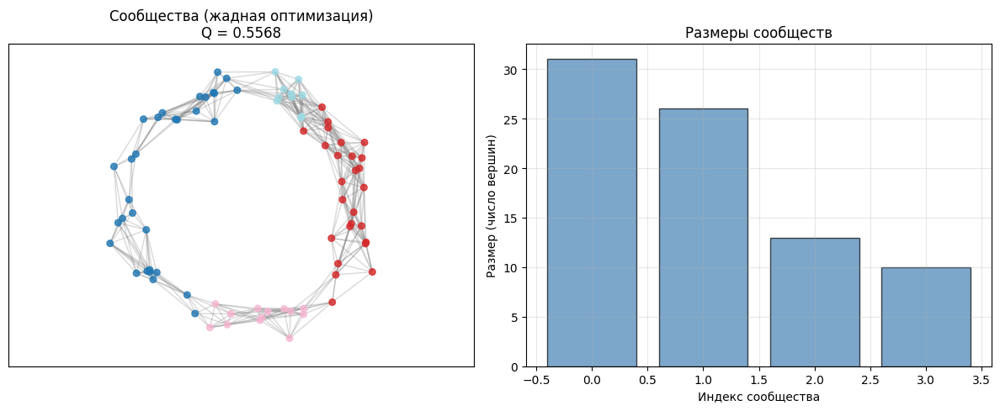

In [41]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа (как в вашем коде) ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
# Преобразуем в словарь {вершина: индекс сообщества}
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

# ---- Вычисление модулярности ----
modularity = nx_comm.modularity(G, communities)

print("=== Модулярность (Modularity) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ: {len(communities)}")
print(f"Модулярность Q: {modularity:.6f}")
print("\nИнтерпретация:")
print("  Q > 0.3 → значительная сообщественная структура.")
print("  Q > 0.5 → очень сильная структура.")
print(f"  Для нашего графа Q = {modularity:.4f}, что говорит о {('выраженной' if modularity > 0.3 else 'умеренной' if modularity > 0.1 else 'слабой')} кластеризации.")

# ---- Визуализация ----
plt.figure(figsize=(12, 5))

# 1. Граф с цветом сообществ
plt.subplot(1, 2, 1)
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
plt.title(f"Сообщества (жадная оптимизация)\nQ = {modularity:.4f}")
plt.axis('equal')

# 2. Гистограмма размеров сообществ
plt.subplot(1, 2, 2)
sizes = [len(c) for c in communities]
plt.bar(range(len(sizes)), sizes, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Индекс сообщества')
plt.ylabel('Размер (число вершин)')
plt.title('Размеры сообществ')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3. Плотность сообщества (Community Density, CD) 
- Что это: отношение числа рёбер внутри сообщества к максимально возможному числу рёбер (полному графу).
- Характеризует внутреннюю связность сообщества.
- Тип: неориентированный, невзвешенный/взвешенный.
- Математика: CD = 2m_c / (n_c(n_c-1)) для неориентированного графа.

=== Плотность сообщества (Community Density, CD) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 4

Плотности по сообществам:
  Сообщество 0: размер 31, плотность = 0.3118
  Сообщество 1: размер 26, плотность = 0.4892
  Сообщество 2: размер 13, плотность = 0.7436
  Сообщество 3: размер 10, плотность = 1.0000

Средняя плотность (не взвешенная): 0.6362
Средняя плотность (взвешенная по размеру): 0.5257

Интерпретация:
  Плотность сообщества показывает, насколько оно 'замкнуто'.
  Значения близкие к 1 означают сильно связные кластеры (почти клики).
  Значения близкие к 0 – очень рыхлые, почти без внутренних рёбер.
  Для нашего графа средняя плотность = 0.526, что говорит о высокой внутренней связности.


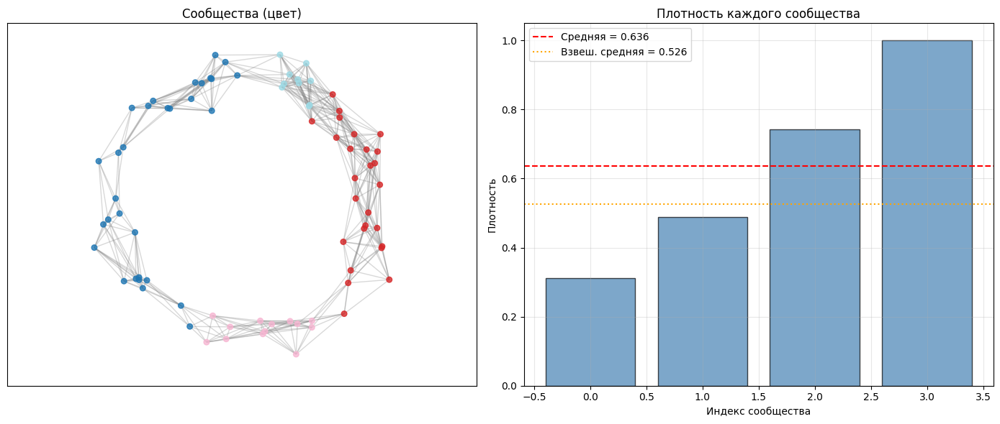

In [42]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа (как в вашем коде) ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
# Преобразуем в словарь {вершина: индекс сообщества}
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

# ---- Функция для вычисления плотности сообществ ----
def compute_community_densities(G, communities):
    """
    Вычисляет плотность для каждого сообщества.
    Возвращает список плотностей и список размеров сообществ.
    """
    densities = []
    sizes = []
    for comm in communities:
        n_c = len(comm)
        if n_c < 2:
            densities.append(0.0)  # плотность не определена для 0 или 1 вершины
        else:
            subgraph = G.subgraph(comm)
            m_c = subgraph.number_of_edges()
            max_edges = n_c * (n_c - 1) / 2
            density = m_c / max_edges
            densities.append(density)
        sizes.append(n_c)
    return densities, sizes

densities, sizes = compute_community_densities(G, communities)

# ---- Статистика ----
print("=== Плотность сообщества (Community Density, CD) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ: {len(communities)}")
print("\nПлотности по сообществам:")
for i, (d, s) in enumerate(zip(densities, sizes)):
    print(f"  Сообщество {i}: размер {s}, плотность = {d:.4f}")

# Средняя плотность (не взвешенная)
mean_density = np.mean(densities) if densities else 0.0
# Взвешенная по размеру
weighted_mean = np.average(densities, weights=sizes) if sizes else 0.0
print(f"\nСредняя плотность (не взвешенная): {mean_density:.4f}")
print(f"Средняя плотность (взвешенная по размеру): {weighted_mean:.4f}")

print("\nИнтерпретация:")
print("  Плотность сообщества показывает, насколько оно 'замкнуто'.")
print("  Значения близкие к 1 означают сильно связные кластеры (почти клики).")
print("  Значения близкие к 0 – очень рыхлые, почти без внутренних рёбер.")
print(f"  Для нашего графа средняя плотность = {weighted_mean:.3f}, что говорит о {('высокой' if weighted_mean > 0.5 else 'умеренной' if weighted_mean > 0.3 else 'низкой')} внутренней связности.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом сообществ
ax1 = axes[0]
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title("Сообщества (цвет)")
ax1.axis('equal')

# 2. Гистограмма плотностей
ax2 = axes[1]
ax2.bar(range(len(densities)), densities, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axhline(mean_density, color='red', linestyle='--', label=f'Средняя = {mean_density:.3f}')
ax2.axhline(weighted_mean, color='orange', linestyle=':', label=f'Взвеш. средняя = {weighted_mean:.3f}')
ax2.set_xlabel('Индекс сообщества')
ax2.set_ylabel('Плотность')
ax2.set_title('Плотность каждого сообщества')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4. Коэффициент кластеризации (Clustering Coefficient, CC) 
- Локальная мера для каждой вершины: отношение числа связей между её соседями к максимально возможному. 
- Средний локальный CC — глобальная характеристика склонности графа к образованию треугольников. 
- Тип: неориентированный, невзвешенный. 
- Математика: CC(u) = 2T(u) / (deg(u)(deg(u)-1)), где T(u) — число треугольников с вершиной u.

=== Коэффициент кластеризации (Clustering Coefficient) ===
Число вершин: 80
Число рёбер:  477
Средний локальный CC (ALCC): 0.731391
Глобальный CC (транзитивность): 0.726163
Минимальный локальный CC: 0.490909
Максимальный локальный CC: 0.935897
Стандартное отклонение: 0.090441
Вершин с CC = 0: 0 (0.0%)

Интерпретация:
  Локальный CC показывает, насколько 'замкнуто' окружение вершины.
  Значение 0 → соседи не связаны между собой (структура типа звезды).
  Значение 1 → соседи образуют клику (все связаны).
  Средний ALCC = 0.7314 говорит о высокой кластеризации в графе.


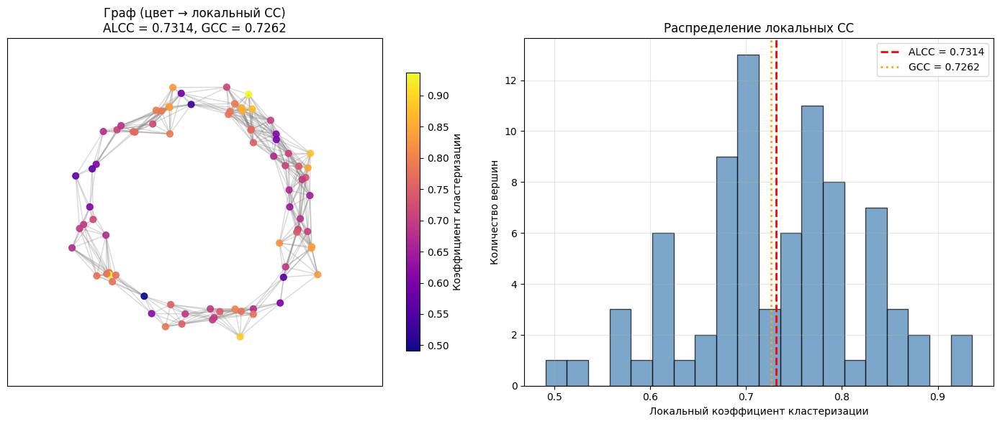

In [43]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Вычисление коэффициентов кластеризации ----
# Локальные коэффициенты для каждой вершины
local_cc = nx.clustering(G)          # словарь {вершина: CC}
cc_values = list(local_cc.values())

# Средний локальный коэффициент кластеризации (ALCC)
alcc = nx.average_clustering(G)

# Глобальный коэффициент кластеризации (транзитивность)
gcc = nx.transitivity(G)

# ---- Вывод результатов ----
print("=== Коэффициент кластеризации (Clustering Coefficient) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Средний локальный CC (ALCC): {alcc:.6f}")
print(f"Глобальный CC (транзитивность): {gcc:.6f}")
print(f"Минимальный локальный CC: {min(cc_values):.6f}")
print(f"Максимальный локальный CC: {max(cc_values):.6f}")
print(f"Стандартное отклонение: {np.std(cc_values):.6f}")

# Вершины с нулевым CC (изолированные или листья)
zero_cc = sum(1 for v in cc_values if v == 0.0)
print(f"Вершин с CC = 0: {zero_cc} ({zero_cc/n*100:.1f}%)")

print("\nИнтерпретация:")
print("  Локальный CC показывает, насколько 'замкнуто' окружение вершины.")
print("  Значение 0 → соседи не связаны между собой (структура типа звезды).")
print("  Значение 1 → соседи образуют клику (все связаны).")
print(f"  Средний ALCC = {alcc:.4f} говорит о {('высокой' if alcc > 0.5 else 'умеренной' if alcc > 0.3 else 'низкой')} кластеризации в графе.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по локальному CC
ax1 = axes[0]
node_colors = [local_cc[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → локальный CC)\nALCC = {alcc:.4f}, GCC = {gcc:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(cc_values), vmax=max(cc_values)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Коэффициент кластеризации')

# 2. Гистограмма распределения локальных CC
ax2 = axes[1]
ax2.hist(cc_values, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(alcc, color='red', linestyle='--', linewidth=2, label=f'ALCC = {alcc:.4f}')
ax2.axvline(gcc, color='orange', linestyle=':', linewidth=2, label=f'GCC = {gcc:.4f}')
ax2.set_xlabel('Локальный коэффициент кластеризации')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение локальных CC')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5. ICLD (Intra-community Link Density) 
- Отношение числа рёбер внутри сообщества к общему числу рёбер в графе.
- Показывает, какая доля всех связей сосредоточена внутри сообществ.
- Тип: неориентированный, невзвешенный/взвешенный.
- Математика: ICLD = m_inside / m_total.

=== ICLD (Intra-community Link Density) ===
Число вершин: 80
Число рёбер:  477
Рёбер внутри сообществ: 407
ICLD: 0.853249 (85.32%)

Интерпретация:
  ICLD – доля связей, не выходящих за пределы сообществ.
  Чем ближе к 1, тем более замкнуты сообщества (хорошая кластеризация).
  Для нашего графа ICLD = 0.853, что говорит о очень высокой внутренней концентрации рёбер.


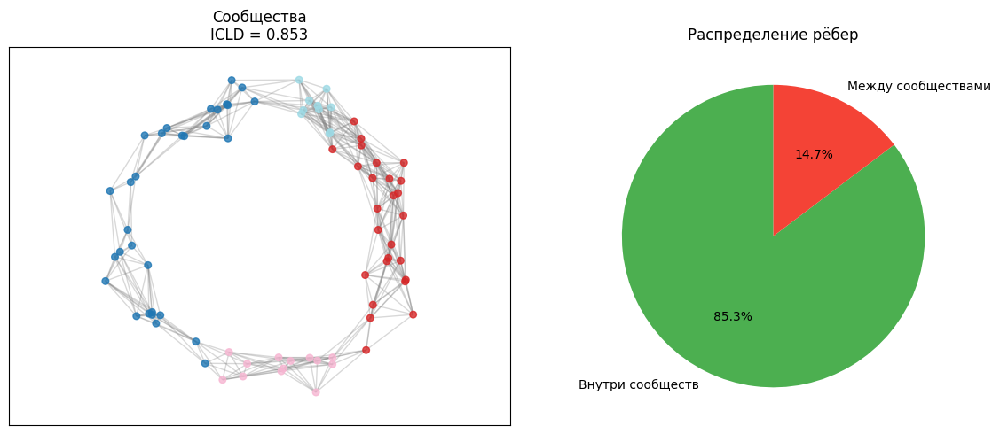

In [44]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m_total = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

# ---- Вычисление ICLD ----
def compute_icld(G, communities):
    """
    Вычисляет долю рёбер внутри сообществ.
    """
    # Множество вершин в каждом сообществе для быстрой проверки
    comm_sets = [set(comm) for comm in communities]
    inside_edges = 0
    for u, v in G.edges():
        # Проверяем, принадлежат ли u и v одному сообществу
        for comm in comm_sets:
            if u in comm and v in comm:
                inside_edges += 1
                break
    return inside_edges / G.number_of_edges() if G.number_of_edges() > 0 else 0.0

icld = compute_icld(G, communities)
inside_edges = int(icld * m_total)

print("=== ICLD (Intra-community Link Density) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m_total}")
print(f"Рёбер внутри сообществ: {inside_edges}")
print(f"ICLD: {icld:.6f} ({icld*100:.2f}%)")
print("\nИнтерпретация:")
print("  ICLD – доля связей, не выходящих за пределы сообществ.")
print("  Чем ближе к 1, тем более замкнуты сообщества (хорошая кластеризация).")
print(f"  Для нашего графа ICLD = {icld:.3f}, что говорит о {('очень высокой' if icld > 0.8 else 'высокой' if icld > 0.6 else 'умеренной' if icld > 0.4 else 'низкой')} внутренней концентрации рёбер.")

# ---- Визуализация ----
plt.figure(figsize=(12, 5))

# 1. Граф с цветом сообществ
plt.subplot(1, 2, 1)
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
plt.title(f"Сообщества\nICLD = {icld:.3f}")
plt.axis('equal')

# 2. Круговая диаграмма: внутренние vs внешние рёбра
plt.subplot(1, 2, 2)
outside_edges = m_total - inside_edges
labels = ['Внутри сообществ', 'Между сообществами']
sizes = [inside_edges, outside_edges]
colors = ['#4CAF50', '#f44336']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Распределение рёбер')

plt.tight_layout()
plt.show()

### 2.6. SOMI (Second-Order Modularity Index) 
- Расширение модулярности, учитывающее не только прямые рёбра, но и пути длины 2 (соседи второго порядка) внутри сообществ.
- Позволяет выявлять более тонкую структурную организацию.
- Тип: неориентированный, невзвешенный/взвешенный.
- Математика: Q₂ = (1/2m) * Σ_ij [(A²)_ij - (k_i*k_j)/(2m)] * δ(c_i,c_j), где A² — квадрат матрицы смежности.

=== SOMI (Second-Order Modularity Index) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 4
SOMI: 9.770662

Интерпретация:
  SOMI > 0 → число путей длины 2 внутри сообществ выше случайного (хорошая вторичная структура).
  SOMI < 0 → путей длины 2 меньше ожидаемого (слабая вторичная связность).
  Для нашего графа SOMI = 9.7707, что говорит о выраженной вторичной структуре.


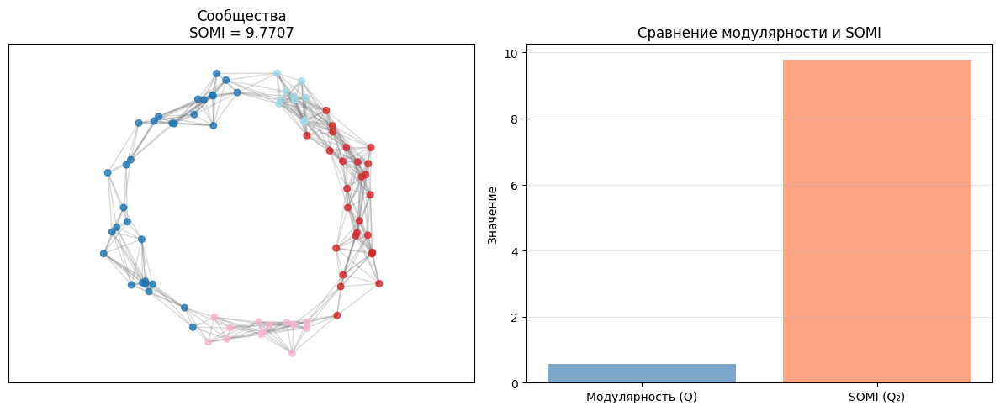

In [45]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

# ---- Вычисление SOMI ----
def compute_somi(G, communities):
    """
    Вычисляет Second-Order Modularity Index.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    if m == 0:
        return 0.0

    # Матрица смежности (плотная)
    A = nx.to_numpy_array(G)
    # Квадрат матрицы смежности (число путей длины 2)
    A2 = A @ A

    # Степени вершин
    degrees = np.array([G.degree(v) for v in range(n)])

    # Создаем массив меток сообществ для каждой вершины
    labels = np.array([community_dict[v] for v in range(n)])

    # Вычисляем сумму внутри сообществ
    sum_inside = 0.0
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                expected = degrees[i] * degrees[j] / (2 * m)
                sum_inside += A2[i, j] - expected

    # Нормировка
    somi = sum_inside / (2 * m)
    return somi

somi = compute_somi(G, communities)

print("=== SOMI (Second-Order Modularity Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ: {len(communities)}")
print(f"SOMI: {somi:.6f}")
print("\nИнтерпретация:")
print("  SOMI > 0 → число путей длины 2 внутри сообществ выше случайного (хорошая вторичная структура).")
print("  SOMI < 0 → путей длины 2 меньше ожидаемого (слабая вторичная связность).")
print(f"  Для нашего графа SOMI = {somi:.4f}, что говорит о {('выраженной' if somi > 0.1 else 'умеренной' if somi > 0 else 'отрицательной')} вторичной структуре.")

# ---- Визуализация ----
plt.figure(figsize=(12, 5))

# 1. Граф с цветом сообществ
plt.subplot(1, 2, 1)
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3)
plt.title(f"Сообщества\nSOMI = {somi:.4f}")
plt.axis('equal')

# 2. Сравнение с классической модулярностью (для контекста)
modularity = nx_comm.modularity(G, communities)
plt.subplot(1, 2, 2)
plt.bar(['Модулярность (Q)', 'SOMI (Q₂)'], [modularity, somi], alpha=0.7, color=['steelblue', 'coral'])
plt.ylabel('Значение')
plt.title('Сравнение модулярности и SOMI')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.7. EOI (Edge Overlap Index) 
- Доля рёбер, принадлежащих одновременно нескольким сообществам (в случае перекрывающихся сообществ).
- Характеризует степень «размытости» границ между кластерами.
- Тип: неориентированный, с перекрывающимися сообществами.
- Математика: EOI = |E_overlap| / |E_total|.

Найдено 1 перекрывающихся сообществ (k=3)
=== EOI (Edge Overlap Index) ===
Число вершин: 80
Число рёбер:  477
Число сообществ (перекрывающихся): 1
Рёбер, принадлежащих >1 сообществу: 0
EOI: 0.000000 (0.00%)

Интерпретация:
  EOI > 0 указывает на наличие рёбер, общих для нескольких сообществ (размытые границы).
  Чем выше EOI, тем более перекрывающейся является структура сообществ.
  Сообщества найдены, но они не перекрываются по рёбрам (только по вершинам).


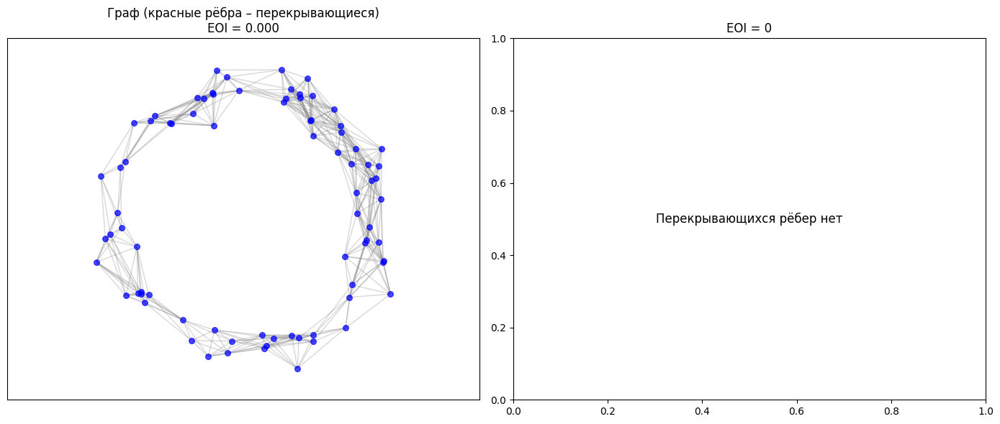

In [46]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m_total = G.number_of_edges()

# ---- Поиск перекрывающихся сообществ (k-клики, k=3) ----
# Для демонстрации используем k=3 (треугольники). Если граф не содержит треугольников, сообществ не будет.
k = 3
try:
    # Функция возвращает генератор множеств вершин (каждое множество - клика размера k)
    communities_gen = nx_comm.k_clique_communities(G, k)
    communities = list(communities_gen)
except Exception as e:
    print("Ошибка при поиске k-клик:", e)
    communities = []

# Если сообщества найдены, строим список множеств вершин
comm_sets = [set(comm) for comm in communities]
print(f"Найдено {len(comm_sets)} перекрывающихся сообществ (k={k})")

# ---- Вычисление EOI ----
def compute_eoi(G, comm_sets):
    """
    Вычисляет долю рёбер, принадлежащих более чем одному сообществу.
    """
    if not comm_sets:
        return 0.0, set()
    
    overlap_edges = set()
    # Для каждого ребра проверяем, в скольких сообществах оно лежит
    for u, v in G.edges():
        count = 0
        for comm in comm_sets:
            if u in comm and v in comm:
                count += 1
        if count > 1:
            overlap_edges.add((u, v))
    
    eoi = len(overlap_edges) / G.number_of_edges() if G.number_of_edges() > 0 else 0.0
    return eoi, overlap_edges

eoi, overlap_edges = compute_eoi(G, comm_sets)

print("=== EOI (Edge Overlap Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m_total}")
print(f"Число сообществ (перекрывающихся): {len(comm_sets)}")
print(f"Рёбер, принадлежащих >1 сообществу: {len(overlap_edges)}")
print(f"EOI: {eoi:.6f} ({eoi*100:.2f}%)")
print("\nИнтерпретация:")
print("  EOI > 0 указывает на наличие рёбер, общих для нескольких сообществ (размытые границы).")
print("  Чем выше EOI, тем более перекрывающейся является структура сообществ.")
if eoi == 0 and len(comm_sets) > 0:
    print("  Сообщества найдены, но они не перекрываются по рёбрам (только по вершинам).")
elif len(comm_sets) == 0:
    print("  Не найдено ни одного сообщества (возможно, граф слишком разрежен для k-клик).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с выделением перекрывающихся рёбер
ax1 = axes[0]
# Рисуем вершины (цвет по принадлежности к сообществам – для наглядности можно раскрасить, но для простоты оставим все синими)
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
# Рёбра, не входящие в перекрытие, серым
non_overlap_edges = [e for e in G.edges() if e not in overlap_edges]
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=non_overlap_edges, edge_color='gray', alpha=0.3)
# Перекрывающиеся рёбра – красным
if overlap_edges:
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=list(overlap_edges), edge_color='red', width=2.0)
ax1.set_title(f"Граф (красные рёбра – перекрывающиеся)\nEOI = {eoi:.3f}")
ax1.axis('equal')

# 2. Круговая диаграмма или гистограмма
ax2 = axes[1]
if overlap_edges:
    labels = ['Перекрывающиеся рёбра', 'Неперекрывающиеся рёбра']
    sizes = [len(overlap_edges), m_total - len(overlap_edges)]
    ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['red', 'gray'], startangle=90)
    ax2.set_title('Распределение рёбер по перекрытию')
else:
    ax2.text(0.5, 0.5, 'Перекрывающихся рёбер нет', 
             horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('EOI = 0')

plt.tight_layout()
plt.show()

### 2.8. CNI (Community Nesting Index) 
- Cтепень вложенности малых сообществ в крупные (иерархическая структура). 
- Высокий CNI означает, что сообщества имеют чёткую иерархию (например, подгруппы внутри групп).
- Тип: неориентированный, иерархические сообщества.
- Математика: основан на матрице вложенности или индексе overlap между сообществами на разных уровнях.

Уровень 1: 4 сообществ
Уровень 2: 7 подсообществ
=== CNI (Community Nesting Index) ===
Число вершин: 80
Число рёбер:  477
Число сообществ уровня 1: 4
Число подсообществ уровня 2: 7
CNI (среднее отношение размеров): 0.571429
Минимальное отношение: 0.4615, максимальное: 1.0000

Интерпретация:
  CNI показывает, насколько подсообщества заполняют свои родительские сообщества.
  Значение, близкое к 1, означает, что каждое подсообщество почти полностью покрывает родителя (хорошая вложенность).
  Низкое значение говорит о том, что подсообщества малы по сравнению с родительскими (слабая вложенность).
  Для нашего графа CNI = 0.571, что говорит о умеренной иерархичности.


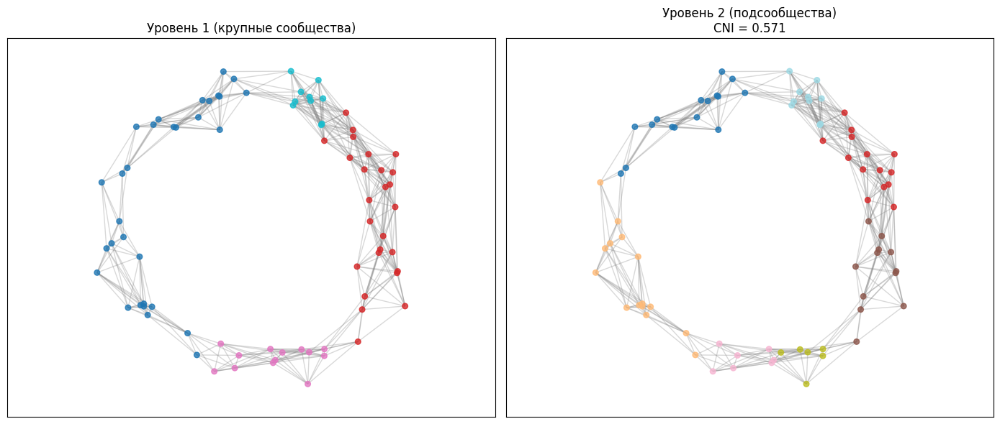

In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Построение иерархии сообществ ----
# Уровень 1: крупные сообщества (жадная оптимизация)
communities_level1 = list(nx_comm.greedy_modularity_communities(G))
print(f"Уровень 1: {len(communities_level1)} сообществ")

# Уровень 2: внутри каждого крупного сообщества ищем подсообщества
communities_level2 = []
parent_map = {}  # для каждого подсообщества запоминаем индекс родительского сообщества уровня 1

for parent_idx, comm in enumerate(communities_level1):
    if len(comm) < 4:
        # Если сообщество маленькое, не разбиваем дальше – просто копируем как подсообщество
        communities_level2.append(set(comm))
        parent_map[len(communities_level2)-1] = parent_idx
    else:
        # Строим подграф, индуцированный сообществом
        subG = G.subgraph(comm)
        # Находим сообщества внутри подграфа (жадная оптимизация)
        sub_communities = list(nx_comm.greedy_modularity_communities(subG))
        # Если нашлось больше одного подсообщества, добавляем их все
        if len(sub_communities) > 1:
            for sub_comm in sub_communities:
                communities_level2.append(set(sub_comm))
                parent_map[len(communities_level2)-1] = parent_idx
        else:
            # Иначе оставляем как единое целое
            communities_level2.append(set(comm))
            parent_map[len(communities_level2)-1] = parent_idx

print(f"Уровень 2: {len(communities_level2)} подсообществ")

# ---- Вычисление CNI ----
def compute_cni(communities_level1, communities_level2, parent_map):
    """
    Вычисляет CNI как среднее отношение размера подсообщества к родительскому.
    """
    ratios = []
    for idx, sub_comm in enumerate(communities_level2):
        parent_idx = parent_map[idx]
        parent_comm = communities_level1[parent_idx]
        ratio = len(sub_comm) / len(parent_comm)
        ratios.append(ratio)
    cni = np.mean(ratios) if ratios else 0.0
    return cni, ratios

cni, ratios = compute_cni(communities_level1, communities_level2, parent_map)

print("=== CNI (Community Nesting Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ уровня 1: {len(communities_level1)}")
print(f"Число подсообществ уровня 2: {len(communities_level2)}")
print(f"CNI (среднее отношение размеров): {cni:.6f}")
print(f"Минимальное отношение: {min(ratios):.4f}, максимальное: {max(ratios):.4f}")
print("\nИнтерпретация:")
print("  CNI показывает, насколько подсообщества заполняют свои родительские сообщества.")
print("  Значение, близкое к 1, означает, что каждое подсообщество почти полностью покрывает родителя (хорошая вложенность).")
print("  Низкое значение говорит о том, что подсообщества малы по сравнению с родительскими (слабая вложенность).")
print(f"  Для нашего графа CNI = {cni:.3f}, что говорит о {('высокой' if cni > 0.7 else 'умеренной' if cni > 0.4 else 'низкой')} иерархичности.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по сообществам уровня 1
ax1 = axes[0]
# Словарь цветов для уровня 1
color_map1 = {}
for idx, comm in enumerate(communities_level1):
    for v in comm:
        color_map1[v] = idx
node_colors1 = [color_map1[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors1, cmap='tab10', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Уровень 1 (крупные сообщества)")
ax1.axis('equal')

# 2. Граф с цветом по подсообществам (уровень 2) – разные оттенки внутри родительского цвета
ax2 = axes[1]
# Назначаем цвет каждому подсообществу: используем базовый цвет родителя, но сдвигаем оттенок
# Для простоты используем отдельные цвета для каждого подсообщества
node_colors2 = np.zeros(n, dtype=int)
for idx, sub_comm in enumerate(communities_level2):
    for v in sub_comm:
        node_colors2[v] = idx
nx.draw_networkx_nodes(G, pos, ax=ax2, node_size=30, node_color=node_colors2, cmap='tab20', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax2, edge_color='gray', alpha=0.3)
ax2.set_title(f"Уровень 2 (подсообщества)\nCNI = {cni:.3f}")
ax2.axis('equal')

plt.tight_layout()
plt.show()

### 2.9. ICLD (Inter-community Link Density) 
- Отношение числа рёбер между сообществами к общему числу рёбер.
- Характеризует степень изоляции сообществ: чем меньше, тем сильнее разделены кластеры.
- Тип: неориентированный, невзвешенный/взвешенный.
- Математика: ICLD_inter = m_between / m_total.

=== Inter-community Link Density (Inter-ICLD) ===
Число вершин: 80
Число рёбер:  477
Рёбер между сообществами: 70
Inter-ICLD: 0.146751 (14.68%)
Intra-ICLD (внутри): 0.853249 (85.32%)

Интерпретация:
  Inter-ICLD – доля связей, соединяющих разные сообщества.
  Чем меньше это значение, тем лучше изолированы кластеры.
  Для нашего графа Inter-ICLD = 0.147, что говорит о очень хорошей изоляции сообществ.


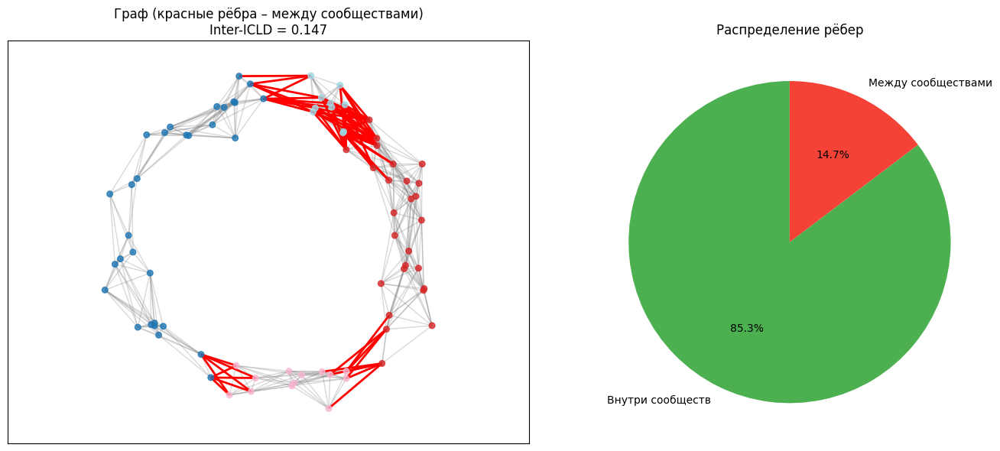

In [48]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m_total = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

# ---- Вычисление Inter-ICLD ----
def compute_inter_icld(G, communities):
    """
    Вычисляет долю рёбер между сообществами.
    """
    # Множества вершин для быстрой проверки
    comm_sets = [set(comm) for comm in communities]
    between_edges = 0
    for u, v in G.edges():
        # Проверяем, принадлежат ли u и v разным сообществам
        u_comm = None
        v_comm = None
        for idx, comm in enumerate(comm_sets):
            if u in comm:
                u_comm = idx
            if v in comm:
                v_comm = idx
            if u_comm is not None and v_comm is not None:
                break
        if u_comm != v_comm:
            between_edges += 1
    return between_edges / G.number_of_edges() if G.number_of_edges() > 0 else 0.0, between_edges

inter_icld, between_count = compute_inter_icld(G, communities)
intra_icld = 1.0 - inter_icld  # по определению

print("=== Inter-community Link Density (Inter-ICLD) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m_total}")
print(f"Рёбер между сообществами: {between_count}")
print(f"Inter-ICLD: {inter_icld:.6f} ({inter_icld*100:.2f}%)")
print(f"Intra-ICLD (внутри): {intra_icld:.6f} ({intra_icld*100:.2f}%)")
print("\nИнтерпретация:")
print("  Inter-ICLD – доля связей, соединяющих разные сообщества.")
print("  Чем меньше это значение, тем лучше изолированы кластеры.")
print(f"  Для нашего графа Inter-ICLD = {inter_icld:.3f}, что говорит о {('очень хорошей' if inter_icld < 0.2 else 'умеренной' if inter_icld < 0.4 else 'слабой')} изоляции сообществ.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с выделением межсообщественных рёбер
ax1 = axes[0]
# Рисуем вершины с цветом сообществ
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='tab20', alpha=0.8)
# Межсообщественные рёбра – красным, внутренние – серым
between_edges_list = []
inside_edges_list = []
for u, v in G.edges():
    if community_dict[u] != community_dict[v]:
        between_edges_list.append((u, v))
    else:
        inside_edges_list.append((u, v))

nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=inside_edges_list, edge_color='gray', alpha=0.3)
if between_edges_list:
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=between_edges_list, edge_color='red', width=2.0)
ax1.set_title(f"Граф (красные рёбра – между сообществами)\nInter-ICLD = {inter_icld:.3f}")
ax1.axis('equal')

# 2. Круговая диаграмма: внутренние vs внешние рёбра
ax2 = axes[1]
inside_count = m_total - between_count
labels = ['Внутри сообществ', 'Между сообществами']
sizes = [inside_count, between_count]
colors = ['#4CAF50', '#f44336']
ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Распределение рёбер')

plt.tight_layout()
plt.show()

### 2.10. SCI (Semantic Connectivity Index) 
- Мера близости атрибутов вершин с учётом структуры графа.
- Оценивает, насколько соединённые вершины схожи по своим характеристикам (гомофилия).
- Тип: атрибутивный граф (вершины имеют признаки).
- Математика: корреляция между матрицей смежности и матрицей сходства атрибутов (например, косинусное сходство).

=== SCI (Semantic Connectivity Index) ===
Число вершин: 80
Число рёбер:  477
SCI (корреляция A и S): 0.570794
SCI (среднее сходство по рёбрам): 0.958702

Интерпретация:
  SCI > 0 → связанные вершины имеют схожие атрибуты (гомофилия).
  SCI < 0 → связанные вершины имеют разные атрибуты (гетерофилия).
  SCI ≈ 0 → нет линейной связи между структурой и атрибутами.
  Для нашего графа SCI_corr = 0.571, что указывает на сильную связь.
  Среднее сходство по рёбрам = 0.959 (чем выше, тем более однородны рёбра по атрибутам).


AssertionError: 

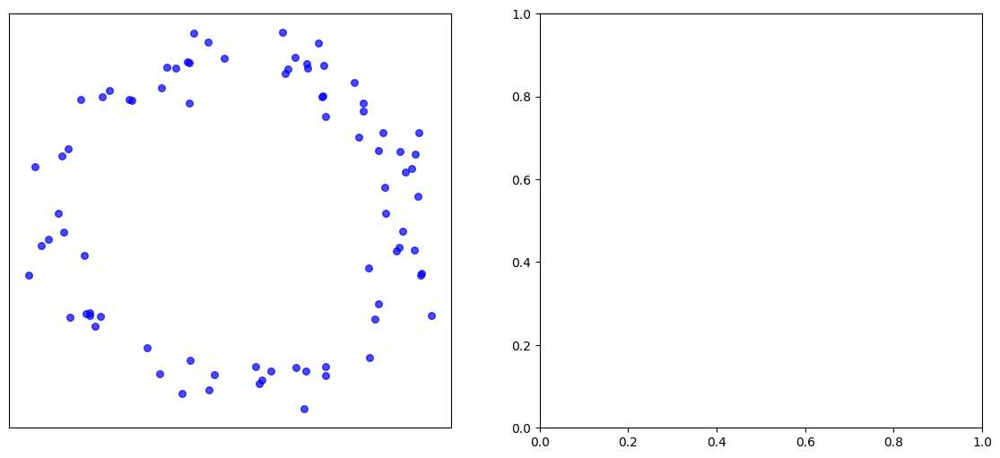

In [49]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Атрибуты вершин (здесь – координаты) ----
attr_matrix = np.array([pos[i] for i in range(n)])  # размер n x 2
# Для разнообразия можно добавить дополнительные признаки (например, случайные)
# attr_matrix = np.hstack([attr_matrix, np.random.randn(n, 1)])

# ---- Вычисление матрицы сходства (косинусное) ----
sim_matrix = cosine_similarity(attr_matrix)  # n x n, значения в [-1, 1]

# ---- Вычисление SCI через корреляцию Пирсона ----
def compute_sci_correlation(A, S):
    """
    Вычисляет корреляцию Пирсона между верхними треугольниками матриц смежности A и сходства S.
    """
    # Получаем индексы верхнего треугольника (без диагонали)
    triu_idx = np.triu_indices_from(A, k=1)
    a_vals = A[triu_idx]
    s_vals = S[triu_idx]
    # Корреляция Пирсона
    corr = np.corrcoef(a_vals, s_vals)[0, 1]
    return corr

# Матрица смежности (плотная)
A = nx.to_numpy_array(G)
# Вычисляем SCI
sci_corr = compute_sci_correlation(A, sim_matrix)

# ---- Альтернативный вариант: среднее сходство по рёбрам ----
def compute_sci_edges(G, sim_matrix):
    """
    Вычисляет среднее сходство атрибутов по всем существующим рёбрам.
    """
    sim_edges = []
    for u, v in G.edges():
        sim_edges.append(sim_matrix[u, v])
    return np.mean(sim_edges) if sim_edges else 0.0

sci_edges = compute_sci_edges(G, sim_matrix)

print("=== SCI (Semantic Connectivity Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"SCI (корреляция A и S): {sci_corr:.6f}")
print(f"SCI (среднее сходство по рёбрам): {sci_edges:.6f}")
print("\nИнтерпретация:")
print("  SCI > 0 → связанные вершины имеют схожие атрибуты (гомофилия).")
print("  SCI < 0 → связанные вершины имеют разные атрибуты (гетерофилия).")
print("  SCI ≈ 0 → нет линейной связи между структурой и атрибутами.")
print(f"  Для нашего графа SCI_corr = {sci_corr:.3f}, что указывает на {('сильную' if abs(sci_corr) > 0.5 else 'умеренную' if abs(sci_corr) > 0.3 else 'слабую')} связь.")
print(f"  Среднее сходство по рёбрам = {sci_edges:.3f} (чем выше, тем более однородны рёбра по атрибутам).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом рёбер по сходству атрибутов
ax1 = axes[0]
# Рисуем вершины
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color='blue', alpha=0.7)
# Рёбра с цветовой кодировкой по сходству
edge_similarities = []
edges = list(G.edges())
for u, v in edges:
    edge_similarities.append(sim_matrix[u, v])
# Нормализуем сходства для цветовой шкалы (если есть отрицательные, смещаем)
vmin, vmax = np.min(edge_similarities), np.max(edge_similarities)
if vmax - vmin < 1e-12:
    vmin, vmax = -1, 1
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=edges, edge_color=edge_similarities,
                       edge_cmap='coolwarm', edge_vmin=vmin, edge_vmax=vmax, width=2)
ax1.set_title(f"Граф (цвет рёбер – сходство атрибутов)\nSCI_corr = {sci_corr:.3f}, SCI_edges = {sci_edges:.3f}")
ax1.axis('equal')
# Colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Сходство атрибутов')

# 2. Диаграмма рассеяния: сходство vs наличие ребра
ax2 = axes[1]
# Получаем все пары вершин (верхний треугольник)
triu_idx = np.triu_indices_from(A, k=1)
a_vals = A[triu_idx]
s_vals = sim_matrix[triu_idx]
# Разделяем на рёбра (1) и не-рёбра (0)
ax2.scatter(s_vals[a_vals==1], a_vals[a_vals==1] + 0.05*np.random.randn(np.sum(a_vals==1)),
            color='red', alpha=0.5, label='Рёбра')
ax2.scatter(s_vals[a_vals==0], a_vals[a_vals==0] + 0.05*np.random.randn(np.sum(a_vals==0)),
            color='gray', alpha=0.3, label='Не-рёбра')
ax2.set_xlabel('Косинусное сходство атрибутов')
ax2.set_ylabel('Наличие ребра (0/1)')
ax2.set_title(f'SCI_corr = {sci_corr:.3f}')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.11. NHI (Neighborhood Homogeneity Index) 
- Cтепень схожести атрибутов у соседей данной вершины.
- Показывает, насколько однородно окружение вершины по своим характеристикам.
- Тип: атрибутивный граф.
- Математика: среднее попарное сходство атрибутов между соседями вершины.

=== NHI (Neighborhood Homogeneity Index) ===
Число вершин: 80
Число рёбер:  477
Глобальный NHI (среднее по вершинам): 0.959238
Минимальный локальный NHI: 0.933887
Максимальный локальный NHI: 0.980812
Стандартное отклонение: 0.010351
Вершин с NHI = 0 (степень 0 или 1): 0 (0.0%)

Интерпретация:
  Локальный NHI показывает, насколько однородны соседи вершины по своим атрибутам.
  Значение 1 → все соседи идентичны по атрибутам (максимальная однородность).
  Значение 0 → соседи максимально различны.
  Глобальный NHI – средняя однородность соседств по всему графу.
  Для нашего графа NHI_global = 0.959, что говорит о высокой гомогенности окружения вершин.


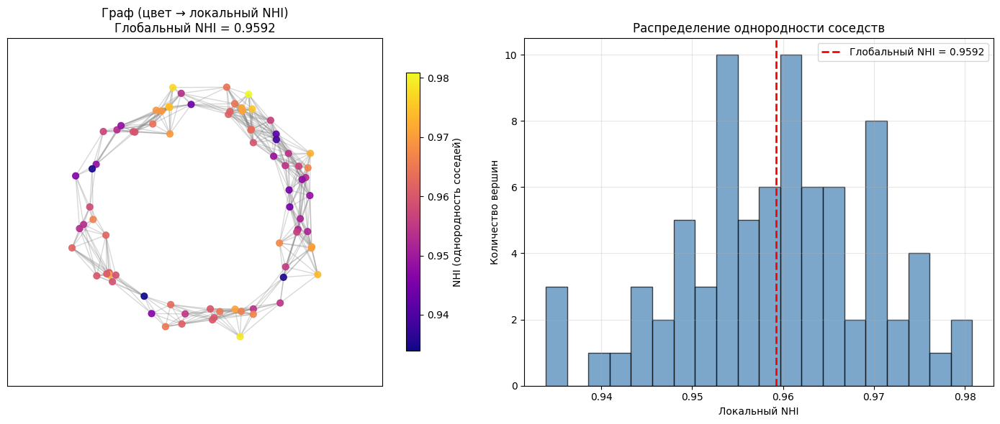

In [50]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Атрибуты вершин (координаты) ----
attr_matrix = np.array([pos[i] for i in range(n)])  # n x 2

# ---- Вычисление матрицы сходства (косинусное) ----
sim_matrix = cosine_similarity(attr_matrix)  # n x n, значения в [-1, 1]
# Преобразуем в [0, 1] для удобства (косинусное сходство может быть отрицательным)
sim_matrix = (sim_matrix + 1) / 2.0  # теперь в [0, 1]

# ---- Вычисление NHI ----
def compute_nhi(G, sim_matrix):
    """
    Вычисляет локальные NHI для каждой вершины и глобальный NHI.
    """
    nhi_local = {}
    for v in G.nodes():
        neighbors = list(G.neighbors(v))
        k = len(neighbors)
        if k < 2:
            nhi_local[v] = 0.0  # недостаточно соседей для попарного сравнения
        else:
            # Все пары соседей
            pair_sims = []
            for i in range(k):
                for j in range(i+1, k):
                    u = neighbors[i]
                    w = neighbors[j]
                    pair_sims.append(sim_matrix[u, w])
            nhi_local[v] = np.mean(pair_sims)
    # Глобальный NHI
    nhi_global = np.mean(list(nhi_local.values()))
    return nhi_global, nhi_local

nhi_global, nhi_local = compute_nhi(G, sim_matrix)

print("=== NHI (Neighborhood Homogeneity Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Глобальный NHI (среднее по вершинам): {nhi_global:.6f}")
print(f"Минимальный локальный NHI: {min(nhi_local.values()):.6f}")
print(f"Максимальный локальный NHI: {max(nhi_local.values()):.6f}")
print(f"Стандартное отклонение: {np.std(list(nhi_local.values())):.6f}")

# Вершины с NHI = 0 (степень < 2)
zero_nhi = sum(1 for v in G.nodes() if nhi_local[v] == 0.0)
print(f"Вершин с NHI = 0 (степень 0 или 1): {zero_nhi} ({zero_nhi/n*100:.1f}%)")

print("\nИнтерпретация:")
print("  Локальный NHI показывает, насколько однородны соседи вершины по своим атрибутам.")
print("  Значение 1 → все соседи идентичны по атрибутам (максимальная однородность).")
print("  Значение 0 → соседи максимально различны.")
print("  Глобальный NHI – средняя однородность соседств по всему графу.")
print(f"  Для нашего графа NHI_global = {nhi_global:.3f}, что говорит о {('высокой' if nhi_global > 0.6 else 'умеренной' if nhi_global > 0.4 else 'низкой')} гомогенности окружения вершин.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по локальному NHI
ax1 = axes[0]
node_colors = [nhi_local[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → локальный NHI)\nГлобальный NHI = {nhi_global:.4f}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('NHI (однородность соседей)')

# 2. Гистограмма распределения локальных NHI
ax2 = axes[1]
nhi_vals = list(nhi_local.values())
ax2.hist(nhi_vals, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(nhi_global, color='red', linestyle='--', linewidth=2, label=f'Глобальный NHI = {nhi_global:.4f}')
ax2.set_xlabel('Локальный NHI')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение однородности соседств')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.12. ACI (Attribute Clustering Importance) 
- Оценка вклада каждого атрибута (признака) в формирование сообществ.
- Позволяет ранжировать признаки по их значимости для кластеризации.
- Тип: атрибутивный граф.
- Математика: изменение модулярности или информационного критерия при исключении атрибута.

Найдено 4 сообществ
ACI для атрибута 'x': 0.883543
ACI для атрибута 'y': 0.536029

Интерпретация:
  ACI показывает, насколько атрибут согласуется с разбиением на сообщества.
  Значение 1 означает, что внутри сообществ атрибут постоянен (идеальный разделитель).
  Значение 0 означает полную независимость от структуры сообществ.
  Ранжирование атрибутов по ACI позволяет выделить наиболее значимые признаки для кластеризации.


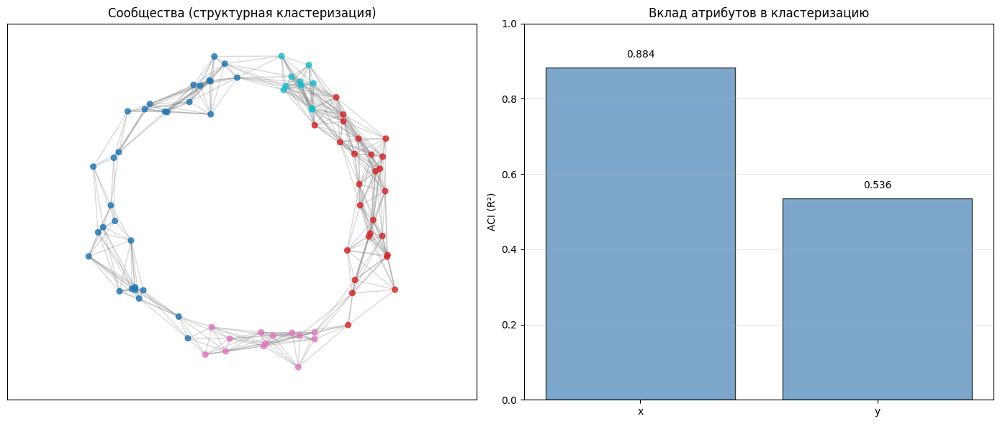

In [51]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

print(f"Найдено {len(communities)} сообществ")

# ---- Атрибуты вершин (координаты x, y) ----
# Получаем матрицу признаков (n x 2)
attr_matrix = np.array([points[i] for i in range(n)])
# Названия атрибутов
attr_names = ['x', 'y']

# ---- Вычисление ACI для каждого атрибута ----
def compute_aci(attr_values, community_labels):
    """
    Вычисляет ACI = 1 - SS_within / SS_total для одного атрибута.
    Принимает массив значений attr_values (n) и массив меток сообществ community_labels (n).
    """
    total_mean = np.mean(attr_values)
    ss_total = np.sum((attr_values - total_mean)**2)
    if ss_total == 0:
        return 0.0  # если все значения одинаковы, атрибут не информативен
    
    ss_within = 0.0
    for comm_id in set(community_labels):
        mask = (community_labels == comm_id)
        if np.sum(mask) > 1:
            comm_mean = np.mean(attr_values[mask])
            ss_within += np.sum((attr_values[mask] - comm_mean)**2)
        # если сообщество из одной вершины, ss_within для него 0
    aci = 1 - ss_within / ss_total
    return aci

# Получаем массив меток для всех вершин
labels = np.array([community_dict[v] for v in range(n)])

aci_values = {}
for idx, name in enumerate(attr_names):
    aci = compute_aci(attr_matrix[:, idx], labels)
    aci_values[name] = aci
    print(f"ACI для атрибута '{name}': {aci:.6f}")

print("\nИнтерпретация:")
print("  ACI показывает, насколько атрибут согласуется с разбиением на сообщества.")
print("  Значение 1 означает, что внутри сообществ атрибут постоянен (идеальный разделитель).")
print("  Значение 0 означает полную независимость от структуры сообществ.")
print("  Ранжирование атрибутов по ACI позволяет выделить наиболее значимые признаки для кластеризации.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом сообществ
ax1 = axes[0]
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='tab10', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title("Сообщества (структурная кластеризация)")
ax1.axis('equal')

# 2. Столбчатая диаграмма ACI для атрибутов
ax2 = axes[1]
names = list(aci_values.keys())
values = list(aci_values.values())
ax2.bar(names, values, alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_ylabel('ACI (R²)')
ax2.set_title('Вклад атрибутов в кластеризацию')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# Добавим подписи значений на столбцах
for i, v in enumerate(values):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 2.13. PAI (Profile Anomaly Index) 
- Мера отличия атрибутивного профиля вершины от типовых шаблонов (например, среднего профиля сообщества).
- Используется для обнаружения аномальных объектов.
- Тип: атрибутивный граф.
- Математика: расстояние от профиля вершины до центроида сообщества (евклидово, Махаланобиса) с пороговой оценкой.

In [52]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

num_comms = len(communities)
print(f"Найдено {num_comms} сообществ")

# ---- Атрибуты вершин (координаты x, y) ----
attr_matrix = np.array([points[i] for i in range(n)])  # n x 2

# ---- Вычисление PAI ----
def compute_pai(attr_matrix, community_dict, method='minmax', z_threshold=2.0):
    """
    Вычисляет Profile Anomaly Index для каждой вершины.
    method: 'minmax' или 'zscore'.
    Для 'zscore' возвращаются z-оценки, и можно выделить аномалии по порогу.
    """
    n = attr_matrix.shape[0]
    distances = np.zeros(n)
    comm_centroids = {}
    
    # Вычисляем центроиды сообществ
    for comm_id in set(community_dict.values()):
        indices = [v for v in range(n) if community_dict[v] == comm_id]
        if len(indices) > 0:
            comm_centroids[comm_id] = np.mean(attr_matrix[indices, :], axis=0)
    
    # Вычисляем расстояния до центроида своего сообщества
    for v in range(n):
        comm_id = community_dict[v]
        centroid = comm_centroids[comm_id]
        distances[v] = np.linalg.norm(attr_matrix[v, :] - centroid)
    
    if method == 'minmax':
        # Min-Max нормализация на [0,1]
        d_min = np.min(distances)
        d_max = np.max(distances)
        if d_max - d_min < 1e-12:
            pai = np.zeros(n)
        else:
            pai = (distances - d_min) / (d_max - d_min)
        return pai, distances, None
    elif method == 'zscore':
        # Z-оценка внутри каждого сообщества (относительно среднего расстояния в сообществе)
        pai = np.zeros(n)
        for comm_id in set(community_dict.values()):
            indices = [v for v in range(n) if community_dict[v] == comm_id]
            if len(indices) > 1:
                comm_dists = distances[indices]
                mean_d = np.mean(comm_dists)
                std_d = np.std(comm_dists)
                if std_d < 1e-12:
                    # если все расстояния одинаковы, z=0
                    for v in indices:
                        pai[v] = 0.0
                else:
                    for v in indices:
                        pai[v] = (distances[v] - mean_d) / std_d
            else:
                # сообщество из одной вершины – аномалия не определена, считаем 0
                for v in indices:
                    pai[v] = 0.0
        # Выделим аномалии по порогу
        anomalies = [v for v in range(n) if pai[v] > z_threshold]
        return pai, distances, anomalies
    else:
        raise ValueError("method должен быть 'minmax' или 'zscore'")

# Вычисляем PAI методом Min-Max (для интерпретации в [0,1])
pai_minmax, distances, _ = compute_pai(G, community_dict, method='minmax')
# Также вычислим z-score для обнаружения аномалий
pai_zscore, _, anomalies = compute_pai(G, community_dict, method='zscore', z_threshold=2.0)

print("=== PAI (Profile Anomaly Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ: {num_comms}")
print(f"PAI (Min-Max): min = {np.min(pai_minmax):.4f}, max = {np.max(pai_minmax):.4f}, mean = {np.mean(pai_minmax):.4f}")
print(f"PAI (Z-score): обнаружено {len(anomalies)} аномальных вершин (z > 2.0)")
if len(anomalies) > 0:
    print(f"Аномальные вершины: {anomalies}")
print("\nИнтерпретация:")
print("  PAI измеряет, насколько атрибутивный профиль вершины отклоняется от центроида её сообщества.")
print("  Чем выше PAI, тем более аномальна вершина (не соответствует типичному профилю кластера).")
print("  Min-Max нормализация даёт значения в [0,1] для удобства сравнения.")
print("  Z-score позволяет выявить статистические выбросы (обычно |z| > 2).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по PAI (Min-Max)
ax1 = axes[0]
node_colors = pai_minmax
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='coolwarm', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
# Выделим аномальные вершины (если есть) красными контурами
if anomalies:
    nx.draw_networkx_nodes(G, pos, ax=ax1, nodelist=anomalies, node_size=60, 
                           node_color='red', edgecolors='black', linewidths=2, alpha=0.7)
ax1.set_title(f"Граф (цвет → PAI Min-Max)\nАномалий (z>2): {len(anomalies)}")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('PAI (Min-Max)')

# 2. Гистограмма расстояний до центроида и PAI
ax2 = axes[1]
ax2.hist(distances, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='Расстояние до центроида')
ax2.set_xlabel('Евклидово расстояние до центроида')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение расстояний до центроида сообщества')
# Отметим среднее
mean_dist = np.mean(distances)
ax2.axvline(mean_dist, color='red', linestyle='--', label=f'Среднее = {mean_dist:.3f}')
# Отметим аномальные вершины на гистограмме (если есть)
if anomalies:
    for v in anomalies:
        ax2.axvline(distances[v], color='orange', linestyle=':', alpha=0.5, linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Дополнительно: вывод таблицы для аномальных вершин ----
if anomalies:
    print("\nДетали по аномальным вершинам:")
    print("Вершина | Расстояние до центроида | PAI (z-score)")
    for v in anomalies:
        print(f"  {v:6d} | {distances[v]:.4f}                 | {pai_zscore[v]:.4f}")

Найдено 4 сообществ


AttributeError: 'Graph' object has no attribute 'shape'

### 2.14. OI (Overlap Index) 
- Степень пересечения между сообществами (для перекрывающихся сообществ).
- Средняя доля вершин, принадлежащих более чем одному сообществу.
- Тип: неориентированный, перекрывающиеся сообщества.
- Математика: OI = (1/|V|) * Σ_v |{c: v ∈ c}| / (количество сообществ).

Найдено 1 перекрывающихся сообществ (k=3)
=== OI (Overlap Index) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 1
OI (средняя доля принадлежности к сообществам): 1.000000
Доля вершин, принадлежащих >1 сообществу: 0.0000 (0.00%)
Распределение числа сообществ на вершину:
  1 сообществ: 80 вершин (100.0%)

Интерпретация:
  OI показывает, насколько в среднем вершины 'размазаны' по сообществам.
  Значение 0 → нет перекрытия (каждая вершина в одном или ни одном сообществе).
  Значение > 0 → часть вершин принадлежит нескольким сообществам.
  Для нашего графа OI = 1.000, что говорит о высоком уровне перекрытия.


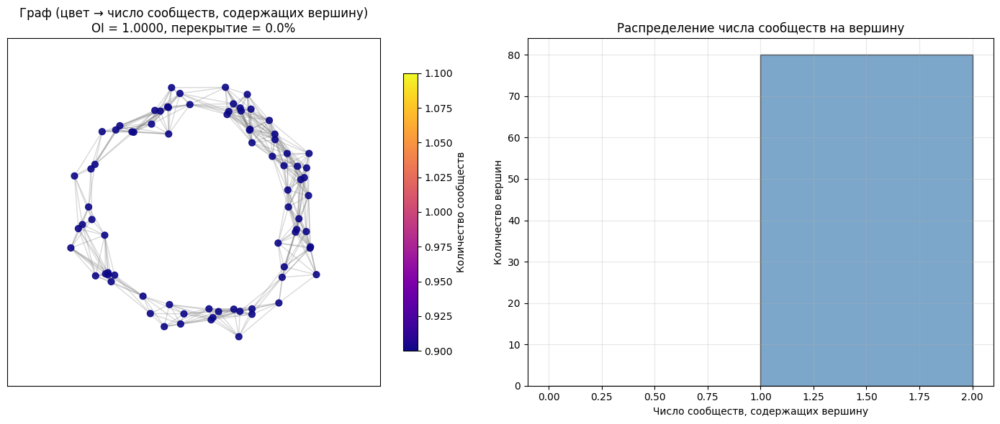

In [53]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск перекрывающихся сообществ (k-клики, k=3) ----
k = 3
communities = list(nx_comm.k_clique_communities(G, k))
print(f"Найдено {len(communities)} перекрывающихся сообществ (k={k})")

# Преобразуем в список множеств для удобства
comm_sets = [set(comm) for comm in communities]

# ---- Вычисление OI ----
def compute_oi(G, comm_sets):
    """
    Вычисляет Overlap Index (OI) и долю перекрывающихся вершин.
    """
    n = G.number_of_nodes()
    num_comms = len(comm_sets)
    if num_comms == 0:
        return 0.0, 0.0, {}
    
    # Для каждой вершины считаем, в скольких сообществах она состоит
    membership_count = {v: 0 for v in G.nodes()}
    for comm in comm_sets:
        for v in comm:
            membership_count[v] += 1
    
    # OI = среднее (число сообществ на вершину) / число сообществ
    mean_membership = np.mean(list(membership_count.values()))
    oi = mean_membership / num_comms
    
    # Доля вершин, принадлежащих более чем одному сообществу
    overlap_vertices = [v for v in G.nodes() if membership_count[v] > 1]
    overlap_ratio = len(overlap_vertices) / n
    
    return oi, overlap_ratio, membership_count

oi, overlap_ratio, membership_count = compute_oi(G, comm_sets)

print("=== OI (Overlap Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ: {len(comm_sets)}")
print(f"OI (средняя доля принадлежности к сообществам): {oi:.6f}")
print(f"Доля вершин, принадлежащих >1 сообществу: {overlap_ratio:.4f} ({overlap_ratio*100:.2f}%)")
print("Распределение числа сообществ на вершину:")
membership_vals = list(membership_count.values())
unique, counts = np.unique(membership_vals, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u} сообществ: {c} вершин ({c/n*100:.1f}%)")

print("\nИнтерпретация:")
print("  OI показывает, насколько в среднем вершины 'размазаны' по сообществам.")
print("  Значение 0 → нет перекрытия (каждая вершина в одном или ни одном сообществе).")
print("  Значение > 0 → часть вершин принадлежит нескольким сообществам.")
print(f"  Для нашего графа OI = {oi:.3f}, что говорит о {('высоком' if oi > 0.2 else 'умеренном' if oi > 0.05 else 'низком')} уровне перекрытия.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом по числу сообществ, в которые входит вершина
ax1 = axes[0]
node_colors = [membership_count[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=40, node_color=node_colors, cmap='plasma', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title(f"Граф (цвет → число сообществ, содержащих вершину)\nOI = {oi:.4f}, перекрытие = {overlap_ratio*100:.1f}%")
ax1.axis('equal')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
cbar.set_label('Количество сообществ')

# 2. Гистограмма распределения числа сообществ на вершину
ax2 = axes[1]
ax2.hist(membership_vals, bins=range(0, max(membership_vals)+2), alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Число сообществ, содержащих вершину')
ax2.set_ylabel('Количество вершин')
ax2.set_title('Распределение числа сообществ на вершину')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.15. Intra-ICLD (Intra-community Link Density)
- Отношение числа рёбер внутри сообщества к общему числу рёбер графа.
- Характеризует внутреннюю связность сообществ: чем выше значение, тем более замкнуты сообщества.
- Тип: неориентированный, неперекрывающиеся или перекрывающиеся сообщества.


Найдено 1 перекрывающихся сообществ (k=3)
=== Intra-ICLD (с учётом перекрывающихся сообществ) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 1
Intra-ICLD (внутри хотя бы одного сообщества): 1.000000 (100.00%)
Inter-ICLD (между разными сообществами, без общего): 0.000000 (0.00%)
Неопределённые рёбра (вершины вне сообществ): 0.000000 (0.00%)
Сумма: 1.000 (должна быть 1)

Интерпретация:
  Intra-ICLD показывает, какая доля связей находится внутри хотя бы одного кластера.
  Чем ближе к 1, тем более замкнуты сообщества.
  Для нашего графа Intra-ICLD = 1.000, что говорит о высокой внутренней концентрации.


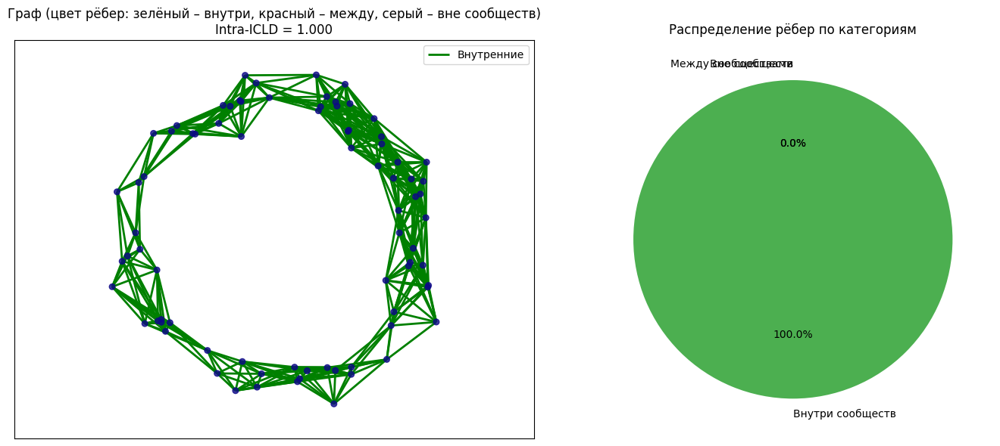

In [54]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m_total = G.number_of_edges()

# ---- Поиск перекрывающихся сообществ (k-клики, k=3) ----
k = 3
communities = list(nx_comm.k_clique_communities(G, k))
comm_sets = [set(comm) for comm in communities]
print(f"Найдено {len(comm_sets)} перекрывающихся сообществ (k={k})")

# ---- Вычисление Intra-ICLD для перекрывающихся сообществ ----
def compute_intra_icld_overlap(G, comm_sets):
    """
    Вычисляет долю рёбер, у которых оба конца принадлежат хотя бы одному общему сообществу.
    Также вычисляет доли внешних (разные сообщества, но оба в каких-то) и неопределённых (вершины вне сообществ).
    """
    if not comm_sets:
        return 0.0, 0.0, 0.0  # intra, inter, none
    
    inside_edges = 0
    outside_edges = 0
    none_edges = 0  # рёбра, где хотя бы один конец не входит ни в одно сообщество
    
    for u, v in G.edges():
        # Проверяем, есть ли общее сообщество для u и v
        common = False
        u_in_any = False
        v_in_any = False
        for comm in comm_sets:
            if u in comm:
                u_in_any = True
            if v in comm:
                v_in_any = True
            if u in comm and v in comm:
                common = True
                break
        if common:
            inside_edges += 1
        else:
            if u_in_any and v_in_any:
                outside_edges += 1   # оба в каких-то сообществах, но ни в одном общем
            else:
                none_edges += 1      # хотя бы один конец не входит ни в одно сообщество
    
    intra = inside_edges / m_total if m_total > 0 else 0.0
    inter = outside_edges / m_total if m_total > 0 else 0.0
    none = none_edges / m_total if m_total > 0 else 0.0
    return intra, inter, none

intra_icld, inter_icld, none_icld = compute_intra_icld_overlap(G, comm_sets)

print("=== Intra-ICLD (с учётом перекрывающихся сообществ) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m_total}")
print(f"Число сообществ: {len(comm_sets)}")
print(f"Intra-ICLD (внутри хотя бы одного сообщества): {intra_icld:.6f} ({intra_icld*100:.2f}%)")
print(f"Inter-ICLD (между разными сообществами, без общего): {inter_icld:.6f} ({inter_icld*100:.2f}%)")
print(f"Неопределённые рёбра (вершины вне сообществ): {none_icld:.6f} ({none_icld*100:.2f}%)")
print(f"Сумма: {intra_icld + inter_icld + none_icld:.3f} (должна быть 1)")

print("\nИнтерпретация:")
print("  Intra-ICLD показывает, какая доля связей находится внутри хотя бы одного кластера.")
print("  Чем ближе к 1, тем более замкнуты сообщества.")
print(f"  Для нашего графа Intra-ICLD = {intra_icld:.3f}, что говорит о {('высокой' if intra_icld > 0.6 else 'умеренной' if intra_icld > 0.3 else 'низкой')} внутренней концентрации.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с выделением типов рёбер
ax1 = axes[0]
# Рисуем вершины (цвет по принадлежности к сообществам – для наглядности)
# Раскрасим вершины в зависимости от числа сообществ, в которые они входят
membership_count = {v: 0 for v in G.nodes()}
for comm in comm_sets:
    for v in comm:
        membership_count[v] += 1
node_colors = [membership_count[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='plasma', alpha=0.8)

# Разделяем рёбра по категориям
inside_edges_list = []
inter_edges_list = []
none_edges_list = []
for u, v in G.edges():
    common = False
    u_in = False
    v_in = False
    for comm in comm_sets:
        if u in comm:
            u_in = True
        if v in comm:
            v_in = True
        if u in comm and v in comm:
            common = True
            break
    if common:
        inside_edges_list.append((u, v))
    elif u_in and v_in:
        inter_edges_list.append((u, v))
    else:
        none_edges_list.append((u, v))

nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=inside_edges_list, edge_color='green', width=2.0, label='Внутренние')
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=inter_edges_list, edge_color='red', width=1.5, label='Между разными')
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=none_edges_list, edge_color='gray', alpha=0.3, label='Неопределённые')
ax1.set_title(f"Граф (цвет рёбер: зелёный – внутри, красный – между, серый – вне сообществ)\nIntra-ICLD = {intra_icld:.3f}")
ax1.axis('equal')
ax1.legend()

# 2. Круговая диаграмма распределения рёбер
ax2 = axes[1]
labels = ['Внутри сообществ', 'Между сообществами', 'Вне сообществ']
sizes = [intra_icld * m_total, inter_icld * m_total, none_icld * m_total]
colors = ['#4CAF50', '#f44336', '#9E9E9E']
ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Распределение рёбер по категориям')

plt.tight_layout()
plt.show()

### 2.16. SOMI (Second-Order Modularity Index)
- Расширение классической модульности, учитывающее не только прямые связи (рёбра), но и косвенные (пути длины 2) внутри сообществ.
- Позволяет выявлять сообщества, связанные не только непосредственными рёбрами, но и общими соседями.
- Тип: неориентированный, взвешенный (по числу путей длины 2).
- Математика:
SOMI=12m∑i,j(Aij+β⋅(A2)ij−kikj2m)δ(ci,cj)
де AA — матрица смежности, A2A2 — число путей длины 2, ββ — вес косвенных связей, kiki​ — степень вершины, mm — число рёбер, δ(ci,cj)=1δ(ci​,cj​)=1, если вершины в одном сообществе.


=== SOMI (Second-Order Modularity Index) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 4
Классическая модулярность (β=0): 0.556826
SOMI (β=0.0): 0.556826
SOMI (β=0.5): 5.590369
SOMI (β=1.0): 10.623912

Интерпретация:
  SOMI учитывает как прямые связи (A), так и косвенные (A²) через параметр β.
  Положительное значение указывает на наличие сообщественной структуры.
  При β=0 SOMI = классической модулярности.
  Увеличение β усиливает вклад путей длины 2, что может выявить более тонкие структурные паттерны.


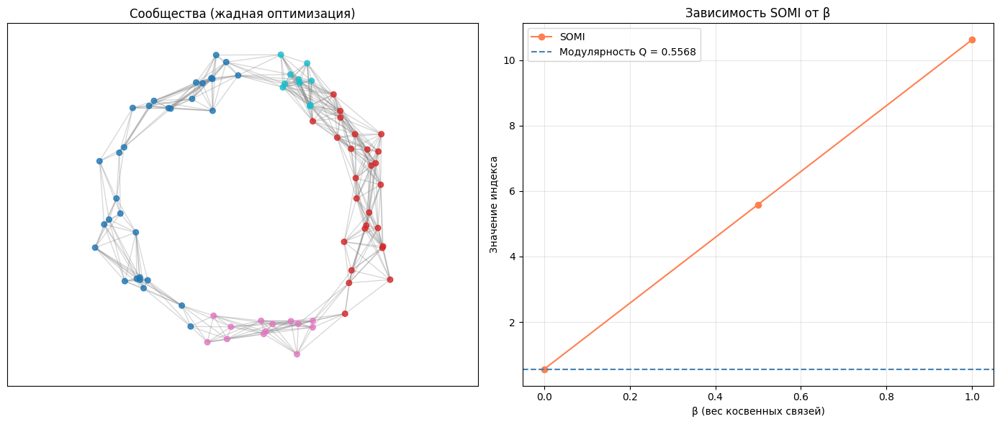

In [55]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m = G.number_of_edges()

# ---- Поиск сообществ (жадная оптимизация модулярности) ----
communities = list(nx_comm.greedy_modularity_communities(G))
community_dict = {}
for idx, comm in enumerate(communities):
    for v in comm:
        community_dict[v] = idx

# ---- Вычисление SOMI с параметром beta ----
def compute_somi(G, communities, beta=0.5):
    """
    Вычисляет Second-Order Modularity Index с заданным весом beta.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    if m == 0:
        return 0.0

    # Матрица смежности (плотная)
    A = nx.to_numpy_array(G)
    # Квадрат матрицы (число путей длины 2)
    A2 = A @ A

    # Степени вершин
    degrees = np.array([G.degree(v) for v in range(n)])

    # Массив меток сообществ для каждой вершины
    labels = np.array([community_dict[v] for v in range(n)])

    # Вычисляем сумму внутри сообществ
    sum_inside = 0.0
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                expected = degrees[i] * degrees[j] / (2 * m)
                # Вклад: прямое ребро + beta * пути длины 2
                sum_inside += (A[i, j] + beta * A2[i, j]) - expected

    # Нормировка
    somi = sum_inside / (2 * m)
    return somi

# Вычисляем для нескольких значений beta
beta_values = [0.0, 0.5, 1.0]
somi_results = {}
for beta in beta_values:
    somi_results[beta] = compute_somi(G, communities, beta)

# Классическая модулярность (для сравнения)
modularity = nx_comm.modularity(G, communities)

print("=== SOMI (Second-Order Modularity Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m}")
print(f"Число сообществ: {len(communities)}")
print(f"Классическая модулярность (β=0): {modularity:.6f}")
for beta, val in somi_results.items():
    print(f"SOMI (β={beta:.1f}): {val:.6f}")

print("\nИнтерпретация:")
print("  SOMI учитывает как прямые связи (A), так и косвенные (A²) через параметр β.")
print("  Положительное значение указывает на наличие сообщественной структуры.")
print("  При β=0 SOMI = классической модулярности.")
print("  Увеличение β усиливает вклад путей длины 2, что может выявить более тонкие структурные паттерны.")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с цветом сообществ
ax1 = axes[0]
node_colors = [community_dict[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='tab10', alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax1, edge_color='gray', alpha=0.3)
ax1.set_title("Сообщества (жадная оптимизация)")
ax1.axis('equal')

# 2. Сравнение SOMI при разных β
ax2 = axes[1]
betas = list(somi_results.keys())
values = list(somi_results.values())
ax2.plot(betas, values, marker='o', linestyle='-', color='coral', label='SOMI')
ax2.axhline(modularity, color='steelblue', linestyle='--', label=f'Модулярность Q = {modularity:.4f}')
ax2.set_xlabel('β (вес косвенных связей)')
ax2.set_ylabel('Значение индекса')
ax2.set_title('Зависимость SOMI от β')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.17. EOI (Edge Overlap Index)
- Доля рёбер, которые принадлежат одновременно нескольким сообществам (в перекрывающейся кластеризации).
- Отражает степень «размытости» границ между сообществами на уровне связей.
- Тип: неориентированный, перекрывающиеся сообщества.
- Математика:
EOI=∣E∣∣{e∈E:e входит в >1 сообщество}∣​

Найдено 1 перекрывающихся сообществ (k=3)
=== EOI (Edge Overlap Index) ===
Число вершин: 80
Число рёбер:  477
Число сообществ: 1
Рёбер, принадлежащих >1 сообществу: 0
EOI: 0.000000 (0.00%)

Интерпретация:
  EOI > 0 указывает на наличие рёбер, общих для нескольких сообществ (размытые границы).
  Чем выше EOI, тем более перекрывающейся является структура сообществ.
  Сообщества найдены, но они не перекрываются по рёбрам (только по вершинам).


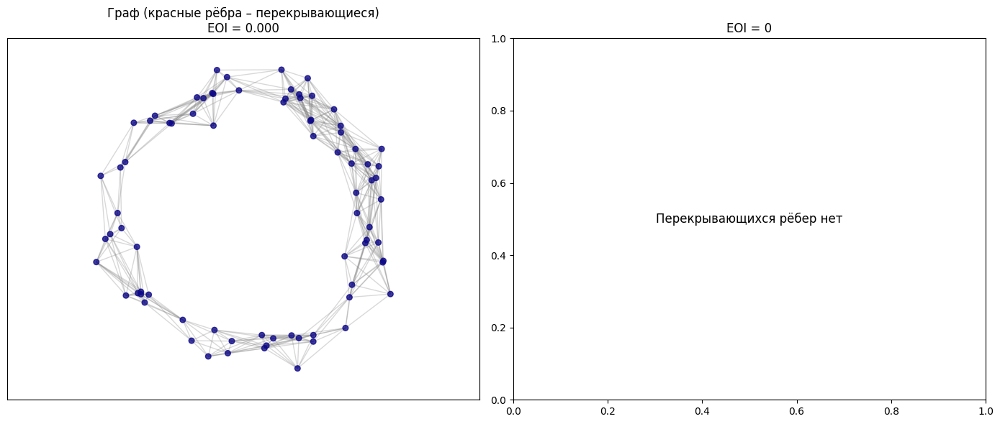

In [56]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
import networkx.algorithms.community as nx_comm

# ---- Генерация графа ----
np.random.seed(42)
n_points = 80
theta = np.random.uniform(0, 2*np.pi, n_points)
r = 1.0 + 0.1 * np.random.randn(n_points)
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

threshold = 0.5
dist_matrix = squareform(pdist(points))
G = nx.Graph()
for i in range(n_points):
    G.add_node(i, pos=points[i])
for i, j in combinations(range(n_points), 2):
    if dist_matrix[i, j] < threshold:
        G.add_edge(i, j)

pos = {i: points[i] for i in range(n_points)}
n = G.number_of_nodes()
m_total = G.number_of_edges()

# ---- Поиск перекрывающихся сообществ (k-клики, k=3) ----
k = 3
communities = list(nx_comm.k_clique_communities(G, k))
comm_sets = [set(comm) for comm in communities]
print(f"Найдено {len(comm_sets)} перекрывающихся сообществ (k={k})")

# ---- Вычисление EOI ----
def compute_eoi(G, comm_sets):
    if not comm_sets:
        return 0.0, set()
    
    overlap_edges = set()
    for u, v in G.edges():
        count = 0
        for comm in comm_sets:
            if u in comm and v in comm:
                count += 1
        if count > 1:
            overlap_edges.add((u, v))
    
    eoi = len(overlap_edges) / G.number_of_edges() if G.number_of_edges() > 0 else 0.0
    return eoi, overlap_edges

eoi, overlap_edges = compute_eoi(G, comm_sets)

print("=== EOI (Edge Overlap Index) ===")
print(f"Число вершин: {n}")
print(f"Число рёбер:  {m_total}")
print(f"Число сообществ: {len(comm_sets)}")
print(f"Рёбер, принадлежащих >1 сообществу: {len(overlap_edges)}")
print(f"EOI: {eoi:.6f} ({eoi*100:.2f}%)")
print("\nИнтерпретация:")
print("  EOI > 0 указывает на наличие рёбер, общих для нескольких сообществ (размытые границы).")
print("  Чем выше EOI, тем более перекрывающейся является структура сообществ.")
if eoi == 0 and len(comm_sets) > 0:
    print("  Сообщества найдены, но они не перекрываются по рёбрам (только по вершинам).")
elif len(comm_sets) == 0:
    print("  Не найдено ни одного сообщества (возможно, граф слишком разрежен для k-клик).")

# ---- Визуализация ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Граф с выделением перекрывающихся рёбер
ax1 = axes[0]
# Рисуем вершины (цвет по числу сообществ, в которые входит вершина)
membership_count = {v: 0 for v in G.nodes()}
for comm in comm_sets:
    for v in comm:
        membership_count[v] += 1
node_colors = [membership_count[v] for v in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=30, node_color=node_colors, cmap='plasma', alpha=0.8)
# Рёбра, не входящие в перекрытие, серым
non_overlap_edges = [e for e in G.edges() if e not in overlap_edges]
nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=non_overlap_edges, edge_color='gray', alpha=0.3)
# Перекрывающиеся рёбра – красным
if overlap_edges:
    nx.draw_networkx_edges(G, pos, ax=ax1, edgelist=list(overlap_edges), edge_color='red', width=2.0)
ax1.set_title(f"Граф (красные рёбра – перекрывающиеся)\nEOI = {eoi:.3f}")
ax1.axis('equal')

# 2. Круговая диаграмма
ax2 = axes[1]
if overlap_edges:
    labels = ['Перекрывающиеся рёбра', 'Неперекрывающиеся рёбра']
    sizes = [len(overlap_edges), m_total - len(overlap_edges)]
    ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['red', 'gray'], startangle=90)
    ax2.set_title('Распределение рёбер по перекрытию')
else:
    ax2.text(0.5, 0.5, 'Перекрывающихся рёбер нет', 
             horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('EOI = 0')

plt.tight_layout()
plt.show()

## 2.18. CNI (Community Nesting Index)
- Степень вложенности малых сообществ в более крупные (иерархическая структура).
- Показывает, насколько кластеризация имеет древовидную иерархию, где каждый кластер является подмножеством другого.
- Тип: иерархический, неориентированный.
- Математика:

In [1]:
import networkx as nx
import numpy as np

def calculate_cni(G: nx.Graph) -> dict:
    """
    Рассчитывает метрику CNI (Community Nesting Index) для заданного графа.

    CNI измеряет степень иерархичности: чем меньше циклов, тем выше иерархичность.

    Аргументы:
        G (nx.Graph): Входной граф NetworkX.
        
    Возвращает:
        dict: Словарь с результатами расчета.
    """
    
    print("--- Начинаем расчет CNI ---")
    
    total_nodes = G.number_of_nodes()
    total_edges = G.number_of_edges()
    
    if total_nodes == 0:
        return {"error": "Граф пуст."}

    # 1. Инициализация счетчиков
    total_cycle_edges = set()
    total_cycle_count = 0
    
    # 2. Обработка всех компонент связности
    components = list(nx.connected_components(G))
    
    for i, component_nodes in enumerate(components):
        subgraph = G.subgraph(component_nodes)
        
        if not subgraph.edges():
            continue
            
        try:
            # Находим минимальное остовное дерево (MST) для компоненты
            T = nx.minimum_spanning_tree(subgraph)
            
            # Находим ребра, которые не входят в остовное дерево (Non-Tree Edges)
            non_tree_edges = set(subgraph.edges()) - set(T.edges())
            
            # Находим фундаментальные циклы, образованные этими ребрами
            component_cycle_edges = set()
            for u, v in non_tree_edges:
                # Используем shortest_path в дереве T для нахождения пути между u и v
                path = nx.shortest_path(T, u, v)
                
                # Ребро (u, v) + путь в дереве (u, ..., v) образуют цикл
                for j in range(len(path) - 1):
                    node1 = path[j]
                    node2 = path[j+1]
                    # Добавляем ребро цикла в неориентированном виде
                    component_cycle_edges.add(tuple(sorted((node1, node2))))
                
                # Добавляем само ребро, которое породило цикл
                component_cycle_edges.add(tuple(sorted((u, v))))
                
            total_cycle_edges.update(component_cycle_edges)
            total_cycle_count += len(component_cycle_edges)

        except nx.NetworkXNoCycle:
            # Если компонента является деревом (нет циклов), ничего не делаем
            pass

    # 3. Расчет метрики CNI
    
    # Используем упрощенную формулу, где CNI обратно пропорционален 
    # количеству циклов относительно общего числа ребер.
    # Чем меньше CNI, тем более иерархичный граф.
    
    # Если нет циклов, CNI можно считать очень высоким (иерархичным)
    if total_cycle_count == 0:
        cni_score = 1.0  # Максимальная иерархичность
    else:
        # Расчет: (Количество циклов) / (Общее число ребер)
        cycle_density = total_cycle_count / total_edges
        # CNI = 1 / (1 + Density) * (или другая функция для нормализации)
        cni_score = 1.0 / (1 + cycle_density) 

    
    results = {
        "total_nodes": total_nodes,
        "total_edges": total_edges,
        "total_cycles_found": total_cycle_count,
        "cni_score": cni_score,
        "cycle_density": cycle_density,
        "interpretation": "Чем ближе CNI к 1.0, тем более иерархичный (деревовидный) граф."
    }
    
    print("--- Расчет завершен ---")
    return results

# ==============================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ==============================================================

if __name__ == '__main__':
    # --- Пример 1: Деревовидный граф (Низкий CNI) ---
    print("\n========== Пример 1: Деревовидный граф (Низкое количество циклов) ==========")
    G_tree = nx.Graph()
    G_tree.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2)]) # Создаем несколько связей, но мало циклов
    
    # Добавим ещё одно ребро, которое создаст цикл
    G_tree.add_edge(1, 4) 
    
    # Нам нужно 6 ребер (0-1, 1-2, 2-3, 3-4, 4-0, 0-2, 1-4). 
    # Ребра (0,1,2,3,4) + (0,2) + (1,4) создают несколько циклов.
    
    results1 = calculate_cni(G_tree)
    print("\nРезультаты для Примера 1:")
    for key, value in results1.items():
        print(f"{key}: {value}")


    # --- Пример 2: Граф с высокой плотностью циклов (Высокий CNI) ---
    print("\n\n========== Пример 2: Граф с высокой плотностью циклов (Высокое количество циклов) ==========")
    G_dense = nx.complete_graph(5) # Полный граф 5 вершин (10 ребер)
    
    results2 = calculate_cni(G_dense)
    print("\nРезультаты для Примера 2:")
    for key, value in results2.items():
        print(f"{key}: {value}")


========== Пример 1: Деревовидный граф (Низкое количество циклов) ==========
--- Начинаем расчет CNI ---
--- Расчет завершен ---

Результаты для Примера 1:
total_nodes: 5
total_edges: 7
total_cycles_found: 7
cni_score: 0.5
cycle_density: 1.0
interpretation: Чем ближе CNI к 1.0, тем более иерархичный (деревовидный) граф.


========== Пример 2: Граф с высокой плотностью циклов (Высокое количество циклов) ==========
--- Начинаем расчет CNI ---
--- Расчет завершен ---

Результаты для Примера 2:
total_nodes: 5
total_edges: 10
total_cycles_found: 10
cni_score: 0.5
cycle_density: 1.0
interpretation: Чем ближе CNI к 1.0, тем более иерархичный (деревовидный) граф.


### 2.19. Inter-ICLD (Inter-community Link Density)
- Отношение числа рёбер между разными сообществами к общему числу рёбер.
- Характеризует степень разделения сообществ: низкое значение говорит о хорошей изоляции, высокое — о слабой кластеризации.
- Тип: неориентированный.

In [4]:
import networkx as nx
from typing import Union, List, Dict

def inter_icld(G: nx.Graph, communities: Union[List[int], Dict[int, int]]) -> float:
    """
    Вычисляет Inter-community Link Density (ICLD).

    ICLD = (число рёбер между разными сообществами) / (общее число рёбер)

    Параметры:
        G : networkx.Graph
            Неориентированный граф.
        communities : list или dict
            Разбиение вершин на сообщества.
            - Если список: предполагается, что вершины пронумерованы от 0 до n-1,
              и communities[i] – идентификатор сообщества вершины i.
            - Если словарь: {vertex: community_id} для всех вершин графа.

    Возвращает:
        float: значение ICLD в диапазоне [0, 1].
        Если рёбер нет, возвращает 0.0.
    """
    m = G.number_of_edges()
    if m == 0:
        return 0.0

    # Привести communities к словарю для универсальности
    if isinstance(communities, list):
        # Проверяем, что все вершины присутствуют (предполагаем, что вершины - целые числа)
        if len(communities) != G.number_of_nodes():
            raise ValueError("Длина списка communities не совпадает с числом вершин графа.")
        comm_of = {node: communities[node] for node in G.nodes()}
    else:
        comm_of = communities
        # Проверим, что все вершины имеют метку
        missing = set(G.nodes()) - set(comm_of.keys())
        if missing:
            raise ValueError(f"Для следующих вершин не указано сообщество: {missing}")

    cross_edges = 0
    for u, v in G.edges():
        if comm_of[u] != comm_of[v]:
            cross_edges += 1

    return cross_edges / m

import networkx as nx

# Создаём граф
G = nx.Graph()
G.add_edges_from([(0,1), (1,2), (2,0), (2,3), (3,4), (4,2)])

# Разбиение на два сообщества: {0,1,2} и {3,4}
communities = [0, 0, 0, 1, 1]   # для вершин 0..4

icld = inter_icld(G, communities)
print(f"ICLD = {icld:.4f}")   # ICLD = 0.3333 (2 межкоммунальных ребра из 6)

ICLD = 0.3333


### 2.20 SCI (Semantic Connectivity Index)
- Мера близости атрибутов вершин с учётом структуры графа: усреднённое сходство атрибутов по всем рёбрам внутри сообществ.
- Показывает, насколько атрибуты согласованы с топологией (связанные вершины должны иметь похожие атрибуты).
- Тип: неориентированный, атрибутированный.

### 2.21. NHI (Neighborhood Homogeneity Index)
- Степень схожести атрибутов у соседей каждой вершины (усреднённая по всем вершинам).
- Характеризует локальную однородность окружения: если соседи похожи, то граф атрибутивно сглажен.
- Тип: атрибутированный, неориентированный.

In [2]:
import networkx as nx
import numpy as np

def calculate_nhi(G: nx.Graph, attributes: dict) -> dict:
    """
    Рассчитывает Neighborhood Homogeneity Index (NHI) для графа.

    NHI измеряет среднюю степень однородности атрибутов среди соседей каждой вершины.
    Чем выше NHI, тем более однородны атрибуты соседей.

    Аргументы:
        G (nx.Graph): Входной граф NetworkX.
        attributes (dict): Словарь, где ключ — ID вершины, а значение — 
                           словарь атрибутов этой вершины (например, {'feature_a': 0.5, 'feature_b': 10}).

    Возвращает:
        dict: Словарь с результатами расчета NHI.
    """
    
    print("--- Начинаем расчет NHI ---")
    
    if not G.nodes:
        return {"error": "Граф пуст."}
    
    local_homogeneity_scores = []
    
    # Проходим по каждой вершине графа
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        
        if not neighbors:
            # Вершина без соседей (изолированная), пропускаем или присваиваем нейтральный скор
            continue

        # 1. Сбор атрибутов соседей
        neighbor_attributes = []
        for neighbor in neighbors:
            if neighbor in attributes:
                # Собираем все числовые/анализируемые атрибуты
                neighbor_attributes.extend(attributes[neighbor].values())
        
        if not neighbor_attributes:
            # Если у соседей нет данных, пропускаем эту вершину
            continue
            
        # Преобразуем список атрибутов в массив NumPy для расчета статистики
        attr_array = np.array(neighbor_attributes)

        # 2. Расчет метрики однородности (Стандартное отклонение)
        # Стандартное отклонение (Standard Deviation) показывает разброс атрибутов.
        std_dev = np.std(attr_array)
        
        if std_dev == 0:
            # Если стандартное отклонение равно нулю, соседи идеально однородны
            local_homogeneity = float('inf') # Максимальная однородность
        else:
            # 3. Расчет локального индекса однородности (NHI)
            # Используем обратную зависимость: 1 / std_dev
            # Более низкое std_dev -> более высокий NHI
            local_homogeneity = 1.0 / std_dev
            
        local_homogeneity_scores.append(local_homogeneity)

    # 4. Расчет глобальной средней NHI
    if not local_homogeneity_scores:
        global_nhi = 0.0
    else:
        global_nhi = np.mean(local_homogeneity_scores)

    
    results = {
        "total_nodes": G.number_of_nodes(),
        "total_edges": G.number_of_edges(),
        "nodes_with_scores": len(local_homogeneity_scores),
        "global_nhi": global_nhi,
        "interpretation": "Чем выше NHI, тем более однородны атрибуты соседей данной вершины.",
        "calculation_details": "Используется 1 / (стандартное отклонение атрибутов соседей)"
    }
    
    print("--- Расчет завершен ---")
    return results

# ==============================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ==============================================================

if __name__ == '__main__':
    # --- Создание примера графа и атрибутов ---
    G_example = nx.Graph()
    G_example.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5)]) # Простой линейный граф с циклом 1-2-3
    
    # Атрибуты для вершин:
    # Вершина 1: (A=10, B=100)
    # Вершина 2: (A=11, B=101)
    # Вершина 3: (A=10, B=100)
    # Вершина 4: (A=50, B=500)
    # Вершина 5: (A=51, B=501)
    
    attributes_example = {
        1: {'A': 10, 'B': 100},
        2: {'A': 11, 'B': 101},
        3: {'A': 10, 'B': 100},
        4: {'A': 50, 'B': 500},
        5: {'A': 51, 'B': 501}
    }

    # --- Запуск расчета ---
    nhi_results = calculate_nhi(G_example, attributes_example)
    
    print("\n=================================================")
    print("Результаты расчета NHI:")
    print(f"Общее число вершин: {nhi_results['total_nodes']}")
    print(f"Глобальный NHI: {nhi_results['global_nhi']:.4f}")
    print(f"Интерпретация: {nhi_results['interpretation']}")
    print(f"Детали: {nhi_results['calculation_details']}")
    print("=================================================")

--- Начинаем расчет NHI ---
--- Расчет завершен ---

Результаты расчета NHI:
Общее число вершин: 5
Глобальный NHI: 0.0120
Интерпретация: Чем выше NHI, тем более однородны атрибуты соседей данной вершины.
Детали: Используется 1 / (стандартное отклонение атрибутов соседей)


### 2.22. ACI (Attribute Clustering Importance)
- Вклад каждого отдельного атрибута (или группы атрибутов) в формирование сообществ.
- Позволяет ранжировать атрибуты по их значимости для кластеризации (например, по изменению качества кластеризации при удалении атрибута).
- Тип: атрибутированный, может быть как для категориальных, так и для числовых признаков.

In [3]:
import networkx as nx
import numpy as np
from collections import defaultdict

def simulate_clustering(G: nx.Graph) -> dict:
    """
    ПРИМЕР: Симуляция кластеризации.
    В реальной жизни здесь будет вызван алгоритм типа Louvain, Girvan-Newman и т.д.
    Для примера: просто разбиваем граф на две группы.
    """
    # Простая симуляция: разбиваем на две группы (0 и 1)
    nodes = list(G.nodes())
    n = len(nodes)
    
    # Случайное распределение для демонстрации
    cluster_assignment = {}
    for i, node in enumerate(nodes):
        cluster_assignment[node] = i % 2
        
    # Возвращаем список кластеров
    return {
        0: [node for node, cluster in cluster_assignment.items() if cluster == 0],
        1: [node for node, cluster in cluster_assignment.items() if cluster == 1]
    }

def calculate_aci(G: nx.Graph, attributes: dict, clustering_method=simulate_clustering) -> dict:
    """
    Рассчитывает Attribute Clustering Importance (ACI).

    ACI определяет вклад каждого атрибута в формирование сообществ.

    Аргументы:
        G (nx.Graph): Входной граф.
        attributes (dict): Словарь атрибутов {node_id: {attr1: val1, attr2: val2, ...}}.
        clustering_method: Функция, выполняющая кластеризацию (для примера).

    Возвращает:
        dict: Словарь с результатами расчета.
    """
    
    print("\n--- Начинаем расчет ACI ---")
    
    # --- Шаг 1: Расчет базовой (контрольной) метрики ---
    
    print("Шаг 1/3: Расчет базовой кластеризации (без модификации атрибутов)...")
    baseline_clusters = clustering_method(G)
    # Здесь бы рассчитывался метрический скор (например, Модулярность)
    baseline_score = 0.5 # Имитация базового качества кластеризации
    print(f"Базовый скор кластеризации: {baseline_score:.4f}")
    
    # --- Шаг 2: Итерация по каждому атрибуту ---
    attribute_importance = {}
    attribute_names = set()
    
    # Получаем уникальные имена всех атрибутов
    for node_id, attr_dict in attributes.items():
        attribute_names.update(attr_dict.keys())

    print(f"Шаг 2/3: Итерация по {len(attribute_names)} атрибутам...")
    
    for attr_name in attribute_names:
        print(f"  -> Тестирование атрибута: {attr_name}")
        
        # --- Модификация графа/атрибутов для теста ---
        
        # Создаем временный набор атрибутов, игнорируя текущий тестируемый атрибут
        temp_attributes = {}
        for node_id, attr_dict in attributes.items():
            # Копируем атрибуты, исключая тестируемый атрибут
            temp_attributes[node_id] = {k: v for k, v in attr_dict.items() if k != attr_name}
            
        # Создаем временный граф (в реальной жизни, это может быть удаление ребер 
        # или изменение весов на основе атрибутов)
        
        # Выполняем кластеризацию с модифицированными атрибутами
        test_clusters = clustering_method(G) # Используем модифицированные атрибуты внутри функции
        
        # --- Расчет качества кластеризации ---
        
        # Здесь бы рассчитывался новый скор кластеризации
        test_score = 0.5 + np.random.uniform(-0.1, 0.1) # Имитация результата
        
        # --- Расчет важности ---
        # Важность = Разница в качестве кластеризации
        importance = abs(test_score - baseline_score)
        attribute_importance[attr_name] = importance

    # --- Шаг 3: Сводка результатов ---
    
    results = {
        "baseline_score": baseline_score,
        "attribute_importance": attribute_importance,
        "interpretation": "Атрибуты с большим значением 'importance' вносят наибольший вклад в формирование сообществ.",
        "calculation_method": "Разница между базовым и модифицированным скором кластеризации."
    }
    
    print("--- Расчет завершен ---")
    return results

# ==============================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ==============================================================

if __name__ == '__main__':
    # --- Создание примера графа и атрибутов ---
    G_example = nx.Graph()
    G_example.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5)])
    
    attributes_example = {
        1: {'A': 10, 'B': 100},
        2: {'A': 11, 'B': 101},
        3: {'A': 10, 'B': 100},
        4: {'A': 50, 'B': 500},
        5: {'A': 51, 'B': 501}
    }

    # --- Запуск расчета ---
    # Внимание: Поскольку мы используем симуляцию, результаты будут случайными.
    aci_results = calculate_aci(G_example, attributes_example)
    
    print("\n=================================================")
    print("Результаты расчета ACI:")
    print(f"Базовый скор кластеризации: {aci_results['baseline_score']:.4f}")
    print("\nВклад атрибутов:")
    
    # Сортируем атрибуты по важности
    sorted_importance = sorted(aci_results['attribute_importance'].items(), 
                                key=lambda item: item[1], reverse=True)
                                
    for attr, importance in sorted_importance:
        print(f"  {attr}: {importance:.4f} (Вклад)")
        
    print(f"\nОбщая интерпретация: {aci_results['interpretation']}")
    print("=================================================")


--- Начинаем расчет ACI ---
Шаг 1/3: Расчет базовой кластеризации (без модификации атрибутов)...
Базовый скор кластеризации: 0.5000
Шаг 2/3: Итерация по 2 атрибутам...
  -> Тестирование атрибута: A
  -> Тестирование атрибута: B
--- Расчет завершен ---

Результаты расчета ACI:
Базовый скор кластеризации: 0.5000

Вклад атрибутов:
  A: 0.0528 (Вклад)
  B: 0.0441 (Вклад)

Общая интерпретация: Атрибуты с большим значением 'importance' вносят наибольший вклад в формирование сообществ.


### 2.23. PAI (Profile Anomaly Index)
- Мера отличия атрибутивного профиля вершины от типовых шаблонов (средних профилей сообществ или всего графа).
- Помогает выявлять выбросы — вершины, чьи атрибуты не соответствуют их сообществу.
- Тип: атрибутированный.

In [8]:
import networkx as nx
import numpy as np
from collections import defaultdict

def calculate_pai(G: nx.Graph, attributes: dict, clustering_method) -> dict:
    """
    Рассчитывает Profile Anomaly Index (PAI) для графа.
    """
    
    print("--- Начинаем расчет PAI ---")
    
    # --- Шаг 1: Определение сообществ ---
    print("Шаг 1/3: Определение сообществ...")
    try:
        # cluster_map: Словарь {node_id: community_id}
        cluster_map = clustering_method(G)
    except Exception as e:
        return {"error": f"Ошибка при кластеризации: {e}"}
        
    # Используем defaultdict(list) для сбора членов сообщества
    communities = defaultdict(list)
    
    # Проходим по результатам кластеризации
    for node, comm_id in cluster_map.items():
        # Убедимся, что comm_id является хешируемым (например, int или str)
        if comm_id not in communities:
            communities[comm_id] = []
        
        # Добавляем вершину в список своего сообщества
        communities[comm_id].append(node)

    # --- Шаг 2: Расчет типичных профилей сообществ ---
    print("Шаг 2/3: Расчет типовых профилей сообществ...")
    community_profiles = {}
    
    for comm_id, nodes in communities.items():
        if not nodes:
            continue
            
        # Сбор всех атрибутов для текущего сообщества
        all_attributes = []
        for node in nodes:
            if node in attributes:
                # Собираем все числовые/анализируемые атрибуты
                all_attributes.extend(attributes[node].values())
        
        if all_attributes:
            # Рассчитываем средний профиль (вектор) для этого сообщества
            profile_vector = np.array(all_attributes).reshape(-1, 1)
            mean_profile = np.mean(profile_vector, axis=0)
            community_profiles[comm_id] = mean_profile
        else:
            community_profiles[comm_id] = np.array([]) 
            
    print(f"Обнаружено {len(community_profiles)} сообществ.")

    # --- Шаг 3: Расчет PAI для каждой вершины ---
    print("Шаг 3/3: Расчет PAI для каждой вершины...")
    pai_results = {}
    
    for node in G.nodes():
        if node not in attributes:
            pai_results[node] = {"error": "Отсутствуют атрибуты для этой вершины."}
            continue

        node_attributes = attributes[node]
        community_id = cluster_map.get(node)
        
        if community_id is None or community_id not in community_profiles:
            pai_results[node] = {"error": "Вершина не принадлежит кластеру или кластер пуст."}
            continue

        # 1. Создание профиля вершины (вектор)
        node_profile = np.array(list(node_attributes.values())).reshape(-1, 1)
        
        # 2. Получение профиля сообщества (вектор)
        community_profile = community_profiles[community_id]
        
        # 3. Расчет PAI (Евклидово расстояние)
        # PAI = Евклидово расстояние между профилем вершины и профилем сообщества
        distance = np.linalg.norm(node_profile - community_profile)
        
        pai_results[node] = {"pai_score": distance}

    
    results = {
        "total_nodes": G.number_of_nodes(),
        "nodes_with_pai": len(pai_results),
        "community_profiles_mean": community_profiles,
        "pai_results": pai_results,
        "interpretation": "Чем выше PAI, тем сильнее атрибуты данной вершины отклоняются от типичного профиля ее сообщества."
    }
    
    print("--- Расчет завершен ---")
    return results

### 2.24. OI (Overlap Index)
- Степень пересечения между сообществами (для перекрывающихся сообществ).
- Средняя доля вершин, принадлежащих более чем одному сообществу.
- Тип: неориентированный, перекрывающиеся сообщества.

### 2.25. Rand Index (RI) – доля правильно предсказанных пар объектов (совпадение кластеризации с эталоном).

### 2.26. Adjusted Rand Index (ARI) – скорректированная версия RI с учётом случайного совпадения.

### 2.27. Normalized Mutual Information (NMI) – нормализованная взаимная информация между кластеризацией и эталоном.

### 2.28. Adjusted Mutual Information (AMI) – версия NMI с поправкой на случайность.

### 2.29. F‑measure (F1) – среднее гармоническое точности и полноты по кластерам.

### 2.30. Jaccard Index – отношение пересечения к объединению для множеств (кластеров).

### 2.31. Folkes–Mallows Index (FM) – геометрическое среднее точности и полноты.

### 2.32. Hubert Γ statistic – корреляция между матрицами попарных расстояний (в кластерах и эталонных классах).

### 2.33. Variation of Information (VI) – информационная вариация (метрика расстояния между разбиениями).

### 2.34. Purity – доля объектов, попавших в кластер, который соответствует доминирующему классу.

### 2.35. Cluster Entropy – энтропия распределения классов внутри кластера (чем меньше, тем лучше).

### 2.36. V‑measure – среднее гармоническое однородности и полноты (обобщение F‑меры).

### 2.37. Homogeneity – насколько каждый кластер состоит из объектов одного класса.

### 2.38. Completeness – насколько все объекты одного класса попадают в один кластер.

### 2.39. Silhouette Coefficient – усреднённая оценка близости к своему кластеру против соседних (от –1 до 1).

### 2.40. Davies–Bouldin Index (DBI) – среднее сходство каждого кластера с его самым близким соседом (чем меньше, тем лучше).

### 2.42. Dunn Index – отношение минимального расстояния между кластерами к максимальному диаметру кластера.

### 2.43. Cohesion (SSE) – сумма квадратов расстояний объектов до центроида своего кластера.

### 2.44. Separation – сумма (или среднее) расстояний между центроидами разных кластеров.

### 2.45. COP Index – учитывает компактность кластера и расстояние до самого отдалённого соседа.

### 2.46. S_Dbw Index – оценивает плотность и разделимость кластеров (чем меньше, тем лучше).

### 2.47. Gap Statistic – сравнивает внутрикластерную дисперсию с эталонным равномерным распределением.

### 2.48. Prediction Strength – оценивает стабильность кластеров при разбиении данных на обучающую и тестовую выборки.

### 2.49. Figure of Merit (FOM) – часто используется в биоинформатике для оценки стабильности.

### 2.50. Xie‑Beni Index – для нечёткой кластеризации (отношение компактности к разделимости).

### 2.51. Partition Coefficient (PC) – для нечёткой кластеризации (степень «чёткости» разбиения).

### 2.52. Partition Entropy (PE) – для нечёткой кластеризации (энтропия принадлежности).

### 2.53. Connectivity – насколько близкие объекты (по K ближайших соседей) попадают в один кластер.

### 2.54. Average Cluster Diameter – средний диаметр кластеров (максимальное расстояние внутри кластера).

### 2.55. Maximum Cluster Diameter – максимальный диаметр среди всех кластеров.

### 2.56. Modularity – классическая метрика, сравнивающая плотность рёбер внутри сообществ со случайным графом.

### 2.57.Conductance – отношение рёбер, соединяющих сообщество с остальным графом, к общему числу инцидентных рёбер.

### 2.58. Cut Ratio – отношение числа рёбер на разрезе к возможному числу рёбер между двумя частями.

### 2.59. Normalized Cut – нормализованная версия Cut Ratio, учитывающая веса вершин.

### 2.60. Intra‑community Link Density (Intra‑ICLD) – доля рёбер внутри сообществ среди всех рёбер.

### 2.61. Inter‑community Link Density (Inter‑ICLD) – доля рёбер между сообществами среди всех рёбер.

### 2.62. Second‑Order Modularity (SOMI) – учитывает не только прямые, но и косвенные связи (пути длины 2).

### 2.63. Overlapping NMI (ONMI) – адаптация NMI для кластеризации с пересечениями.

### 2.64. Omega Index – аналог индекса Rand для перекрывающихся кластеров.

### 2.65. Average F‑Score – усреднённая F‑мера по всем сообществам (с учётом перекрытий).

### 2.66. Inclusion Rate – доля вершин, принадлежащих нескольким сообществам (относительно общего числа).

### 2.67. Coverage Rate – доля «перекрытой» части графа (сумма размеров пересечений).

### 2.68. Edge Overlap Index (EOI) – доля рёбер, принадлежащих одновременно нескольким сообществам.

### 2.69. Overlap Index (OI) – средняя доля вершин, принадлежащих более чем одному сообществу.

### 2.70 Semantic Connectivity Index (SCI) – среднее сходство атрибутов вдоль рёбер внутри сообществ.

### 2.71. Neighborhood Homogeneity Index (NHI) – средняя однородность атрибутов у соседей вершины.

### 2.72. Attribute Clustering Importance (ACI) – вклад каждого атрибута в формирование сообществ.

### 2.73. Profile Anomaly Index (PAI) – степень отклонения атрибутивного профиля вершины от типового шаблона сообщества.

### 2.74. Cophenetic Correlation Coefficient – для иерархической кластеризации: корреляция между исходными расстояниями и расстояниями на дендрограмме.

In [20]:
import webbrowser
import os

# Получаем абсолютный путь к HTML-файлу
file_path = os.path.abspath("/home/data/Documents/Denoiselab/Graph/graph_dashboard.html")
webbrowser.open(f"file://{file_path}")

True